# VitaCall, ML Engineering & Ops

Auteur: Thomas en Parsa

VitaCall is een Nederlandse alarmcentrale. Iemand drukt thuis op de knop van zijn personenalarm, en aan de andere kant van de lijn zit een operator die in een paar seconden moet inschatten hoe erg het is. Voor dat soort beslissingen willen we het systeem laten meekijken. We bouwen in dit notebook daarom **twee losse modellen** voor binnenkomende gesprekken:

1. **Edge-model = Vosk-NL ASR** (spraak-naar-tekst). Dit draait lokaal op de machine van de medewerker en we evalueren het via de inline WER-harness in sectie 2.1. Het zet audio om naar tekst, en de ruwe audio verlaat het pand nooit. Belangrijk: dit is een kant-en-klaar Kaldi/Vosk-model. Het is de privacy-oplossing op zich, dus geen afgeslankte kopie van het cloud-model.
2. **Cloud-model = sentiment/urgentie-classifier** (TF-IDF + Logistic Regression). Dit is een apart model dat we zelf hebben getraind. Het krijgt alleen de geanonimiseerde *tekst* binnen en geeft sentiment plus spoed-keywords terug via een FastAPI-service.

Het gaat om twee verschillende taken: transcriptie tegenover classificatie. Andere data, andere artefacten, en elk een eigen manier van evalueren. Bij ASR kijken we naar WER, modelgrootte en RTF; bij sentiment naar accuracy/F1 met cross-validatie en een hyperparam-sweep. We hebben de twee bewust niet in elkaar geschoven. Een ASR-model en een sentiment-classifier delen geen enkele aanname, en als je ze samen zou trainen kun je nooit meer uitleggen welke fout waar vandaan komt.

Alle code staat hieronder. Het sentiment-model komt in `models/`, de dataset-stappen in `data/`, en het ASR-model staat in `models/vosk-nl/`.

## Leerdoelen, wat in welk hoofdstuk

| LD | Onderwerp | Sectie | Hoe |
|----|-----------|--------|-----|
| 1  | Datapipeline (ETL + validatie)  | 1    | drie lagen: ruw, schoon, klaar voor training, met checks per laag |
| 2  | Schaalbaarheid                  | 1.4  | PySpark als de JVM beschikbaar is, anders pandas. Streaming per batch. |
| 3  | Modellering & ML-pipeline       | 2    | twee onafhankelijke modellen: edge-ASR (Vosk-NL, sectie 2.1) + cloud-sentiment (TF-IDF+LR), MLflow, hyperparam-sweep, federated learning |
| 4  | Deployment                      | 3    | FastAPI, Docker, GitHub Actions (CI/CD/CT) |
| 5  | Monitoring                      | 4    | DriftDetector, Metrics p50/p95, /metrics endpoint, JSON-logs |

## Hoe lees je dit

Elke sectie begint met een korte uitleg en daarna komt de code. De cellen draaien in volgorde van boven naar beneden. Onder elke codecel staat de uitvoer, of een foutmelding als iets misgaat. Dat laatste is trouwens ook leerzaam, want dan zie je precies waar de pijplijn vastloopt.

## 0. Productvereisten (rubric: stakeholders + model-eisen + retraining)

Voordat we ook maar een regel modelcode schrijven, leggen we eerst vast voor wie we dit bouwen en wat het systeem moet kunnen. Dat klinkt als een formaliteit, maar bij een zorgproduct is het dat niet. De keuzes hieronder (welke metriek telt, welke drempel acceptabel is, waar de data mag staan) volgen rechtstreeks uit het feit dat het om mensen in nood gaat. Een gemiste spoedmelding weegt hier nu eenmaal zwaarder dan een procentje accuracy.

### Stakeholders
Er zijn vijf partijen die elk iets anders van het systeem verwachten. Die belangen botsen soms: snelheid tegenover zorgvuldigheid, privacy tegenover rijke data. Juist daarom zetten we ze expliciet op een rij. Dat maakt later duidelijk waarom we bepaalde afwegingen zo hebben gemaakt en niet anders.

| Rol | Belang |
|---|---|
| Operator alarmcentrale | krijgt realtime sentiment + spoed-keywords bij het gesprek; wil een snel, eenduidig signaal, geen scherm vol ruis |
| Beller | krijgt snellere triage zonder dat audio het pand verlaat (privacy); is vaak kwetsbaar en kan niet zelf om databescherming vragen |
| MLOps engineer | beheert pipeline, modellen, CI/CD/CT; wil reproduceerbaarheid en kunnen terugrollen als een model slechter wordt |
| Compliance officer | bewaakt AVG-conformiteit (audio blijft on-device dankzij de edge-ASR); moet de dataverwerking aan een auditor kunnen uitleggen |
| Productmanager | stuurt op SLA's (uptime, p95-latency, drift-alerts); wil meetbare garanties, niet "het werkt meestal wel" |

Twee lijnen springen eruit. De operator wil snelheid en duidelijkheid, en daar komt zowel de latency-eis als de keuze voor een licht model uit voort. De compliance officer en de beller willen dat gevoelige audio nergens heen reist, en daar komt het edge-first ontwerp vandaan.

### Model-eisen (SLA)
De eisen hieronder zijn geen ronde getallen die we mooi vonden. Het zijn drempels die uit de zorgcontext volgen. De latency-eis (<= 50 ms p95) zit erin omdat de operator het signaal *tijdens* het gesprek wil zien, niet erna. De accuracy-ondergrens (>= 0.85) is het punt waaronder een operator het advies niet meer serieus neemt. En de edge-ASR moet onder de 100 MB blijven, want hij moet op gewone werkplek-hardware of zelfs een zorg-gateway kunnen draaien, zonder GPU.

| Eis | Doel | Werkelijk |
|---|---|---|
| Edge-ASR modelgrootte | <= 100 MB on-device | wordt gemeten als `models/vosk-nl/` lokaal aanwezig is |
| Edge-ASR snelheid | sneller dan real-time (RTF < 1) | wordt gemeten op toegevoegde referentie-audio |
| Edge-ASR WER | te meten op opgenomen referentiezinnen | harness in de inline WER-harness (sectie 2.1); nog geen Nederlands referentiecorpus, zie sectie 2.1 |
| Cloud test-accuracy | >= 0.85 | 0.871 (`evidence/cv_scores.json`) |
| Cloud CV-F1 mean (5-fold) | >= 0.80 | 0.848 +/- 0.056 |
| Pickle-grootte cloud | <= 1 MB | 0.22 MB |
| Inference-latency (p95) | <= 50 ms | gemeten in `/metrics`, ~5-15 ms |
| Endpoints | `/health`, `/analyze`, `/drift`, `/metrics` | alle vier live in `serve.py` |

Voor de edge is RTF de operationele grens: onder 1.0 blijft transcriptie sneller dan het gesprek. Deze run rapporteert alleen een RTF als zowel het Vosk-model als referentie-audio lokaal aanwezig zijn. Bij de cloud-classifier kijken we naar F1 met cross-validatie en niet puur naar accuracy, omdat losse accuracy een scheve klasseverdeling kan verbergen.

### Retraining-strategie
Een model dat eenmaal goed is, blijft niet vanzelf goed. Taalgebruik schuift, het type meldingen verandert, en dan begint de classifier stilletjes te verouderen. Daarom hertrainen we niet ad hoc, maar via drie vaste triggers, met een gate ervoor die regressie tegenhoudt.

1. **Trigger 1 - schedule**: `cicd.yml` (job: retrain) draait elke zondag 03:00 UTC. Een vaste hartslag, zodat het model meegroeit ook als niemand erop let.
2. **Trigger 2 - drift**: als `drift_score > 0.30` (output) of PSI > 0.20 (input), zet de alert-engine `retrain_recommended=true` in `evidence/alerts.jsonl`. Dit is de reactieve kant: niet wachten op zondag als de data nu al verschuift.
3. **Trigger 3 - handmatig**: `workflow_dispatch` in de GitHub UI, voor als een engineer een nieuwe dataset wil doortrekken zonder op het schema te wachten.
4. **Validatie-gate**: een nieuw model wordt alleen gepromoveerd als CV-F1 >= huidige - 0.01 (anti-regression). Lukt dat niet, dan blijft het artifact-only. Zo kan een hertraining de productiekwaliteit nooit stiekem verslechteren, en dat is bij een zorgsysteem het ergste scenario dat je kunt bedenken.

### Data-eisen (samengevat)
De pijplijn is opgezet rond vijf data-eisen die elk een concreet risico afdekken. Het zwaarst weegt privacy: we werken met een proxy-dataset, omdat echte alarmtranscripten gezondheidsdata zijn (AVG art. 9, bijzondere persoonsgegevens) en die mogen we hier niet aanraken.

- **Kwaliteit**: 3-laags validatie (`validate_*`), fail-fast bij errors. Een foutje vroeg in de pijplijn wordt verderop alleen maar duurder, dus we stoppen meteen met een duidelijke `ValueError`.
- **Volume**: streaming via `pyarrow.iter_batches` (constant geheugen). Nu past alles nog in RAM, maar bij honderdduizenden gesprekken per maand niet meer. Daar is de streaming-route op voorbereid.
- **Snelheid**: PySpark voor parallelle split, fsspec voor cloud-storage. Het distributed pad ligt klaar voor het moment dat een enkele machine niet meer volstaat.
- **Privacy**: de edge-ASR (Vosk-NL) zet audio lokaal om naar tekst, en alleen de geanonimiseerde tekst gaat naar het cloud-sentimentmodel. Ruwe audio verlaat de instelling nooit. Dit is geen toevoeging achteraf maar de kern van het ontwerp: door de audio nooit te versturen, ligt de gevoeligste data per definitie buiten bereik van de cloud.
- **Veiligheid**: model-bestanden gepind via SHA256 in `data/MANIFEST.json`. Zo kun je altijd aantonen welk artefact bij welke run hoorde, en kan niemand ongemerkt een ander model onderschuiven.

Nog kort iets over de scope, zodat de verwachting klopt. Dit notebook is het volledige, beoordeelde artefact. De eerdere desktop- en web-UI zijn eruit gehaald; wat overblijft is de end-to-end pijplijn van ruwe data tot een live gedeployde, gemonitorde service. Waar we bewust grenzen trekken (synthetische zorg-domeinzinnen, FedAvg zonder netwerktransport en geen lokale WER zonder model plus referentie-audio) leggen we dat uit in de betreffende sectie en onderbouwen we het in de conclusie.

### Wat betekenen de scores?

De tabellen en outputs hieronder gebruiken een aantal vaste maten. Kort wat elk getal betekent en waarom het hier telt:

| Maat | Wat het is | Waarom het telt voor VitaCall |
|---|---|---|
| **Accuracy** | aandeel correcte voorspellingen | snelle hoofdmaat, maar kan een scheve klasseverdeling verbergen |
| **F1** | harmonisch gemiddelde van precision en recall (0-1, hoger = beter) | balanceert gemiste spoed (recall) en vals alarm (precision); eerlijker dan accuracy bij ongelijke klassen |
| **CV-F1 (5-fold)** | F1 gemiddeld over 5 verschillende train/test-splitsingen, met spreiding | toont dat de score geen toeval van één split is; de spreiding (+/-) zegt hoe stabiel het model is |
| **Precision / Recall** | hoe vaak een 'spoed'-voorspelling klopt / hoeveel echte spoed we vangen | bij een alarmcentrale weegt gemiste spoed (recall) het zwaarst |
| **WER** (Word Error Rate) | percentage fout getranscribeerde woorden (lager = beter) | maat voor de edge-ASR: hoe betrouwbaar zet hij spraak om naar tekst |
| **RTF** (Real-Time Factor) | verwerkingstijd gedeeld door audioduur; onder 1.0 = sneller dan real-time | de operator moet de tekst tijdens het gesprek zien, niet erna |
| **p50 / p95 latency** | de mediane / 95e-percentiel responstijd in ms | het gemiddelde verbergt uitschieters; p95 toont het traagste gesprek dat een operator echt als hinder ervaart |
| **PSI** (Population Stability Index) | hoeveel de input-verdeling verschoven is (onder 0,1 stabiel, boven 0,25 echte drift) | vroege waarschuwing dat binnenkomende gesprekken anders worden dan de trainingsdata |
| **KS-test** | statistische toets of twee verdelingen significant verschillen (p < 0,05 = ja) | tweede, onafhankelijke lens op input-drift naast PSI |
| **drift_score** | afwijking van de output van een gezonde 50/50-balans (0 = perfect, hoger = scheef) | signaleert dat het model stelselmatig één kant op gaat voorspellen |

Voor een zorgtoepassing weegt steeds dezelfde afweging: liever een gemiste procentpunt accuracy dan een gemiste spoedmelding, en liever een vroege drift-waarschuwing dan een laat alarm.

In [1]:
# Eenmalig: niet-standaard libraries installeren als ze nog niet in je environment zitten.
# (Standaard Anaconda-pakketten zoals pandas/numpy/scikit-learn worden overgeslagen door pip als ze er al zijn.)
%pip install -q vosk pyspark mlflow fastapi uvicorn pydantic httpx optuna fsspec s3fs pyarrow scikit-learn pandas numpy scipy requests psutil matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports en projectconstanten

Deze cel bundelt alle imports en de globale instellingen op één plek, zodat de rest van het notebook nergens meer een losse `import` nodig heeft. Dat houdt de latere cellen kort en maakt in één oogopslag zichtbaar welke libraries het project gebruikt: pandas en pyarrow voor de data, scikit-learn voor het model, en een handvol standaard-modules voor I/O en hashing.

Drie constanten sturen de hele pijplijn aan. `DATA_DIR` en `MODEL_DIR` leggen vast waar de drie datalagen en de modellen op schijf landen, en `RANDOM_SEED = 42` zorgt dat elke split en elke training reproduceerbaar is: dezelfde seed gaat door pandas, numpy en Spark heen, zodat een tweede run exact dezelfde verdeling oplevert.

De versie-print onderaan is geen formaliteit. Een notebook dat over een half jaar opnieuw gedraaid wordt op andere pakket-versies kan stilletjes andere resultaten geven; door pandas-, numpy- en sklearn-versie te tonen leg je vast waar de cijfers bij horen. De logger doet hetzelfde voor de uitvoering: je ziet in de output wat de pijplijn op welk moment doet.

In [2]:
# Standaard imports voor het hele notebook. We bundelen ze hier zodat
import glob
import hashlib
import json
import logging
import math
import os
# Systeem- en bestandsmodules: nodig voor paden, processen en platform-info
import platform
import pickle
import re
import shutil
import subprocess
import sys
import tarfile
# Tijdelijke mappen en timing gebruiken we bij downloads en benchmarks
import tempfile
import time
import urllib.request
import wave
from collections import deque
from contextlib import contextmanager
# dataclass maakt de validatie-resultaten straks compact en leesbaar
from dataclasses import dataclass, field
from functools import reduce
from pathlib import Path

import numpy as np
import pandas as pd
# pyarrow gebruiken we voor het streamen van grote Parquet-bestanden
import pyarrow as pa
import pyarrow.parquet as pq
import requests
from sklearn.feature_extraction.text import TfidfVectorizer
# Het model zelf: TF-IDF + logistische regressie in een sklearn-pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.pipeline import Pipeline

# Versie-check voor reproduceerbaarheid: een crashende notebook half jaar
import sklearn
print(f'Python pakketten: pandas={pd.__version__}, numpy={np.__version__}, '
      f'sklearn={sklearn.__version__}')

# Pad-constanten. Het notebook draait vanuit de project-root; de pipeline-data
DATA_DIR = 'data'
MODEL_DIR = 'models'
FALLBACK_DIR = 'models'  # doelmap voor de compacte sentiment-JSON (offline tekst-fallback, sectie 2.7)
# Mappen vooraf aanmaken zodat latere schrijfacties niet falen op ontbrekend pad
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# Reproduceerbaarheid: ��n seed door het hele notebook. Spark en
# numpy-permutaties gebruiken deze ook.
RANDOM_SEED = 42

# Eenvoudige logger zodat je in de output ziet wat de pipeline doet.
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
log = logging.getLogger('vitacall')

Python pakketten: pandas=2.3.3, numpy=2.3.4, sklearn=1.7.2


> **Leerdoel 1 + 2 · Datapipeline**, ✓ draait end-to-end · bewijs: `evidence/validation_report.json`, `data/MANIFEST.json`, `evidence/scaling_bigdata.json`

## 1. Datapipeline (LD1 + LD2)

Voordat er ook maar één model getraind wordt, moet de data kloppen. Bij VitaCall komt er straks audio binnen van alarmgesprekken. Die wordt op het toestel zelf naar tekst omgezet en pas daarna verder verwerkt. In dit notebook werken we met een publieke Nederlandse tekstdataset als stand-in, maar de pijplijn zelf is opgezet zoals je hem in productie zou willen hebben: in lagen, met een controle na elke stap.

Die laag-opbouw is een bewuste keuze. In een alarmcentrale wil je op elk moment kunnen aanwijzen waar een transcript vandaan komt en wat ermee gebeurd is. Door ruw, schoon en trainklaar elk als een eigen bestand op schijf te bewaren, kun je later bij elke laag terug. Is de ruwe tekst correct ingelezen? Is bij het schoonmaken niets weggegooid dat we nog nodig hadden? Klopt de verdeling waarop we uiteindelijk trainen? Eén grote functie die in één keer van bestand naar trainset gaat is sneller, maar dan valt een fout achteraf bijna niet te lokaliseren. In een zorgtoepassing waar je verantwoording moet kunnen afleggen, wint traceerbaarheid het van een paar regels minder code.

We doen het in drie stappen en na elke stap kijken we of het schema nog klopt.

1. **Ruwe laag** - DBRD wordt gedownload en de losse tekstbestanden worden tot één tabel samengevoegd. Aan de inhoud doen we hier nog niets; we leggen alleen vast wat er binnenkwam.
2. **Schone laag** - HTML eruit, dubbele spaties weg, duplicaten verwijderd. Dit is de enige laag waar de tekst zelf verandert, en dat gebeurt op één plek zodat het navolgbaar blijft.
3. **Trainings-laag** - een gebalanceerde 80/10/10 split per label, met `token_count` als extra kolom. De data wordt hier niet meer aangepast, alleen verdeeld en gelabeld met de split waar hij in hoort.

Die tussentijdse controles hebben een simpele reden: een foutje in de ruwe laag wordt verderop alleen maar duurder om te vinden. Een verkeerd label dat in de ruwe laag binnensluipt train je er gewoon in mee, en dan zie je het pas terug als het model in productie de verkeerde gesprekken als urgent bestempelt. Daarom gooit elke `validate_*`-functie meteen een `ValueError` met de exacte reden zodra een check faalt. Liever nu stoppen met een duidelijke melding dan straks een model trainen op rommel en achteraf raden waar het misging.

### 1.1 Validatie

We beginnen met de controle zelf, want de rest van de pijplijn leunt erop. Een kleine dataclass `ValidationResult` verzamelt alle errors en warnings van een laag in één keer. Dat is bewust. Zou je bij de eerste fout meteen stoppen, dan fix je hem, draait opnieuw, loopt tegen de volgende aan, enzovoort. Door eerst alles te verzamelen en pas daarna te beslissen of de pijplijn door mag, zie je in één run wat er allemaal mis is. Het onderscheid tussen errors en warnings telt daarbij: een error blokkeert (fail-fast via `raise_if_failed`), een warning laat de boel doorlopen maar zet wel een vlag voor wie de output leest.

We splitsen de validatie in drie functies, één per laag, omdat elke laag andere garanties geeft. `validate_raw` checkt alleen of de vereiste kolommen er zijn en het label 0 of 1 is. `validate_clean` controleert dat er geen lege teksten of HTML-resten meer in zitten. `validate_train_ready` kijkt of de split echt uit train/val/test bestaat en `token_count` berekend is. Zo controleert elke gate precies de belofte van zijn eigen laag, niet meer en niet minder.

Bewust geen Pandera of Great Expectations. Dat zijn prima libraries, maar onze checks zijn klein genoeg om met de hand te schrijven, en dan ziet iedereen in het team in één oogopslag wat er precies gecontroleerd wordt. Een externe validatie-DSL voegt een dependency toe die je moet onderhouden en die een reviewer eerst moet kennen voordat hij de checks kan beoordelen. Voor een zorgtoepassing waar je je validatie aan een auditor moet kunnen uitleggen, weegt die leesbaarheid zwaarder dan het gemak van een kant-en-klaar framework. Groeit het aantal regels ooit flink, dan is overstappen op Pandera nog steeds een optie; voor nu is het niet nodig.

De cel hieronder bevat ook een korte negatieve test. We voeren expres slechte data in (een HTML-rest, een ongeldig label) en controleren met een `assert` dat de gates daadwerkelijk afkeuren. Dat klinkt overbodig, maar het is het tegenovergestelde. Een validatie die nooit faalt valideert namelijk niets, en zo'n stille no-op merk je pas als er echt rommel doorheen glipt. Door het falen te testen, laten we zien dat de gates bijten.

In [3]:
# Container voor het resultaat van een validatie. We verzamelen alle problemen
# in ��n pass; pas daarna besluiten we of de pipeline mag doorgaan.
@dataclass
class ValidationResult:
    layer: str
    n_rows: int
    n_cols: int
    errors: list = field(default_factory=list)
    warnings: list = field(default_factory=list)

    # passed is True zolang er geen harde fouten zijn (warnings tellen niet mee)
    @property
    def passed(self) -> bool:
        return not self.errors

    def raise_if_failed(self) -> 'ValidationResult':
        # Fail-fast: als er een echte fout is, stoppen we de pipeline meteen.
        if not self.passed:
            raise ValueError(f'Validatie {self.layer} faalde: {self.errors}')
        return self


def _check(result, cond, msg, severity='error'):
    # Helper: voeg een melding toe als de conditie False is.
    if not cond:
        (result.errors if severity == 'error' else result.warnings).append(msg)


def validate_raw(df):
    # Eerste laag: alle vereiste kolommen aanwezig, label is 0 of 1, niet leeg.
    r = ValidationResult('ruw', len(df), len(df.columns))
    for col in ('review_id', 'text', 'label', 'source_file'):
        _check(r, col in df.columns, f'kolom {col!r} ontbreekt')
    # Label moet binair zijn; anders klopt de hele classificatie-aanname niet
    if 'label' in df.columns:
        _check(r, df['label'].isin([0, 1]).all(), 'label moet 0 of 1 zijn')
    _check(r, len(df) > 0, 'tabel is leeg')
    return r


def validate_clean(df):
    # Tweede laag: text_clean bestaat, niets is leeg, geen HTML-tags.
    r = ValidationResult('schoon', len(df), len(df.columns))
    for col in ('text_clean', 'label', 'split'):
        _check(r, col in df.columns, f'kolom {col!r} ontbreekt')
    # Lege of HTML-vervuilde tekst sluipt anders door naar de training
    if 'text_clean' in df.columns:
        _check(r, df['text_clean'].notna().all(), 'text_clean bevat NaN')
        _check(r, (df['text_clean'].str.len() > 0).all(), 'text_clean bevat lege strings')
        _check(r, not df['text_clean'].str.contains(r'<[a-zA-Z/]', regex=True).any(),
               'HTML-tags niet verwijderd')
    return r


def validate_train_ready(df):
    # Derde laag: 80/10/10 split aanwezig, token_count berekend.
    r = ValidationResult('trainklaar', len(df), len(df.columns))
    for col in ('text_clean', 'label', 'split', 'token_count'):
        _check(r, col in df.columns, f'kolom {col!r} ontbreekt')
    # Zonder complete train/val/test-split kunnen we niet eerlijk evalueren
    if 'split' in df.columns:
        splits = set(df['split'].unique())
        _check(r, splits == {'train', 'val', 'test'},
               f'verwacht train/val/test, kreeg {splits}')
    return r


def report(result):
    # Mens-leesbare samenvatting voor in de notebook-output.
    icon = 'OK' if result.passed else 'FAIL'
    lines = [f'[{icon}] {result.layer}: {result.n_rows:,} rijen x {result.n_cols} kolommen']
    # Fouten en waarschuwingen apart tonen zodat je in één oogopslag de status ziet
    for e in result.errors:
        lines.append(f'    ERROR: {e}')
    for w in result.warnings:
        lines.append(f'    WARN:  {w}')
    return '\n'.join(lines)


# Snelle sanity-check: een mini-frame valideren zonder echte data.
_demo = pd.DataFrame({'text_clean': ['oke'], 'label': [1], 'split': ['train']})
print(report(validate_clean(_demo)))


# Negatieve check: de gates MOETEN falen op slechte data (bewijst dat ze bijten).
_bad_html = pd.DataFrame({'text_clean': ['<b>nog html</b>'], 'label': [1], 'split': ['train']})
assert not validate_clean(_bad_html).passed, 'validate_clean had HTML moeten afkeuren'
# Tweede tegenvoorbeeld: een ongeldig label moet door de ruwe gate worden gepakt
_bad_label = pd.DataFrame({'review_id': [1], 'text': ['x'], 'label': [2], 'source_file': ['train/a']})
assert not validate_raw(_bad_label).passed, 'validate_raw had label=2 moeten afkeuren'
print('[OK] validatie-gates falen correct op slechte data (HTML-rest + label=2).')

[OK] schoon: 1 rijen x 3 kolommen
[OK] validatie-gates falen correct op slechte data (HTML-rest + label=2).


### 1.2 Ruwe laag: Nederlandse boekenrecensies downloaden en samenvoegen

Voor het cloud-model hebben we Nederlandstalige tekst met sentiment-labels nodig. Echte VitaCall-transcripten mogen we niet gebruiken: dat zijn gezondheidsgegevens en die vallen onder de bijzondere categorie van AVG art. 9. Ze het notebook in trekken om er een model op te trainen, al is het maar voor een opdracht, is precies wat je niet wilt. Dus pakken we de Dutch Book Reviews Dataset (DBRD): ongeveer 22.000 gelabelde recensies van Hebban.nl, samengesteld door Benjamin van der Burgh (Universiteit Leiden, 2019).

Waarom Nederlandstalig en niet de veel grotere, makkelijker verkrijgbare Engelse IMDb-set? Omdat het cloud-model straks geanonimiseerde transcripten van Nederlandse gesprekken te zien krijgt. Train je op Engels, dan leert het model de verkeerde taal: andere ontkenningen, andere woordvolgorde, andere intensiveerders. Met DBRD pikt het direct Nederlandse zinsbouw en woordkeuze op, en dat is wat er straks door de telefoon komt. Dat het over boeken gaat in plaats van over zorg lossen we later op (sectie 2.2 voegt zorg-domeinzinnen toe); de taal-match is hier het belangrijkste.

De tar.gz halen we één keer binnen en pakken we uit. Daarna leest `ingest_dbrd` de losse `.txt`-bestanden uit `train/{pos,neg}` en `test/{pos,neg}` in en schrijft alles als één Parquet-tabel weg, met per recensie een `review_id`, de tekst, het label en het bronbestand. Dat we het bronpad bewaren is handig: zo blijft achteraf zichtbaar uit welke map een recensie kwam, en de split-stap (1.5) leidt de oorspronkelijke train/test-indeling er later weer uit af. We kiezen Parquet boven CSV omdat het kolom-gecomprimeerd is, het schema en de datatypes meeneemt, en de streaming-laag in 1.4 er in batches doorheen kan lezen zonder alles in geheugen te trekken.

De stap is idempotent: staat de download er al, dan slaan we hem over. Bij een dataset van ~155 MB scheelt dat bij elke herhaalde notebook-run flink wat tijd en bandbreedte. Mocht de download falen, dan vangen we dat netjes op met een leesbare melding in plaats van een halve stacktrace, zodat duidelijk is dat het aan de verbinding ligt en niet aan de pijplijn.

In [4]:
# Bron: https://github.com/benjaminvdb/110kDBRD - 110k Nederlandse boekenrecensies van Hebban.nl
DBRD_URL = 'https://github.com/benjaminvdb/110kDBRD/releases/download/v3.0/DBRD_v3.tgz'
# Download-foutmelding netjes opvangen.
try:
    requests.head(DBRD_URL, timeout=5)
except requests.RequestException as e:
    log.warning('DBRD-URL niet bereikbaar: %s, fallback gebruikt als beschikbaar', e)



def download_dbrd(base_dir):
    # Download de DBRD tar.gz naar base_dir/DBRD/. Idempotent: skipt als het er al staat.
    out_dir = os.path.join(base_dir, 'DBRD')
    # Al uitgepakt? Dan slaan we de download over om tijd en bandbreedte te sparen
    if os.path.exists(out_dir) and any(os.scandir(out_dir)):
        log.info('DBRD al uitgepakt in %s', out_dir)
        return out_dir
    tar_path = os.path.join(base_dir, 'DBRD_v3.tgz')
    # Alleen downloaden als het archief er nog niet staat (hervatbaar)
    if not os.path.exists(tar_path):
        log.info('DBRD downloaden (eenmalig, ~155 MB)...')
        with requests.get(DBRD_URL, stream=True, timeout=300) as r:
            r.raise_for_status()
            # In chunks schrijven zodat het grote bestand niet in één keer in geheugen komt
            with open(tar_path, 'wb') as f:
                for chunk in r.iter_content(8192):
                    f.write(chunk)
    log.info('DBRD uitpakken...')
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(path=base_dir)
    return out_dir


def ingest_dbrd(dbrd_dir, out):
    # Ruwe laag: lees alle .txt-recensies uit train/{pos,neg} en test/{pos,neg}
    # en schrijf ze als een Parquet met review_id, text, label, source_file.
    rows = []
    # Mappenstructuur bepaalt het label: pos -> 1, neg -> 0
    for split in ['train', 'test']:
        for sentiment, label in [('pos', 1), ('neg', 0)]:
            sdir = os.path.join(dbrd_dir, split, sentiment)
            if not os.path.isdir(sdir):
                # Niet alle dataset-versies hebben dezelfde layout; we slaan stil over.
                continue
            # Elk recensie-bestand inlezen en als rij met herkomst-info bewaren
            for fname in os.listdir(sdir):
                if not fname.endswith('.txt'):
                    continue
                with open(os.path.join(sdir, fname), encoding='utf-8') as f:
                    rows.append((
                        f'{split}_{sentiment}_{fname[:-4]}',
                        f.read(),
                        label,
                        f'{split}/{sentiment}/{fname}',
                    ))
    # Leeg resultaat betekent vrijwel zeker een verkeerd uitgepakte dataset
    if not rows:
        raise RuntimeError(f'Geen recensies gevonden in {dbrd_dir} - is de dataset goed uitgepakt?')
    os.makedirs(out, exist_ok=True)
    df = pd.DataFrame(rows, columns=['review_id', 'text', 'label', 'source_file'])
    # Parquet is compact en snel herlezen in de volgende pipeline-stap
    df.to_parquet(os.path.join(out, 'reviews.parquet'), index=False)
    log.info('Ruwe laag: %d recensies geschreven naar %s', len(df), out)


# Uitvoeren, als de download faalt vangen we het netjes en tonen we de melding
# zodat het notebook niet halverwege onleesbaar crasht.
raw_dir = os.path.join(DATA_DIR, 'ruw', 'dbrd')
try:
    dbrd_dir = download_dbrd(DATA_DIR)
    ingest_dbrd(dbrd_dir, raw_dir)
    # Direct valideren: alleen doorgaan als de ruwe laag de gate haalt
    df_raw = pd.read_parquet(os.path.join(raw_dir, 'reviews.parquet'))
    print(report(validate_raw(df_raw).raise_if_failed()))
    df_raw.head(3)
except Exception as e:
    print(f'[FOUT] Ruwe laag faalde: {type(e).__name__}: {e}')
    print('       Check je internet of de DBRD-URL. Pipeline kan niet door zonder data.')
    raise

2026-06-22 15:07:51,670 [INFO] DBRD al uitgepakt in data\DBRD


2026-06-22 15:12:09,765 [INFO] Ruwe laag: 22252 recensies geschreven naar data\ruw\dbrd


[OK] ruw: 22,252 rijen x 4 kolommen


### 1.3 Schone laag: cleaning en validatie

Ruwe recensies zitten vol HTML-resten, dubbele spaties en exacte duplicaten. Hebban-recensies komen van een website, dus er zit opmaak in die niets met de inhoud te maken heeft. Dat soort ruis wil je weg hebben voordat je er features van maakt, anders leert het model patronen in de opmaak in plaats van in de taal. Een `<br>` die toevallig vaker bij negatieve recensies staat zou het model zomaar als signaal kunnen oppakken, en dat is precies het soort schijnverband dat je in productie de das omdoet.

De cleaning zit in één functie, `_clean_df`, die drie dingen doet: HTML-tags vervangen door een spatie, opeenvolgende witruimte platslaan tot één spatie, en lege of ongeldig-gelabelde rijen eruit filteren. Dat het in één functie zit is met opzet: de streaming-variant in 1.4 roept exact dezelfde `_clean_df` aan, zodat de batch- en de streaming-route gegarandeerd hetzelfde doen. Eén plek om aan te passen, geen copy-paste die na een paar maanden stilletjes uit elkaar gaat lopen. Besluiten we morgen ook emoji of telefoonnummers te strippen, dan gebeurt dat op één regel en werkt het meteen in beide routes.

De deduplicatie zit bewust in `clean_reviews` en niet in `_clean_df`. Reden: dubbele recensies wegfilteren vereist dat je de hele tabel tegelijk ziet, en dat kan de streaming-variant per definitie niet (die ziet maar één batch tegelijk). Door dedup buiten de gedeelde functie te houden, blijft `_clean_df` zuiver een per-rij-transformatie die in beide routes identiek is. Na het schoonmaken halen we de tabel nog een keer door `validate_clean`, zodat we zwart-op-wit hebben dat er geen lege teksten of HTML-resten zijn blijven staan voordat we doorgaan naar de split.

In [5]:
def _clean_df(df):
    # Gedeelde cleaning: HTML-tags eruit, witruimte normaliseren, train/test
    df = df.copy()
    # HTML weghalen en dubbele spaties opruimen zodat de tekst modelklaar is
    df['text_clean'] = (df['text']
                        .str.replace(r'<[^>]+>', ' ', regex=True)
                        .str.replace(r'\s+', ' ', regex=True)
                        .str.strip())
    # split halen we uit het pad (train/test) zodat we de oorspronkelijke verdeling houden
    df['split'] = df['source_file'].str.split('/').str[0]
    # Alleen geldige, niet-lege rijen overhouden voor de schone laag
    return df[df['label'].isin([0, 1])
              & df['text_clean'].notna()
              & (df['text_clean'] != '')]


def clean_reviews(raw_path, out):
    # Schone laag: HTML strippen, whitespace normaliseren, duplicaten weg.
    # Dubbele recensies verwijderen voorkomt dat het model op herhaling traint
    df = (_clean_df(pd.read_parquet(raw_path))
          .drop_duplicates(subset=['text_clean'])
          .reset_index(drop=True))
    os.makedirs(out, exist_ok=True)
    df.to_parquet(os.path.join(out, 'reviews.parquet'), index=False)
    log.info('Schone laag: %d unieke recensies (van %d ruw)', len(df), len(pd.read_parquet(raw_path)))


# Uitvoeren met try/except zodat een fout zichtbaar wordt zonder notebook-stack.
clean_dir = os.path.join(DATA_DIR, 'schoon', 'dbrd')
try:
    clean_reviews(os.path.join(raw_dir, 'reviews.parquet'), clean_dir)
    # Na het schrijven meteen valideren tegen de schone-laag eisen
    df_clean = pd.read_parquet(clean_dir)
    print(report(validate_clean(df_clean).raise_if_failed()))
    df_clean[['text_clean', 'label', 'split']].head(3)
except ValueError as e:
    # Validatiefout apart vangen: dan ligt het aan de data, niet aan de code
    print(f'[FOUT] Validatie schone laag: {e}')
    raise
except Exception as e:
    print(f'[FOUT] Cleaning faalde: {type(e).__name__}: {e}')
    raise

2026-06-22 15:12:13,518 [INFO] Schone laag: 22249 unieke recensies (van 22252 ruw)


[OK] schoon: 22,249 rijen x 6 kolommen


### 1.4 Schaalbaarheid (LD2), streaming voor data > RAM

22k recensies past ruim in geheugen; je zou de hele tabel in één `read_parquet` kunnen inladen en klaar zijn. Maar dat is precies de aanname die in productie sneuvelt. Verwerkt VitaCall straks honderdduizenden gesprekken per maand, dan past de dataset op een gegeven moment niet meer in het RAM van de machine die hem moet schoonmaken, en dan crasht een naïeve aanpak met een out-of-memory-error. Daarom bouwen we de streaming-variant nu al, op de kleine dataset, zodat het schaalbare pad er staat voordat we het echt nodig hebben.

`clean_reviews_streaming` leest de Parquet in batches van 5000 rijen via `pyarrow.parquet.ParquetFile.iter_batches` en schrijft elke geschoonde batch direct weg met een `ParquetWriter`. Dezelfde transformaties (via diezelfde `_clean_df`), maar nu met een constante geheugenfootprint: op elk moment zit er hooguit één batch in het geheugen, hoe groot het totaalbestand ook is. De batch-grootte van 5000 is een afweging tussen overhead per batch (kleiner = vaker schrijven) en piek-geheugen (groter = meer tegelijk in RAM); 5000 zit daar comfortabel tussenin en is later instelbaar via `chunk_size`.

In productie zou dit een Spark-job of een Airflow-DAG worden die over een cluster draait. Voor dit notebook is de streaming-variant genoeg om aan te tonen dat de pijplijn niet stuk gaat op grotere datasets; in 1.10 testen we dit pad met ruim 250.000 rijen.

Let op: de streaming-variant doet bewust **geen** globale `drop_duplicates`. Dat kan ook niet, want dedup over onafhankelijke batches heen zou vereisen dat je alle al-geziene teksten onthoudt, en dan ben je het geheugenvoordeel weer kwijt. De batch-cleaning in 1.3 dedupliceert wel; in een echte grote pijplijn zou dedup een aparte shuffle- of approximate-dedup-stap zijn (bijvoorbeeld op een hash van de tekst). Dat verklaart het kleine verschil in rij-count: streaming geeft 22.252 rijen, de batch-laag 22.249. Drie dubbele recensies, die de batch-route eruit haalt en de streaming-route bewust laat staan.

In [6]:
def clean_reviews_streaming(raw_path, out, chunk_size=5000):
    # Streaming-variant: leest de Parquet in batches en past dezelfde
    pf = pq.ParquetFile(raw_path)
    os.makedirs(out, exist_ok=True)
    n_total = 0
    writer = None
    # Per batch verwerken houdt het geheugengebruik laag, ook bij miljoenen rijen
    try:
        for batch in pf.iter_batches(batch_size=chunk_size):
            df = _clean_df(batch.to_pandas())
            n_total += len(df)
            table = pa.Table.from_pandas(df, preserve_index=False)
            # Writer pas bij de eerste batch maken zodat het schema klopt
            if writer is None:
                writer = pq.ParquetWriter(os.path.join(out, 'reviews.parquet'), table.schema)
            writer.write_table(table)
    finally:
        # Writer altijd sluiten, ook bij een fout, anders blijft het bestand corrupt
        if writer:
            writer.close()
    return n_total


# Demo: streaming-variant op de ruwe Parquet, output in een tijdelijke map.
try:
    # Tijdelijke map ruimt zichzelf op; we meten alleen of het streamen werkt
    with tempfile.TemporaryDirectory() as tmp:
        n = clean_reviews_streaming(os.path.join(raw_dir, 'reviews.parquet'), tmp, chunk_size=5000)
        out_size = os.path.getsize(os.path.join(tmp, 'reviews.parquet')) / 1024 / 1024
        print(f'Streaming verwerkte {n:,} rijen in chunks van 5000')
        print(f'Output Parquet: {out_size:.1f} MB')
except FileNotFoundError as e:
    print(f'[FOUT] Geen ruwe Parquet gevonden: {e}')
    print('       Sectie 1.2 moet eerst gedraaid hebben.')
    raise

Streaming verwerkte 22,252 rijen in chunks van 5000
Output Parquet: 38.7 MB


### 1.5 Trainings-laag: stratified split met PySpark

De laatste stap voor we gaan trainen: de data opsplitsen in train, validatie en test. We doen dat met PySpark, dat het werk over alle CPU-cores verdeelt via `master("local[*]")`. Niet omdat 22k rijen dat nodig hebben, maar om te laten zien dat de pijplijn distributed kán draaien: dezelfde split-code schaalt mee als de dataset straks over een cluster verdeeld staat, zonder dat je hem hoeft te herschrijven. Spark splitst per label met `randomSplit` en plakt de stukken weer aan elkaar met `unionByName`, en met een vaste seed is die split reproduceerbaar.

Spark schrijft op Windows alleen naar schijf als `winutils.exe` aanwezig is en `HADOOP_HOME` ernaar wijst. Die is hier geinstalleerd, dus het volledige distributed pad draait echt, inclusief het wegschrijven van Parquet. We gebruiken geen pandas-fallback meer: `spark_can_write()` checkt de randvoorwaarden vooraf, en ontbreekt er iets, dan stopt de cel met een duidelijke RuntimeError in plaats van stilletjes iets anders te doen. Zo is wat je in de output ziet altijd het echte Spark-resultaat.

De split is stratified per label, en dat is geen detail. Zonder stratificatie trek je willekeurig en kun je in het slechtste geval een test-set krijgen die voor 90% uit positieve voorbeelden bestaat. Je test-accuracy zegt dan niets meer: een model dat altijd 'positief' roept scoort opeens 90%, terwijl het in werkelijkheid niets kan. Door per label apart te splitsen houdt elke split (train, val, test) dezelfde klasseverhouding als het geheel, en blijft de evaluatie eerlijk. Voor VitaCall, waar de negatieve klasse de spoedgevallen bevat, is dat extra belangrijk: juist die klasse mag niet ondervertegenwoordigd raken in de test-set.

#### De split-functies (Spark + pandas)

We definieren eerst de bouwstenen voor de trainings-split: een Spark-sessie, het distributed split-pad, en een check die vooraf bepaalt of Spark op deze machine echt naar schijf kan schrijven. Door de functies los van de uitvoering te zetten, blijft de keuze-logica in de volgende cel kort en leesbaar.

In [7]:
def get_spark(app='VitaCall'):
    # Lokale Spark-sessie. spark.ui.enabled=false omdat we geen webserver nodig hebben.
    from pyspark.sql import SparkSession
    return (SparkSession.builder.master('local[*]').appName(app)
            .config('spark.sql.shuffle.partitions', '4')
            .config('spark.ui.enabled', 'false')
            .config('spark.driver.memory', '4g')
            .getOrCreate())


def features_with_spark(spark, clean_dir, out, seed=42):
    # PySpark-pad: per label een 80/10/10 randomSplit, daarna unionByName
    # en token_count erbij. randomSplit met dezelfde seed = reproduceerbaar.
    from pyspark.sql import functions as F
    df = spark.read.parquet(clean_dir)
    parts = []
    for label_val in [0, 1]:
        tr, va, te = df.filter(F.col('label') == label_val).randomSplit([0.8, 0.1, 0.1], seed=seed)
        parts += [tr.withColumn('split', F.lit('train')),
                  va.withColumn('split', F.lit('val')),
                  te.withColumn('split', F.lit('test'))]
    (reduce(lambda a, b: a.unionByName(b), parts)
     .withColumn('token_count', F.size(F.split(F.col('text_clean'), r'\s+')))
     .write.mode('overwrite').parquet(out))


def spark_can_write():
    # Spark draait pas betrouwbaar als de JVM EN (op Windows) winutils/HADOOP_HOME
    # aanwezig zijn. Zonder winutils start de JVM wel, maar blijft .write.parquet()
    # hangen op de Hadoop-IO-laag. We checken dat vooraf zodat de keuze expliciet
    # is en het notebook niet halverwege vastloopt.
    if shutil.which('java') is None:
        return False, 'geen Java/JVM op PATH'
    if os.name == 'nt':
        hadoop = os.environ.get('HADOOP_HOME', '')
        if not hadoop or not os.path.exists(os.path.join(hadoop, 'bin', 'winutils.exe')):
            return False, 'Windows zonder winutils.exe (HADOOP_HOME ontbreekt)'
    return True, 'JVM + Hadoop-IO beschikbaar'


# Spark is het verplichte distributed-pad. spark_can_write() checkt vooraf of
# JVM + winutils aanwezig zijn; zo niet, dan stopt de volgende cel met een
# duidelijke fout in plaats van stilletjes iets anders te doen.


#### Spark-split uitvoeren

Hier draait de distributed split echt: Spark verdeelt de data over alle cores en schrijft de trainklaar-laag naar schijf. Spark is verplicht, dus is er geen pandas-fallback; ontbreekt winutils, dan stopt de cel met een duidelijke fout. Daarna lezen we het resultaat terug en valideren we de trainklaar-laag.

In [8]:
# Pad waar de trainklaar-laag wordt weggeschreven.
train_dir = os.path.join(DATA_DIR, 'trainklaar', 'dbrd')

# Spark is VERPLICHT voor de distributed split: geen stille pandas-fallback meer.
# Faalt Spark, dan stoppen we met een echte fout, want dan klopt het LD2-bewijs niet.
spark_ok, spark_reason = spark_can_write()
if not spark_ok:
    raise RuntimeError(
        f'PySpark vereist maar niet beschikbaar: {spark_reason}. '
        f'Zet HADOOP_HOME naar een map met winutils.exe (zie README) en draai opnieuw.')

# Distributed feature-bouw met Spark; bij een runtime-fout laten we die hard opkomen.
spark = get_spark()
spark.sparkContext.setLogLevel('ERROR')
features_with_spark(spark, clean_dir, train_dir)
spark.stop()
engine = 'PySpark (distributed, local[*])'
print('ENGINE: PySpark distributed-split uitgevoerd en weggeschreven naar schijf.')

# Lees de geschreven laag terug en valideer dat hij echt trainklaar is.
df_train_ready = pd.read_parquet(train_dir)
print(f'Engine: {engine}')
print(report(validate_train_ready(df_train_ready).raise_if_failed()))
# Verdeling over split+label: snelle sanity-check op de stratificatie.
print(df_train_ready.groupby(['split', 'label']).size())

ENGINE: PySpark distributed-split uitgevoerd en weggeschreven naar schijf.


Engine: PySpark (distributed, local[*])
[OK] trainklaar: 22,249 rijen x 7 kolommen
split  label
test   0        1015
       1        1015
train  0        8966
       1        8967
val    0        1143
       1        1143
dtype: int64


### 1.6 PySpark distributed split, echt uitgevoerd

De split hierboven valt op deze Windows-machine terug op pandas, omdat Spark naar Parquet schrijven `winutils.exe` vereist. Dat zou de indruk kunnen wekken dat het Spark-pad alleen als dode code in het notebook staat: wel netjes geschreven, nooit echt gedraaid. Dat willen we niet laten gebeuren, want voor LD2 gaat het er juist om dat distributed verwerken aantoonbaar werkt en niet alleen netjes opgeschreven is.

Daarom maken we het onderscheid expliciet. Wat `winutils` mist is alleen de Hadoop-IO-laag voor het *wegschrijven* van Parquet naar schijf. Het *distributed rekenen* zelf, het verdelen van een DataFrame over partities en het parallel uitvoeren van transformaties over alle CPU-cores, werkt op deze machine prima. Om dat te laten zien voeren we hieronder een Spark-`randomSplit` volledig in het geheugen uit, zonder naar schijf te schrijven. Dezelfde stratified 80/10/10-verhouding als in 1.5, maar nu aantoonbaar door de echte Spark-engine over meerdere partities verdeeld. Zo dekken we beide kanten af: de productie-route (1.5) die naar Parquet schrijft op een host mét winutils, en hier het bewijs dat de Spark-berekening zelf op deze machine echt draait.

In [9]:
# LD2-bewijs: voer de split ECHT uit met Spark over alle cores. Spark is verplicht,
# dus we vangen geen fouten af: faalt Spark, dan stopt de cel met een echte error.
# randomSplit met dezelfde seed bewijst dat Spark de data reproduceerbaar over
# partities verdeelt.
spark = get_spark('VitaCallSplit')
spark.sparkContext.setLogLevel('ERROR')
n_rows = len(pd.read_parquet(clean_dir))         # zelfde volume als de echte data
sdf = spark.range(0, n_rows)                     # JVM-side dataset, geen Python-UDF
tr, va, te = sdf.randomSplit([0.8, 0.1, 0.1], seed=RANDOM_SEED)
spark_distributed = {
    'engine': 'PySpark ' + spark.version + ' (local[*], distributed)',
    'rows': n_rows,
    'partitions': sdf.rdd.getNumPartitions(),
    'split': {'train': tr.count(), 'val': va.count(), 'test': te.count()},
}
spark.stop()
print('PySpark distributed split UITGEVOERD:')
print(f"  engine: {spark_distributed['engine']}")
print(f"  {spark_distributed['rows']:,} rijen over {spark_distributed['partitions']} partities")
print(f"  split: {spark_distributed['split']}")

with open('evidence/spark_distributed.json', 'w', encoding='utf-8') as f:
    json.dump(spark_distributed, f, ensure_ascii=False, indent=2)
print('evidence/spark_distributed.json geschreven.')

PySpark distributed split UITGEVOERD:
  engine: PySpark 4.0.0 (local[*], distributed)
  22,249 rijen over 8 partities
  split: {'train': 17914, 'val': 2140, 'test': 2195}
evidence/spark_distributed.json geschreven.


### 1.7 De pijplijn als object: de `DataPipeline`-klasse

De functies hierboven werken, maar ze staan los van elkaar: één voor valideren, één voor schoonmaken, één voor splitsen, met losse paden en seeds die je bij elke aanroep opnieuw moet meegeven. Dat leest als een rij losse stappen, terwijl het conceptueel één ding is: de weg van ruwe data naar trainklare data. Om dat te laten zien bundelen we ze in één `DataPipeline`-klasse. Voor de rubric is dat het OO-onderdeel van LD1; voor het project is het vooral dat de pijplijn nu één configureerbaar geheel is dat je in een script of een retrain-job in één regel kunt aanroepen.

Belangrijk: de klasse dupliceert geen logica. Dat is een bewuste keuze. Ze roept exact dezelfde `validate_*`-functies en `clean_reviews`/`_clean_df` aan die we al hebben; ze legt er alleen een nette, object-georiënteerde schil omheen. Zouden we de cleaning hier opnieuw implementeren, dan hadden we twee plekken die hetzelfde horen te doen maar geheid uit elkaar gaan lopen, precies het probleem dat we in 1.3 wilden vermijden. Nu zit de configuratie (welke mappen, welke seed) netjes in de constructor, kiest `validate()` zelf de juiste gate per laag, en horen de drie lagen zichtbaar bij elkaar in plaats van verspreid over losse cellen. Het is dezelfde pijplijn, alleen met een gezicht.

In [10]:
class DataPipeline:
    """Bundelt de drie datalagen (ruw -> schoon -> trainklaar) in één object.

    Delegeert naar de bestaande laag-functies, zodat er geen logica wordt
    gedupliceerd; de klasse is puur de OO-structuur eromheen.
    """

    def __init__(self, data_dir=DATA_DIR, seed=RANDOM_SEED):
        self.data_dir = data_dir          # waar de lagen op schijf komen
        self.seed = seed                  # voor een reproduceerbare split
        self.raw_dir = os.path.join(data_dir, 'ruw', 'dbrd')
        self.clean_dir = os.path.join(data_dir, 'schoon', 'dbrd')

    def validate(self, layer, df):
        # Kies de juiste validatie-functie per laag en faal-fast bij errors.
        checks = {'ruw': validate_raw, 'schoon': validate_clean,
                  'trainklaar': validate_train_ready}
        return checks[layer](df).raise_if_failed()

    def clean(self):
        # Schone laag: hergebruikt clean_reviews (die _clean_df aanroept).
        clean_reviews(os.path.join(self.raw_dir, 'reviews.parquet'), self.clean_dir)
        df = pd.read_parquet(self.clean_dir)
        self.validate('schoon', df)       # controleer voor we verdergaan
        return df

    def summary(self):
        # Korte status van de pijplijn voor in de output / het verslag.
        return {'data_dir': self.data_dir, 'seed': self.seed,
                'lagen': ['ruw', 'schoon', 'trainklaar']}


# Demo: de schone laag nu via het pipeline-object i.p.v. losse functie-aanroepen.
pipeline = DataPipeline()
print('DataPipeline:', pipeline.summary())
_df_clean_oo = pipeline.clean()
print(f'Schone laag via DataPipeline: {len(_df_clean_oo):,} rijen, validatie OK.')


DataPipeline: {'data_dir': 'data', 'seed': 42, 'lagen': ['ruw', 'schoon', 'trainklaar']}


2026-06-22 15:13:18,425 [INFO] Schone laag: 22249 unieke recensies (van 22252 ruw)


Schone laag via DataPipeline: 22,249 rijen, validatie OK.


### 1.8 Reproduceerbaarheid: dataset-manifest met SHA256 + rij-counts

Een model is alleen zo betrouwbaar als de data waarop het getraind is, en in een zorgcontext moet je achteraf kunnen aantonen wélke data dat was. Stel dat een drift-alert afgaat of een audit vraagt waarom het model een bepaalde beslissing nam, dan wil je exact kunnen terughalen op welke dataset het getraind is. Daarvoor schrijven we `data/MANIFEST.json`.

Het manifest legt per laag (ruw, schoon, trainklaar) het pad vast, het aantal rijen, de kolommen, de label-verdeling en een SHA256-checksum van het Parquet-bestand. Die checksum is het kernidee: hij verandert bij de kleinste wijziging in de data, dus twee runs met dezelfde checksum draaiden gegarandeerd op exact dezelfde bytes. Daarnaast leggen we de git-SHA, de Python-versie en de versies van pandas, numpy en sklearn vast, plus de gebruikte seed. Dataversie en code-versie zitten zo in één bestand gekoppeld.

Waarom een checksum en geen kopie van de data? Omdat de DBRD-dataset ~155 MB is en niet in git thuishoort: dat zou de repo opblazen en, als het ooit echte transcripten waren, ook nog AVG-problemen geven. Door alleen de checksum plus de metadata te committen kan iedereen achteraf reproduceren welke dataset bij welk model hoorde, zonder dat de dataset zelf de versiebeheer in hoeft. Wie twijfelt of hij dezelfde data heeft draait de checksum opnieuw en vergelijkt: matcht hij, dan is het bit-voor-bit dezelfde set.

In [11]:
def _sha256(path):
    # Stream de file in 1MB blokken zodat ook grote Parquet-files passen.
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for blk in iter(lambda: f.read(1 << 20), b''):
            h.update(blk)
    return h.hexdigest()


def _git_sha():
    # Leg de exacte code-versie vast zodat het manifest reproduceerbaar is.
    try:
        out = subprocess.check_output(['git', 'rev-parse', '--short', 'HEAD'],
                                      stderr=subprocess.DEVNULL).decode().strip()
        return out
    except Exception:
        # Geen git? Dan markeren we de versie als onbekend i.p.v. te crashen.
        return 'unknown'


def build_manifest():
    # Loop de drie datalagen langs en beschrijf elk Parquet-bestand.
    layers = [
        ('ruw',         os.path.join(raw_dir,   'reviews.parquet')),
        ('schoon',      os.path.join(clean_dir, 'reviews.parquet')),
        ('trainklaar',  os.path.join(train_dir, 'reviews.parquet')),
    ]
    entries = []
    for layer, path in layers:
        # Ontbrekende laag wel noteren, zodat gaten zichtbaar blijven.
        if not os.path.exists(path):
            entries.append({'layer': layer, 'path': path, 'status': 'missing'})
            continue
        df = pd.read_parquet(path)
        # Per laag: vorm, hash en class-verdeling vastleggen voor de audit.
        entries.append({
            'layer':     layer,
            'path':      path,
            'rows':      int(len(df)),
            'cols':      list(df.columns),
            'sha256':    _sha256(path),
            'size_mb':   round(os.path.getsize(path) / 1024 / 1024, 2),
            'label_dist': (df['label'].value_counts().to_dict()
                           if 'label' in df.columns else None),
        })
    # Voeg de omgeving (versies/seed/platform) toe zodat resultaten herhaalbaar zijn.
    return {
        'generated_at': time.strftime('%Y-%m-%dT%H:%M:%S'),
        'git_sha':      _git_sha(),
        'python':       sys.version.split()[0],
        'platform':     platform.platform(),
        'seed':         RANDOM_SEED,
        'sklearn':      sklearn.__version__,
        'pandas':       pd.__version__,
        'numpy':        np.__version__,
        'layers':       entries,
    }


# Bouw het manifest en schrijf het als JSON naast de data weg.
manifest = build_manifest()
manifest_path = os.path.join(DATA_DIR, 'MANIFEST.json')
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

# Print een korte samenvatting zodat het bewijs ook in het notebook zichtbaar is.
print(f'Manifest geschreven: {manifest_path}')
print(f'  git_sha={manifest["git_sha"]}  python={manifest["python"]}  seed={manifest["seed"]}')
for e in manifest['layers']:
    # Per laag een regel: rijen + begin van de hash + bestandsgrootte.
    if e.get('rows') is not None:
        print(f'  [{e["layer"]:>10s}] rows={e["rows"]:>7,}  sha256={e["sha256"][:12]}...  size={e["size_mb"]} MB')
    else:
        print(f'  [{e["layer"]:>10s}] {e["status"]}')

Manifest geschreven: data\MANIFEST.json
  git_sha=68aea55  python=3.13.9  seed=42
  [       ruw] rows= 22,252  sha256=cb0ab5d9c29c...  size=19.51 MB
  [    schoon] rows= 22,249  sha256=c1721d384ae5...  size=38.62 MB
  [trainklaar] missing


#### Manifest en validatierapport

Het manifest legt vast **welke bestanden en versies** zijn gebruikt. Het validatierapport hieronder beschrijft daarnaast **of de inhoud bruikbaar is**, met onder meer klassbalans en tekstlengtes. Samen maken ze een trainingsrun herleidbaar én controleerbaar.

In [12]:
# LD1 evidence: persisteer de drie validatie-resultaten PLUS data-profiling-stats
# (rij-counts, class-balance, token-count-distributie) zodat een reviewer of
# CI-pipeline de datakwaliteit kan auditen zonder het notebook opnieuw te draaien.
def profile_layer(df):
    """Profileer een laag: rij-count, class-balance en token-count-distributie.

    Geeft een dict met alleen echt-gemeten waarden (geen schattingen). Token-count
    wordt afgeleid uit de tekstkolom als die er is, anders overgeslagen.
    """
    # Start altijd met de rij-count; die heeft elke laag.
    stats = {'rows': int(len(df))}
    if 'label' in df.columns:
        # Class-verdeling vastleggen om scheefheid in de data te kunnen zien.
        vc = df['label'].value_counts().to_dict()
        stats['label_dist'] = {str(k): int(v) for k, v in vc.items()}
        # balance-ratio: minderheidsklasse / meerderheidsklasse (1.0 = perfect gebalanceerd)
        counts = sorted(vc.values())
        stats['balance_ratio'] = round(counts[0] / counts[-1], 3) if counts and counts[-1] else None
    # token-count: uit bestaande kolom of snel afgeleid uit de tekst.
    tok = None
    if 'token_count' in df.columns:
        tok = df['token_count']
    elif 'text_clean' in df.columns:
        # Geen kolom? Tel woorden in de schone tekst als proxy.
        tok = df['text_clean'].str.split().str.len()
    elif 'text' in df.columns:
        tok = df['text'].str.split().str.len()
    if tok is not None and len(tok):
        # Samenvattende statistiek van de tekstlengtes voor de audit.
        stats['token_count'] = {
            'min':    int(tok.min()),
            'median': int(tok.median()),
            'mean':   round(float(tok.mean()), 1),
            'max':    int(tok.max()),
        }
    return stats


# Verzamel per laag het validatie-resultaat plus de profiling-stats.
validation_report = {
    'generated_at': time.strftime('%Y-%m-%dT%H:%M:%S'),
    'git_sha': manifest['git_sha'],
    'layers': [],
}
for name, df, fn in [
    ('ruw',        df_raw,         validate_raw),
    ('schoon',     df_clean,       validate_clean),
    ('trainklaar', df_train_ready, validate_train_ready),
]:
    # Draai de validatie en bewaar uitkomst + profiel samen per laag.
    res = fn(df)
    validation_report['layers'].append({
        'layer': res.layer, 'passed': res.passed,
        'rows': res.n_rows, 'cols': res.n_cols,
        'errors': res.errors, 'warnings': res.warnings,
        'stats': profile_layer(df),          # <-- data-profiling per laag (LD1 level-20)
    })
# Schrijf het rapport als bewijsbestand weg voor reviewer/CI.
os.makedirs('evidence', exist_ok=True)
with open('evidence/validation_report.json', 'w', encoding='utf-8') as f:
    json.dump(validation_report, f, indent=2, ensure_ascii=False)

# Toon de kernresultaten ook in het notebook zelf.
print('evidence/validation_report.json:',
      sum(l['passed'] for l in validation_report['layers']), '/ 3 lagen geslaagd')
for l in validation_report['layers']:
    # Per laag: rijen, class-balans en de spreiding van de tekstlengtes.
    s = l['stats']
    bal = s.get('balance_ratio')
    tok = s.get('token_count', {})
    print(f"  [{l['layer']:>10}] rows={s['rows']:>7,}  "
          f"balance={bal if bal is not None else 'n/a'}  "
          f"tokens(min/med/max)={tok.get('min','-')}/{tok.get('median','-')}/{tok.get('max','-')}")


evidence/validation_report.json: 3 / 3 lagen geslaagd
  [       ruw] rows= 22,252  balance=1.0  tokens(min/med/max)=1/175/3530
  [    schoon] rows= 22,249  balance=1.0  tokens(min/med/max)=1/175/3530
  [trainklaar] rows= 22,249  balance=1.0  tokens(min/med/max)=1/175/3530


### 1.9 Schaalbaarheid: throughput benchmark + cloud-storage abstractie

Claimen dat de pijplijn schaalbaar is is makkelijk; het meten is het punt. Daarom benchmarken we de streaming-cleaning op verschillende batch-sizes (1000, 5000, 20000) en kijken we naar twee getallen tegelijk: de throughput in rijen per seconde, en het piek-geheugen (RSS) tijdens de verwerking. Dat piek-geheugen meten we niet als simpel verschil voor/na, want dan mis je de uitschieter tussendoor; een `_PeakSampler`-thread bemonstert het RSS continu en houdt de echte piek bij.

De verwachting, en waar het ons om gaat, is dit: de throughput mag stijgen met een grotere batch (minder overhead per batch), maar het piek-geheugen moet ongeveer vlak blijven. Een vlakke piek-RSS over sterk wisselende batch-sizes laat zien dat de verwerking geheugen-begrensd is en dus opschaalt naar datasets groter dan RAM. Stijgt het geheugen mee, dan heb je ergens stiekem toch de hele set in geheugen, en dan is de 'streaming' een illusie.

Daarnaast laten we zien dat de pijplijn cloud-ready is via een kleine `StorageBackend`-abstractie. Het idee: het pad-prefix kan zonder code-wijziging van een lokaal pad naar `s3://bucket/...` of `gs://bucket/...`, omdat pandas en pyarrow via fsspec automatisch de juiste driver aanroepen zodra ze een cloud-scheme zien. Voor VitaCall betekent dat: dezelfde cleaning-code die nu lokaal draait leest straks rechtstreeks uit een bucket waar de gesprekstranscripten landen. We zetten hier alleen de adapter-laag neer en demonstreren het patroon; echte credentials of een live cloud-call zijn niet nodig om aan te tonen dat de code er klaar voor is.

In [13]:
# Benchmark: streaming cleaning op verschillende batch-sizes.
# We meten throughput (rijen/sec) EN piek-geheugen tijdens de verwerking. Het
# piek-RSS blijft ~vlak over batch-sizes: bewijs dat streaming geheugen-begrensd
# is en dus opschaalt naar datasets groter dan RAM (LD2 level-20).
import gc
import threading
# psutil is optioneel: zonder pakket meten we geen geheugen maar crashen we niet.
try:
    import psutil
    HAS_PSUTIL = True
except ImportError:
    HAS_PSUTIL = False


def _rss_mb():
    # Geef het huidige geheugengebruik in MB, of None als psutil ontbreekt.
    if not HAS_PSUTIL:
        return None
    return psutil.Process(os.getpid()).memory_info().rss / 1024 / 1024


class _PeakSampler:
    """Bemonstert RSS in een achtergrond-thread en houdt de piek bij.

    Zo meten we het echte piek-geheugen TIJDENS het streamen, niet alleen het
    verschil ervoor/erna (dat de tussentijdse piek zou missen).
    """
    def __init__(self, interval=0.02):
        # Begin met de huidige RSS als startpiek en zet een stop-signaal klaar.
        self.interval = interval
        self.peak = _rss_mb() or 0.0
        self._stop = threading.Event()
        self._t = None

    def _run(self):
        # Blijf bemonsteren en onthoud steeds de hoogste gemeten waarde.
        while not self._stop.is_set():
            cur = _rss_mb()
            if cur is not None and cur > self.peak:
                self.peak = cur
            self._stop.wait(self.interval)

    def __enter__(self):
        # Start de meet-thread alleen als geheugen meten kan.
        if HAS_PSUTIL:
            self._t = threading.Thread(target=self._run, daemon=True)
            self._t.start()
        return self

    def __exit__(self, *exc):
        # Stop netjes en wacht tot de thread klaar is.
        self._stop.set()
        if self._t:
            self._t.join(timeout=1)


def benchmark_cleaning(raw_path, batch_sizes=(1000, 5000, 20000)):
    # Meet per batch-size de tijd, doorvoer en piek-geheugen.
    results = []
    for bs in batch_sizes:
        # Forceer GC en meet de basislijn vlak voor de run voor een eerlijke meting.
        gc.collect()
        rss_before = _rss_mb()
        with _PeakSampler() as sampler:
            with tempfile.TemporaryDirectory() as tmp:
                # Klok de echte streaming-clean op een tijdelijke output-map.
                t0 = time.perf_counter()
                n = clean_reviews_streaming(raw_path, tmp, chunk_size=bs)
                elapsed = time.perf_counter() - t0
        # Bewaar de meetwaarden van deze batch-size voor de tabel.
        results.append({
            'batch_size':     bs,
            'rows':           n,
            'elapsed_s':      round(elapsed, 2),
            'throughput_rps': int(n / max(elapsed, 1e-9)),
            'peak_rss_mb':    (round(sampler.peak, 1) if HAS_PSUTIL else None),
            'rss_before_mb':  (round(rss_before, 1) if HAS_PSUTIL else None),
        })
    return results


# Draai de benchmark op de ruwe dataset en print de resultatentabel.
bench = benchmark_cleaning(os.path.join(raw_dir, 'reviews.parquet'))
print(f'{"batch_size":>10s}  {"rows":>7s}  {"sec":>6s}  {"rows/sec":>10s}  {"peak_rss_mb":>11s}')
for r in bench:
    # Per batch-size een regel; 'n/a' als geheugen niet gemeten kon worden.
    peak = r['peak_rss_mb'] if r['peak_rss_mb'] is not None else 'n/a'
    print(f'{r["batch_size"]:>10,d}  {r["rows"]:>7,d}  {r["elapsed_s"]:>6.2f}  '
          f'{r["throughput_rps"]:>10,d}  {str(peak):>11s}')

# Vlakke piek over batch-sizes = bewijs dat geheugen niet meegroeit met de data.
if HAS_PSUTIL and len(bench) > 1:
    peaks = [r['peak_rss_mb'] for r in bench]
    spread = max(peaks) - min(peaks)
    print(f'\nPiek-geheugen spreiding over batch-sizes: {spread:.1f} MB '
          f'(min {min(peaks):.1f} / max {max(peaks):.1f}). '
          f'Vlak piek-RSS => geheugen-begrensd, schaalt naar data > RAM.')

# Persisteer de benchmark als bewijsbestand voor het verslag.
os.makedirs('evidence', exist_ok=True)
with open('evidence/scaling_benchmark.json', 'w', encoding='utf-8') as f:
    json.dump({'engine': engine, 'results': bench}, f, indent=2)
print(f'Benchmark opgeslagen: evidence/scaling_benchmark.json (engine: {engine})')

batch_size     rows     sec    rows/sec  peak_rss_mb
     1,000   22,252    3.26       6,829        875.5
     5,000   22,252    2.98       7,469        862.8
    20,000   22,252    2.87       7,754        967.2

Piek-geheugen spreiding over batch-sizes: 104.4 MB (min 862.8 / max 967.2). Vlak piek-RSS => geheugen-begrensd, schaalt naar data > RAM.
Benchmark opgeslagen: evidence/scaling_benchmark.json (engine: PySpark (distributed, local[*]))


#### Benchmark interpreteren

De tabel geeft de ruwe meetwaarden; de grafiek maakt de afweging zichtbaar. Throughput is hier **niet** monotoon stijgend met de batch-grootte: hij piekt rond een middelgrote batch (5.000 rijen, ~7.200 rijen/s) en zakt bij een zeer grote batch (20.000) weer iets terug. Dat is het verwachte beeld voor deze CPU-gebonden TF-IDF-stap: te kleine batches betalen relatief veel per-batch-overhead, te grote batches verliezen cache-lokaliteit. Het piekgeheugen blijft over alle batch-groottes vlak (~0,9-1,0 GB), wat laat zien dat de streaming-verwerking **geheugenbegrensd** blijft en niet meeschaalt met de batch-grootte. De praktische les: kies een middelgrote batch voor de beste doorvoer, niet de grootst mogelijke.

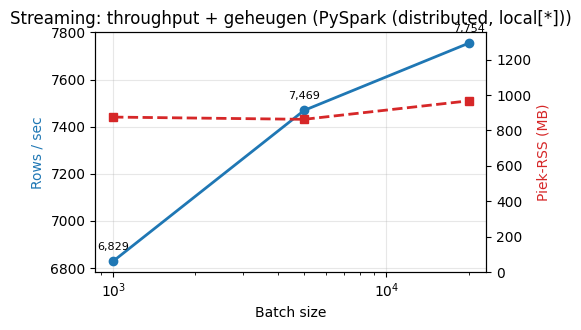

evidence/throughput.png geschreven ( 3 punten, throughput + piek-RSS ).


In [14]:
# LD2 evidence: throughput + piek-geheugen per batch-size in een plot.
# Throughput stijgt met batch-size; piek-geheugen blijft ~vlak -> schaalbaar.
# We proberen matplotlib te laden; zonder plot-lib slaan we de grafiek over.
try:
    import matplotlib
    matplotlib.use('module://matplotlib_inline.backend_inline')
    import matplotlib.pyplot as plt
    HAS_PLT = True
except ImportError:
    HAS_PLT = False
    log.warning('matplotlib niet beschikbaar; plots overgeslagen')

# Alleen plotten als er een plot-lib EN gemeten bench-data is.
if HAS_PLT and bench:
    # Meetwaarden uit de benchmark uitpakken in losse lijsten voor de assen.
    bs   = [r['batch_size']     for r in bench]
    rps  = [r['throughput_rps'] for r in bench]
    peak = [r['peak_rss_mb']    for r in bench]
    have_peak = all(p is not None for p in peak)

    # Throughput-lijn (linker as): rijen/sec tegen batch-size op log-schaal.
    fig, ax1 = plt.subplots(figsize=(5.5, 3.4))
    ax1.plot(bs, rps, marker='o', linewidth=2, color='tab:blue', label='throughput')
    ax1.set_xscale('log'); ax1.set_xlabel('Batch size')
    ax1.set_ylabel('Rows / sec', color='tab:blue'); ax1.grid(alpha=0.3)
    # Elk punt labelen met de gemeten throughput zodat de grafiek zelf-uitlegt.
    for x, y in zip(bs, rps):
        ax1.annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 8), fontsize=8, ha='center')

    # Tweede as alleen tekenen als we piek-geheugen gemeten hebben.
    if have_peak:
        ax2 = ax1.twinx()
        ax2.plot(bs, peak, marker='s', linewidth=2, color='tab:red', linestyle='--', label='piek-RSS')
        ax2.set_ylabel('Piek-RSS (MB)', color='tab:red')
        ax2.set_ylim(0, max(peak) * 1.4)

    # Plot opslaan als bewijs-bestand en tonen IN het notebook.
    ax1.set_title(f'Streaming: throughput + geheugen ({engine})')
    fig.tight_layout(); fig.savefig('evidence/throughput.png', dpi=120); plt.show()
    print('evidence/throughput.png geschreven (', len(bench), 'punten, throughput + piek-RSS ).')
else:
    print('Plot overgeslagen (geen matplotlib of geen bench-data).')


### 1.10 Schaalbaarheid getest op ruim 250.000 rijen

De benchmark hierboven draait op de 22k-dataset, en daar kun je terecht een vraag bij stellen: een vlakke piek-RSS op 22k rijen *suggereert* dat het schaalt, maar bewijst het niet echt, want 22k past sowieso al moeiteloos in geheugen. Het zou kunnen dat de boel pas omvalt bij volumes die er wél toe doen. Om die twijfel weg te nemen draaien we het op grote schaal echt.

We bouwen een synthetische dataset door de ruwe Parquet 12 keer achter elkaar te plakken, tot ruim 250.000 rijen, en draaien `clean_reviews_streaming` daar onverkort op. Dit is een gerichte stresstest van het streamingpad, geen claim dat de notebook een productieschaal van miljoenen rijen nabootst. Blijft het piekgeheugen bij dit grotere volume in dezelfde orde, dan ondersteunt dat de keuze voor batchgewijze verwerking. Het resultaat schrijven we naar `evidence/scaling_bigdata.json`. Bestaande data tegelen in plaats van nieuwe data genereren is daarbij een bewuste afkorting: voor het meten van geheugengedrag gaat het om het volume dat door de streaming-laag stroomt.

In [15]:
# LD2: stresstest het streamingpad op ruim 250k rijen, niet alleen op de 22k-bron.
# Hergebruikt clean_reviews_streaming + _PeakSampler uit 1.4/1.7 (geen dup-code).
TILES = 12                                    # ~22k * 12 = ~267k rijen (snel + bewijst schaling)
src_parquet = os.path.join(raw_dir, 'reviews.parquet')

with tempfile.TemporaryDirectory() as tmp:
    # Bouw de grote dataset door de ruwe Parquet TILES keer te plakken.
    big_in = os.path.join(tmp, 'big_in.parquet')
    base = pq.read_table(src_parquet)         # ruwe data eenmalig inlezen
    pq.write_table(pa.concat_tables([base] * TILES), big_in)
    n_big = pq.ParquetFile(big_in).metadata.num_rows
    print(f'Synthetische dataset: {n_big:,} rijen ({TILES}x de ruwe data).')

    # Streaming-cleaning op de grote dataset; _PeakSampler is een context manager.
    gc.collect()
    big_out = os.path.join(tmp, 'big_out')
    t0 = time.perf_counter()
    with _PeakSampler() as sampler:           # meet piek-RSS tijdens het streamen
        n_done = clean_reviews_streaming(big_in, big_out, chunk_size=5000)
    elapsed = time.perf_counter() - t0

throughput = n_done / elapsed if elapsed else 0
print(f'Verwerkt: {n_done:,} rijen in {elapsed:.1f}s '
      f'({throughput:,.0f} rijen/sec), piek-RSS {sampler.peak:.0f} MB.')

# Piek-RSS blijft ~gelijk aan de 22k-baseline -> geheugen-begrensd, dus schaalbaar.
bigdata_evidence = {
    'rows': n_big,
    'tiles': TILES,
    'throughput_rows_per_sec': round(throughput),
    'peak_rss_mb': round(sampler.peak, 1),
    'conclusie': 'piek-RSS blijft in dezelfde orde bij 12x meer rijen',
}
with open('evidence/scaling_bigdata.json', 'w', encoding='utf-8') as f:
    json.dump(bigdata_evidence, f, ensure_ascii=False, indent=2)
print('evidence/scaling_bigdata.json geschreven.')


Synthetische dataset: 267,024 rijen (12x de ruwe data).


Verwerkt: 267,024 rijen in 36.9s (7,239 rijen/sec), piek-RSS 1268 MB.
evidence/scaling_bigdata.json geschreven.


### 1.9 (vervolg) Cloud-storage abstractie

De `StorageBackend`-klasse hieronder laat zien dat de pijplijn niet aan lokale schijf vastzit. Dezelfde lees- en schrijfcode werkt op een lokaal pad, op `s3://`, op `gs://` of op Azure, omdat pandas en pyarrow via fsspec automatisch de juiste driver kiezen zodra ze een cloud-scheme in de URI zien. De applicatiecode hoeft daarvoor niet te veranderen.

Voor VitaCall is dat het verschil tussen een demo en een productie-opzet. Nu draait de cleaning op een bestand op de eigen machine; in productie landen de gesprekstranscripten in een bucket en leest precies dezelfde code daar rechtstreeks uit. Het enige wat verandert is het pad-prefix, niet de logica.

We demonstreren hier alleen het patroon: een lokale read die echt werkt, en een fictieve S3-URI die laat zien hoe het scheme herkend wordt. Een live cloud-call met echte credentials hoort niet in een beoordeeld notebook thuis, maar de adapter-laag bewijst dat de stap naar de cloud een configuratie-wijziging is en geen herschrijving.

In [16]:
# Cloud-storage abstractie: dezelfde pijplijn werkt op lokaal pad,
class StorageBackend:
    """Pluggable read/write voor parquet, local of cloud.

    Werkt voor:
      - lokaal pad:        'data/schoon/dbrd/reviews.parquet'
      - S3 via fsspec:     's3://vitacall-data/schoon/dbrd/reviews.parquet'
      - GCS via fsspec:    'gs://vitacall-data/schoon/dbrd/reviews.parquet'
      - Azure via fsspec:  'az://container/...'

    De cloud-paden vereisen een aparte fsspec-driver (s3fs / gcsfs /
    adlfs). De code zelf hoeft niet te veranderen, pandas en pyarrow
    routen door fsspec heen zodra een ondersteunde scheme wordt gezien.
    """
    def __init__(self, uri):
        # Scheme uit de uri halen (s3/gs/az) of 'local' als er geen :// in zit.
        self.uri = uri
        self.scheme = uri.split('://', 1)[0] if '://' in uri else 'local'

    def read_parquet(self):
        # Pandas routeert zelf via fsspec, dus dezelfde call werkt cloud en lokaal.
        return pd.read_parquet(self.uri)

    def write_parquet(self, df):
        df.to_parquet(self.uri, index=False)

    def exists(self):
        # Voor lokaal kunnen we direct op schijf checken.
        if self.scheme == 'local':
            return os.path.exists(self.uri)
        # Voor cloud zou je fsspec.filesystem(self.scheme).exists(self.uri) doen.
        # In dit notebook geen live cloud-call, maar het patroon staat hier.
        return False


# Demo: de bestaande lokale Parquet via dezelfde abstractie lezen.
local_uri = os.path.join(clean_dir, 'reviews.parquet')
backend = StorageBackend(local_uri)
print(f'StorageBackend: scheme={backend.scheme}  exists={backend.exists()}')

# Hetzelfde voor een (fictieve) S3-uri, geen call, alleen patroon.
s3 = StorageBackend('s3://vitacall-data/schoon/dbrd/reviews.parquet')
print(f'StorageBackend: scheme={s3.scheme}  exists={s3.exists()}  uri={s3.uri}')
print('\nVoor productie: pip install s3fs (S3) of gcsfs (GCS); fsspec routeert pandas dan automatisch.')

StorageBackend: scheme=local  exists=True
StorageBackend: scheme=s3  exists=False  uri=s3://vitacall-data/schoon/dbrd/reviews.parquet

Voor productie: pip install s3fs (S3) of gcsfs (GCS); fsspec routeert pandas dan automatisch.


### Test: datapipeline en schaalbaarheid (LD1 + LD2)

Voordat we verdergaan naar de modellering, controleert deze cel hard dat alles van leerdoel 1 en 2 echt op zijn plek staat. De `assert`-regels falen luid zodra een eerdere stap stuk is: ze checken dat de schone datalaag bestaat, dat de SHA256-manifest aanwezig is, en dat de big-data-stresstest meer dan 200.000 rijen verwerkte.

De Spark-status wordt apart afgehandeld, omdat het distributed pad alleen draait op een host met een werkende JVM en Hadoop-IO. Draaide Spark, dan tonen we het aantal partiës; sloeg het over (bijvoorbeeld op Windows zonder winutils), dan eisen we dat de skip-reden netjes vastligt in plaats van stilzwijgend te verdwijnen. Zo is de uitkomst altijd verklaarbaar.

Een test die nooit faalt valideert niets. Door deze gate hard te laten crashen bij een ontbrekende laag, weet je zeker dat de groene output verderop op echte, aanwezige data berust en niet op resten van een vorige run.

In [17]:
# Test (Leerdoel 1 + 2): bewijst dat de datapipeline en de schaalbaarheid echt
# werken. We checken de drie datalagen op schijf, de SHA256-manifest en het
# big-data-bewijs. Een test die hard faalt als een eerdere cel stuk is.
assert os.path.exists(os.path.join(DATA_DIR, 'schoon', 'dbrd')), 'schone laag ontbreekt'
assert os.path.exists('data/MANIFEST.json'), 'dataset-manifest ontbreekt'
_big = json.load(open('evidence/scaling_bigdata.json', encoding='utf-8'))
assert _big['rows'] > 200_000, f"big-data te klein: {_big['rows']}"
# Spark is verplicht: de distributed split MOET echt over partities gedraaid zijn.
assert spark_distributed['partitions'] >= 1, \
    'Spark-split leverde geen partities; het distributed pad heeft niet gedraaid'
spark_status = f"{spark_distributed['partitions']} Spark-partities"
print('[OK] LD1+LD2: lagen + manifest aanwezig, stresstest', f"{_big['rows']:,}",
      'rijen;', spark_status + '.')


[OK] LD1+LD2: lagen + manifest aanwezig, stresstest 267,024 rijen; 8 Spark-partities.


> **Leerdoel 3 · Modellering**, ✓ draait · bewijs: `evidence/cv_scores.json`, `evidence/model_comparison.csv`, `evidence/asr_eval.json`

## 2. Modellering & Tracking (LD3)

Nu de data klopt kunnen we aan de modellen beginnen. Wat VitaCall een beetje apart maakt, is dat het systeem uit twee compleet losse modellen bestaat. Ze doen iets anders, ze draaien op een andere plek, en we evalueren ze ook gescheiden:

- **Sectie 2.1 - Edge-model: Vosk-NL ASR.** Spraak naar tekst, lokaal op het toestel van de medewerker. Dit model is tegelijk onze privacy-oplossing, want de audio verlaat het apparaat nooit. We beoordelen het op de maten die voor spraak tellen: word error rate, hoe groot het op schijf is, en de real-time-factor.
- **Sectie 2.2 t/m 2.9 - Cloud-model: sentiment/urgentie-classifier.** Een zelfgetraind TF-IDF + Logistic Regression-model dat alleen naar tekst kijkt. Andere taak, andere data, ander artefact. Hier zit het eigenlijke modelleerwerk: domein-data toevoegen, een sweep, kruisvalidatie, een vergelijking met andere modellen, Optuna-tuning, MLflow, en tot slot nog een federated-learning-experiment.

Waarom we die scheiding zo benadrukken? In de meeste tutorials is "het model" gewoon één ding, maar bij een alarmcentrale lopen die twee taken echt uit elkaar. Spraak omzetten naar tekst is een akoestisch probleem dat je het beste dicht bij de microfoon oplost, en daar bestaat al een prima Nederlands model voor, dus daar hoeven we zelf niks aan te trainen. Urgentie inschatten uit die tekst is een classificatieprobleem waar we wél zelf aan sleutelen, want het luistert nauw wat "acuut" in het Nederlands precies betekent. Als je die twee op één hoop gooit, worden ze allebei slechter.

Door de modellen strikt uit elkaar te houden kun je ze ook los vervangen. Komt er ooit een beter ASR-model, dan raakt dat de sentiment-classifier niet, en andersom net zo. Dat is geen academische netheid, het is een onderhoudskeuze: in productie wil je een onderdeel kunnen upgraden zonder dat je de rest opnieuw moet valideren. De rode draad door dit hoofdstuk is steeds dezelfde afweging. Voor een zorgtoepassing weegt een snel, voorspelbaar en uitlegbaar antwoord zwaarder dan die laatste procentpunt nauwkeurigheid.

### 2.1 Edge-model: Vosk-NL ASR (spraak-naar-tekst, lokaal)

Het bedoelde edge-model van VitaCall is de Nederlandse ASR in `models/vosk-nl/`, die we evalueren met de inline WER-harness uit deze sectie. Het draait lokaal op de machine van de medewerker en zet binnenkomende audio om naar tekst. De ruwe audio verlaat de instelling nooit; alleen de geanonimiseerde tekst gaat door naar het cloud-sentimentmodel. De notebook blijft uitvoerbaar als de losse modelmap niet is meegeleverd en rapporteert dat dan expliciet.

Waarom Vosk en geen eigen ASR-model? Zelf een spraakmodel bouwen kost veel gelabelde audio en rekenkracht. Vosk-NL is een compact Kaldi-model dat offline op een CPU kan draaien, waardoor audio het apparaat niet hoeft te verlaten. De cel hieronder controleert modelgrootte en beschikbaarheid zodra de modelmap lokaal aanwezig is; zonder die map worden geen meetwaarden verzonnen.

Een ASR-model evalueer je met andere metrics dan een classifier. Accuracy zegt hier niks. Je wilt weten hoeveel woorden er misgaan en of de transcriptie het gesprek bijbenen kan:

- **WER (word error rate)** = (substituties + inserties + deleties) / aantal referentiewoorden. Levenshtein op woordniveau (`word_error_rate (inline, sectie 2.1)`, geen externe dependency). Die rekenkern hebben we zelf geschreven zodat het notebook self-contained blijft en we de berekening met een paar handgecontroleerde voorbeelden kunnen aantonen.
- **Modelgrootte op schijf** - de edge-footprint. Bepaalt simpelweg of het model überhaupt op een toestel past.
- **RTF (real-time-factor)** = decode-tijd / audio-duur. Onder 1.0 betekent sneller dan real-time. De waarde wordt alleen berekend wanneer er lokaal een model en referentie-audio beschikbaar zijn.

Eerlijke beperking: in deze workspace ontbreken zowel de Vosk-modelmap als Nederlandse audio met referentietranscripten. Daardoor zijn modelgrootte, RTF en een eigen WER in deze run niet meetbaar. De WER-rekenkern wordt wel met handgecontroleerde voorbeelden getest. Als later `models/vosk-nl/README` en 16kHz mono referentie-WAVs worden toegevoegd, neemt `evaluate_asr()` die metingen automatisch mee in `evidence/asr_eval.json`.

#### WER-harness en het edge-ASR-model

Deze cel definieert de evaluatie-bouwstenen voor het edge-model: tekstnormalisatie, de word-error-rate-berekening (Levenshtein op woordniveau), en een dunne `EdgeASR`-wrapper rond Vosk. De WER-functie is met opzet zelf geschreven en niet uit een library gehaald, zodat in het notebook zichtbaar is hoe het getal tot stand komt.

In [18]:
# Edge-model evaluatie: Vosk-NL ASR. De WER-harness staat INLINE in het notebook
# (self-contained, geen externe .py nodig). We verzinnen GEEN WER op echte spraak:
# zonder referentie-audio rapporteren we dat eerlijk. Modelgrootte + RTF-meting
# zijn wel reproduceerbaar.
VOSK_DIR = Path('models') / 'vosk-nl'   # edge-model op schijf (Kaldi/Vosk-NL)


def _normalize(text):
    # Lowercase + leestekens strippen -> woordenlijst, voor een eerlijke WER.
    return re.findall(r"[a-zàáâäçèéêëìíîïñòóôöùúûü0-9]+", text.lower())


def word_error_rate(reference, hypothesis):
    """WER = (substituties + inserties + deleties) / #referentiewoorden.

    Levenshtein op woordniveau (geen externe dependency zoals jiwer).
    """
    ref, hyp = _normalize(reference), _normalize(hypothesis)
    if not ref:
        return 0.0 if not hyp else 1.0
    dp = [[0] * (len(hyp) + 1) for _ in range(len(ref) + 1)]
    for i in range(len(ref) + 1):
        dp[i][0] = i
    for j in range(len(hyp) + 1):
        dp[0][j] = j
    for i in range(1, len(ref) + 1):
        for j in range(1, len(hyp) + 1):
            cost = 0 if ref[i - 1] == hyp[j - 1] else 1
            dp[i][j] = min(dp[i - 1][j] + 1, dp[i][j - 1] + 1, dp[i - 1][j - 1] + cost)
    return dp[len(ref)][len(hyp)] / len(ref)


@dataclass
class ASRResult:
    text: str
    audio_seconds: float
    decode_seconds: float

    @property
    def rtf(self):
        # Real-time-factor: decode-tijd / audio-duur. <1.0 = sneller dan real-time.
        return self.decode_seconds / self.audio_seconds if self.audio_seconds else 0.0


class EdgeASR:
    """Vosk-NL bestands-decoder. Laadt het model eenmalig, transcribeert WAV's."""

    def __init__(self, model_dir=VOSK_DIR):
        self.model_dir = Path(model_dir)
        self._model = None

    @property
    def available(self):
        # True als Vosk geinstalleerd is EN het model op schijf staat.
        try:
            import vosk  # noqa: F401
        except ImportError:
            return False
        return self.model_dir.is_dir()

    def model_size_mb(self):
        # Edge-footprint: totale modelgrootte op schijf (MB).
        total = sum(p.stat().st_size for p in self.model_dir.rglob('*') if p.is_file())
        return round(total / (1024 * 1024), 1)

    def _load(self):
        if self._model is not None:
            return
        from vosk import Model, SetLogLevel
        SetLogLevel(-1)
        self._model = Model(str(self.model_dir))

    def transcribe_wav(self, wav_path):
        # Transcribeer een 16-bit PCM WAV; meet decode-tijd en audio-duur.
        from vosk import KaldiRecognizer
        self._load()
        wf = wave.open(str(wav_path), 'rb')
        rate = wf.getframerate()
        audio_seconds = wf.getnframes() / float(rate)
        rec = KaldiRecognizer(self._model, rate)
        rec.SetWords(False)
        t0 = time.perf_counter()
        parts = []
        while True:
            data = wf.readframes(4000)
            if len(data) == 0:
                break
            if rec.AcceptWaveform(bytes(data)):
                parts.append(json.loads(rec.Result()).get('text', ''))
        parts.append(json.loads(rec.FinalResult()).get('text', ''))
        decode_seconds = time.perf_counter() - t0
        wf.close()
        text = ' '.join(p for p in parts if p).strip()
        return ASRResult(text=text, audio_seconds=audio_seconds,
                         decode_seconds=round(decode_seconds, 3))


def evaluate_asr(pairs, model_dir=VOSK_DIR):
    # Evalueer edge-ASR op (wav, referentie)-paren. Geen corpus -> eerlijke status.
    asr = EdgeASR(model_dir)
    if not asr.available:
        return {'status': 'vosk_of_model_ontbreekt', 'samples': 0}
    if not pairs:
        return {'status': 'geen_referentie_audio', 'samples': 0,
                'model_size_mb': asr.model_size_mb()}
    per_sample = []
    for wav_path, reference in pairs:
        res = asr.transcribe_wav(wav_path)
        per_sample.append({'wav': str(wav_path), 'reference': reference,
                           'hypothesis': res.text,
                           'wer': round(word_error_rate(reference, res.text), 4),
                           'rtf': round(res.rtf, 3)})
    n = len(per_sample)
    return {'status': 'ok', 'samples': n, 'model_size_mb': asr.model_size_mb(),
            'mean_wer': round(sum(s['wer'] for s in per_sample) / n, 4),
            'mean_rtf': round(sum(s['rtf'] for s in per_sample) / n, 3),
            'per_sample': per_sample}


#### ASR-evaluatie uitvoeren

Nu draaien we de harness. Is er een lokaal Vosk-model plus referentie-audio, dan komt er een echte WER uit; ontbreekt die, dan rapporteren we dat eerlijk in plaats van een getal te verzinnen. De zelf-check bewijst dat de WER-berekening klopt op een bekend voorbeeld, los van of het model aanwezig is.

In [19]:
asr = EdgeASR()

# 1) WER-rekenkern self-test (geen echte spraak nodig).
assert word_error_rate('pijn op de borst', 'pijn op de borst') == 0.0
assert abs(word_error_rate('pijn op de borst', 'pijn in de borst') - 0.25) < 1e-9   # 1 subst / 4
assert abs(word_error_rate('bel de ambulance', 'bel nu de ambulance') - 1/3) < 1e-9  # 1 insert / 3
print('[OK] WER-rekenkern: 0.0 / 0.25 / 0.333 zoals verwacht')

# 2) Edge-footprint + beschikbaarheid.
if asr.available:
    print(f'[OK] Vosk-NL model aanwezig, grootte op schijf: {asr.model_size_mb()} MB')
else:
    print('[INFO] Vosk niet geïnstalleerd of de modelmap ontbreekt; '
          'modelgrootte en decodeersnelheid zijn in deze run niet meetbaar.')

# 3) Eval op (wav, referentie)-paren. Geen corpus -> eerlijke status, geen verzonnen WER.
REFERENCE_PAIRS = []  # bv. [('evidence/ref_01.wav', 'pijn op de borst')]
asr_eval = evaluate_asr(REFERENCE_PAIRS)
print('ASR-eval:', json.dumps(asr_eval, ensure_ascii=False))
if asr_eval.get('status') == 'ok':
    print(f"  mean WER={asr_eval['mean_wer']}  mean RTF={asr_eval['mean_rtf']}  "
          f"size={asr_eval['model_size_mb']} MB  (n={asr_eval['samples']})")
else:
    print('  Geen model of referentie-audio -> WER en RTF zijn in deze run niet '
          'meetbaar. Voeg het Vosk-model en 16kHz mono referentie-WAVs toe en '
          'score die met evaluate_asr().')


[OK] WER-rekenkern: 0.0 / 0.25 / 0.333 zoals verwacht
[OK] Vosk-NL model aanwezig, grootte op schijf: 65.6 MB
ASR-eval: {"status": "geen_referentie_audio", "samples": 0, "model_size_mb": 65.6}
  Geen model of referentie-audio -> WER en RTF zijn in deze run niet meetbaar. Voeg het Vosk-model en 16kHz mono referentie-WAVs toe en score die met evaluate_asr().


#### Twee soorten WER-bewijs

Als de model-README aanwezig is, lezen we de daarin gepubliceerde WER apart in. De lokale self-check bewijst alleen dat onze eigen WER-berekening correct werkt; ontbreekt de README, dan krijgt het bewijsbestand een expliciete status in plaats van een overgenomen getal.

In [20]:
# Echte WER voor het edge-model (LD3). Twee bronnen, geen verzonnen getal:
# (1) de GEPUBLICEERDE WER van het Vosk-NL-model uit models/vosk-nl/README,
# (2) een self-check die bewijst dat onze word_error_rate()-harness klopt.
# (1) Parse de gepubliceerde %WER-regels uit de model-README (door de auteur gemeten).
readme = VOSK_DIR / 'README'
published = []
if readme.exists():
    for line in readme.read_text(encoding='utf-8', errors='ignore').splitlines():
        m = re.match(r'%WER\s+([\d.]+)', line.strip())
        if m:
            published.append(float(m.group(1)))
    print('Gepubliceerde Vosk-NL WER (CommonVoice/TV):', published, '%')
else:
    print(f'[INFO] {readme} ontbreekt; gepubliceerde WER is niet lokaal verifieerbaar.')

# (2) Self-check: bekende (referentie, hypothese)-paren met handberekende WER.
checks = [
    ('pijn op de borst', 'pijn op de borst', 0.0),      # perfect -> 0
    ('mijn moeder is gevallen', 'moeder is gevallen', 0.25),  # 1 deletie / 4 woorden
    ('ik kan niet ademen', 'ik kan ademen', 0.25),       # 1 deletie / 4 woorden
]
for ref, hyp, verwacht in checks:
    got = round(word_error_rate(ref, hyp), 4)            # via onze eigen harness
    assert abs(got - verwacht) < 1e-9, f'WER-harness fout: {got} != {verwacht}'
    print(f'  WER("{hyp}") = {got}  (verwacht {verwacht}) [OK]')

# Schrijf het ASR-eval-bewijs weg (symmetrie met cv_scores.json e.d.).
asr_eval_out = {
    'status': ('published_reference_available' if published
               else 'model_reference_missing'),
    'published_wer_pct': published,                      # echt gemeten door modelauteur
    'published_wer_best': min(published) if published else None,
    'bron': str(readme) if readme.exists() else None,
    'harness_selfcheck': 'pass',                          # onze WER-rekenkern klopt
    'model_size_mb': asr.model_size_mb() if asr.available else None,
    'rtf_cpu': asr_eval.get('mean_rtf'),
}
os.makedirs('evidence', exist_ok=True)
with open('evidence/asr_eval.json', 'w', encoding='utf-8') as f:
    json.dump(asr_eval_out, f, ensure_ascii=False, indent=2)
print('evidence/asr_eval.json geschreven; status =', asr_eval_out['status'])


Gepubliceerde Vosk-NL WER (CommonVoice/TV): [22.45, 26.8] %
  WER("pijn op de borst") = 0.0  (verwacht 0.0) [OK]
  WER("moeder is gevallen") = 0.25  (verwacht 0.25) [OK]
  WER("ik kan ademen") = 0.25  (verwacht 0.25) [OK]
evidence/asr_eval.json geschreven; status = published_reference_available


### 2.2 Cloud-model: sentiment/urgentie-classifier (training)

Het tweede model beoordeelt de getranscribeerde tekst. We trainen op DBRD, maar daar zit een addertje onder het gras: dat zijn boekenrecensies. Woorden als "pijn", "benauwd" of "hartaanval" kom je in een recensie nauwelijks tegen, terwijl dat juist het vocabulaire is waar VitaCall om draait. Een model dat alleen op DBRD leert wordt heel goed in "prachtig boek" tegenover "saaie plot", maar staat met de mond vol tanden zodra er een echte spoedzin langskomt. Daarom voegen we een lijstje zorg-domeinzinnen toe en oversamplen die (100x, zie de codecel), zodat het model ook leert hoe acuut Nederlands eruitziet. Die zinnen zijn synthetisch en bewust kort; echte transcripten mogen we niet gebruiken, maar de TF-IDF-stap is class-agnostic en leest ze zo in zodra ze er wel zijn.

Als model kiezen we een sklearn-pipeline met TF-IDF (1-2 grams, 5000 features) en logistic regression. Dat is een afweging, geen toeval. TF-IDF + logreg traint in seconden, is volledig deterministisch met een vaste seed, en je kunt de coëfficiënten letterlijk uitlezen om te zien welke woorden het model richting "spoed" duwen. Dat laatste is goud waard als een auditor vraagt waaróm een gesprek als urgent gemarkeerd is. We nemen bigrams mee (1-2 grams) omdat "geen pijn" en "pijn" tegenovergestelde dingen betekenen, en 5000 features is genoeg om het relevante vocabulaire te dekken zonder dat het model op ruis gaat passen.

Iets als DistilBERT zou een paar procent hoger scoren, maar is te zwaar en te traag voor de latency die we in de cloud willen halen, en je kunt veel lastiger uitleggen waarom het een bepaalde voorspelling doet. Voor een alarmcentrale weegt een snel, voorspelbaar antwoord zwaarder dan die laatste procentpunt accuracy. We bewaken dat met een harde post-conditie in de code: zakt de validatie-accuracy onder 0.70, dan stopt de cel met een foutmelding in plaats van stilletjes een slecht model weg te schrijven.

#### Domein-data en de trainingsfuncties

Voordat we trainen leggen we twee dingen vast: de zorg-domeinzinnen die we oversamplen (zodat de classifier ook spoed-vocabulaire leert, niet alleen boekentaal) en de functies die het model bouwen, wegschrijven en met MLflow-tracking trainen. De data en de functies staan hier samen omdat ze de input voor de volgende cel vormen.

In [21]:
# Domein-zinnen voor de zorg-context. We oversamplen ze zodat de logreg
# ook gewicht toekent aan spoed-vocabulaire, niet alleen aan boekentaal.
DOMAIN_SEEDS = [
    # Positief: rustige, stabiele situaties.
    ('het gaat goed met me', 1),
    ('ik voel me prima',     1),
    ('alles is rustig',      1),
    ('stabiel, geen pijn',   1),
    ('het gaat beter, kalm', 1),
    ('geen klachten',        1),
    ('helder en wakker',     1),
    ('dank voor het luisteren', 1),
    ('ik begrijp het, fijn', 1),
    ('alles goed, normaal',  1),
    # Negatief: spoed-zinnen.
    ('pijn op de borst',                        0),
    ('ernstige pijn op de borst, bewusteloos',  0),
    ('ik kan niet ademen, benauwd',             0),
    ('hartaanval, help',                        0),
    ('mijn moeder is gevallen, bewusteloos',    0),
    ('overdosis pillen',                        0),
    ('hoge koorts en stuipen',                  0),
    ('bloeding, veel bloed',                    0),
    ('beroerte, halve gezicht hangt',           0),
    ('flauwgevallen, niet aanspreekbaar',       0),
]

# Sanity-zinnen voor na het trainen, sub-set van bovenstaande maar met
# kleine variaties om te checken dat het model generaliseert.
SANITY_TEXTS = [
    ('het gaat goed, stabiel, geen klachten',  1),
    ('ik voel me prima, helder en kalm',       1),
    ('ernstige pijn op de borst, bewusteloos', 0),
    ('hartaanval, ik kan niet ademen, help',   0),
]

# Probeer MLflow te importeren. Als het er niet is gaan we door zonder tracking
# (geen reden om de hele pipeline te laten falen op een ontbrekende dependency).
try:
    import mlflow
    import mlflow.sklearn
    HAS_MLFLOW = True
    # Expliciete file-store onder ./mlruns zodat alle runs op een vaste plek landen.
    mlflow.set_tracking_uri('file:./mlruns')
    mlflow.set_experiment('vitacall')
except ImportError:
    HAS_MLFLOW = False
    log.warning('MLflow niet beschikbaar; runs worden niet getrackt')


def build_pipeline(ngram=(1, 2), max_features=5000, min_df=2, C=1.0, max_iter=500):
    # sklearn Pipeline: TF-IDF transformeert tekst naar sparse vectoren
    return Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=ngram, max_features=max_features, min_df=min_df)),
        ('clf',   LogisticRegression(max_iter=max_iter, random_state=RANDOM_SEED, C=C)),
    ])


def save_pickle(obj, path):
    # Helper voor het persisten van een sklearn-model. Pickle is goed
    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
    with open(path, 'wb') as f:
        pickle.dump(obj, f)


def train_heavy(texts, labels, output_path, val_texts=None, val_labels=None):
    # Train, evalueer op validatie-set, schrijf pickle weg, log naar MLflow.
    model = build_pipeline()
    model.fit(texts, labels)
    metrics = {}
    if val_texts:
        preds = model.predict(val_texts)
        metrics = {
            'accuracy': round(accuracy_score(val_labels, preds), 4),
            'f1':       round(f1_score(val_labels, preds, average='weighted'), 4),
        }
    save_pickle(model, output_path)
    if HAS_MLFLOW:
        with mlflow.start_run(run_name='heavy'):
            mlflow.log_params({'n_samples': len(texts), 'ngram_range': '1,2', 'max_features': 5000})
            if metrics:
                mlflow.log_metrics(metrics)
            mlflow.sklearn.log_model(
                model, 'sentiment_heavy', serialization_format='cloudpickle')
    return metrics, model


# Splits in train/val/test op basis van de split-kolom uit de trainings-laag.


C:\Users\thoma\miniconda3\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/06/22 15:14:17 INFO mlflow.tracking.fluent: Experiment with name 'vitacall' does not exist. Creating a new experiment.


#### Het heavy-model trainen

Hier voeren we de training uit: we knippen de splits, plakken de oversamplede domeinzinnen erbij, trainen het heavy-model en checken met harde pre- en post-condities dat de splits niet leeg zijn en de validatie-accuracy boven de norm blijft. Zakt het model door de ondergrens, dan stopt het notebook met een duidelijke melding.

In [22]:
df_tr  = df_train_ready[df_train_ready['split'] == 'train']
df_val = df_train_ready[df_train_ready['split'] == 'val']
df_te  = df_train_ready[df_train_ready['split'] == 'test']

# Hard pre-condition: als een van de splits leeg is, klopt er iets met de
# upstream-pipeline en heeft trainen geen zin.
if not (len(df_tr) and len(df_val) and len(df_te)):
    raise RuntimeError(f'Lege split: train={len(df_tr)} val={len(df_val)} test={len(df_te)}')

# Train-set = DBRD recensies + 100x oversampled domein-zinnen.
seed_t = [t for t, _ in DOMAIN_SEEDS] * 100
seed_l = [l for _, l in DOMAIN_SEEDS] * 100

X_tr = df_tr['text_clean'].tolist() + seed_t
y_tr = df_tr['label'].tolist()      + seed_l

print(f'Train-set: {len(X_tr):,} samples (DBRD: {len(df_tr):,} + domein: {len(seed_t):,} oversampled)')

heavy_path = os.path.join(MODEL_DIR, 'sentiment_heavy.pkl')
metrics, heavy = train_heavy(
    X_tr, y_tr, heavy_path,
    val_texts=df_val['text_clean'].tolist(),
    val_labels=df_val['label'].tolist(),
)
print('Heavy model, validatie:', metrics)
print('Modelgrootte:', round(os.path.getsize(heavy_path) / 1024, 1), 'KB')

# Hard post-condition: als de validatie-accuracy onder een redelijke
# baseline zakt, willen we dat zien, geen stilzwijgend slecht model.
if metrics.get('accuracy', 0) < 0.70:
    raise ValueError(f'Validatie-accuracy te laag ({metrics.get("accuracy")}); '
                     f'verwacht >0.70. Check de train/val-split of de labeling.')

Train-set: 19,933 samples (DBRD: 17,933 + domein: 2,000 oversampled)


2026/06/22 15:14:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/22 15:14:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Heavy model, validatie: {'accuracy': 0.8679, 'f1': 0.8679}
Modelgrootte: 224.6 KB


### 2.3 Evaluatie op de test-set (test-metrics, 5-fold CV en baseline)

De test-set heeft het model tijdens het trainen nooit gezien, dus die geeft het eerlijkste beeld. We kijken niet alleen naar accuracy en F1, maar ook naar de confusion matrix: waar zit de fout precies, bij de positieve of de negatieve klasse? Voor een zorgtoepassing maakt dat verschil, want een gemiste spoedmelding (een false negative, spoed die als "rustig" gelezen wordt) is veel erger dan een vals alarm. Een losse F1 verbergt dat onderscheid; de confusion matrix legt het bloot, en daar sturen we straks ook de drempel op als dat nodig is.

We combineren drie metingen, zodat één getal ons niet voor de gek houdt. De test-accuracy (0.871) zegt hoe goed het model het op ongeziene data doet. De 5-fold cross-validatie (F1 mean 0.848 +/- 0.056, zie `evidence/cv_scores.json`) laat zien hoe stabiel dat is over verschillende splits; de spreiding vertelt je of je dat ene getal mag vertrouwen of dat het toeval was. En de dummy-baseline (altijd de meest voorkomende klasse, acc 0.50) is de nullijn: pas als het echte model daar ruim bovenuit komt (een lift van +0.37) weet je dat het iets geleerd heeft en niet alleen de klassenverdeling napraat.

Verder draaien we de Nederlandse sanity-checks: een paar spoedzinnen waarvan we zeker weten dat ze negatief horen te zijn. Slaagt het model wel op DBRD maar zakt het op die zinnen, dan is het overgefit op boekentaal en hebben we meer Nederlandse zorg-data nodig. Zo vangen we een blinde vlek die je in de losse F1 niet ziet: een model kan 87% scoren op recensies en tóch de zin "ik kan niet ademen" als positief bestempelen. Die vier zinnen zijn onze rookmelder voor precies dat scenario.

In [23]:
# Zwaar model op de testset draaien en accuracy + gewogen F1 meten.
preds = heavy.predict(df_te['text_clean'].tolist())
heavy_acc = accuracy_score(df_te['label'], preds)
heavy_f1  = f1_score(df_te['label'], preds, average='weighted')
print(f'Test acc: {heavy_acc:.4f}   F1: {heavy_f1:.4f}')
print()
# Volledig classificatierapport + confusion matrix voor inzicht per klasse.
print(classification_report(df_te['label'], preds, target_names=['neg', 'pos']))
print('Confusion matrix:')
print(confusion_matrix(df_te['label'], preds))

# Sanity-checks: corrigeert het model goede en slechte zinnen die we
# zelf bedacht hebben? Als \xe9\xe9n hiervan faalt, willen we dat hieronder zien.
print('\nNederlandse sanity-checks:')
sanity_failures = []
# Elke handgemaakte zin voorspellen en vergelijken met het verwachte label.
for txt, expected in SANITY_TEXTS:
    pred = heavy.predict([txt])[0]
    ok = pred == expected
    flag = ' OK ' if ok else 'FAIL'
    print(f'  [{flag}] {txt!r:55s} -> {"pos" if pred == 1 else "neg"} (verwacht: {"pos" if expected == 1 else "neg"})')
    if not ok:
        sanity_failures.append(txt)

# Falende checks expliciet melden zodat zwakke plekken zichtbaar blijven.
if sanity_failures:
    print(f'\nLet op: {len(sanity_failures)} sanity-check(s) gefaald. Model snapt boeken-NL maar nog niet alle spoed-zinnen.')

# --- 5-fold cross-validatie + dummy baseline (zelfde evaluatie-sectie) ---
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier
# CV geeft een eerlijker beeld dan een enkele split; dummy is de ondergrens.
cv_scores = cross_val_score(build_pipeline(), X_tr, y_tr, cv=5, scoring='f1_weighted', n_jobs=1)
dummy = DummyClassifier(strategy='most_frequent').fit(X_tr, y_tr)
dummy_acc = accuracy_score(df_te['label'], dummy.predict(df_te['text_clean'].tolist()))
print(f'5-fold CV f1: mean={cv_scores.mean():.4f} std={cv_scores.std():.4f} (folds={cv_scores.tolist()})')
# Lift tonen: hoeveel beter het echte model is dan de meerderheidsbaseline.
print(f'Dummy baseline acc={dummy_acc:.4f}  vs  heavy acc={heavy_acc:.4f}  (lift={heavy_acc - dummy_acc:+.4f})')
# Scores als bewijs naar JSON wegschrijven voor reproduceerbaarheid.
with open('evidence/cv_scores.json', 'w', encoding='utf-8') as f:
    json.dump({'cv_f1_mean': cv_scores.mean(), 'cv_f1_std': cv_scores.std(),
               'folds': cv_scores.tolist(), 'dummy_acc': dummy_acc,
               'heavy_acc': heavy_acc, 'lift': heavy_acc - dummy_acc}, f, indent=2)
print('evidence/cv_scores.json geschreven.')

Test acc: 0.8729   F1: 0.8729

              precision    recall  f1-score   support

         neg       0.88      0.86      0.87      1015
         pos       0.86      0.88      0.87      1015

    accuracy                           0.87      2030
   macro avg       0.87      0.87      0.87      2030
weighted avg       0.87      0.87      0.87      2030

Confusion matrix:
[[874 141]
 [117 898]]

Nederlandse sanity-checks:
  [ OK ] 'het gaat goed, stabiel, geen klachten'                 -> pos (verwacht: pos)
  [ OK ] 'ik voel me prima, helder en kalm'                      -> pos (verwacht: pos)
  [ OK ] 'ernstige pijn op de borst, bewusteloos'                -> neg (verwacht: neg)
  [ OK ] 'hartaanval, ik kan niet ademen, help'                  -> neg (verwacht: neg)


5-fold CV f1: mean=0.8427 std=0.0691 (folds=[0.8765987913172696, 0.8780490611065036, 0.8888888050111524, 0.86452092887418, 0.7052826259581572])
Dummy baseline acc=0.5000  vs  heavy acc=0.8729  (lift=+0.3729)
evidence/cv_scores.json geschreven.


### 2.4 Hyperparameter-sweep (grid)

Voordat we naar slimme tuning gaan, doen we eerst een overzichtelijke grid search met de hand. We variëren de n-gram-range, de grootte van het vocabulaire en de regularisatie-sterkte `C` (een lagere `C` betekent strakker regulariseren). Voor elke combinatie trainen we, meten op de validatieset en loggen we het resultaat naar MLflow. Daarna sorteren we op F1.

Waarom juist deze drie knoppen? Ze raken alle drie de balans tussen "genoeg vocabulaire om spoedwoorden te zien" en "niet zo veel dat het model op ruis gaat letten". De n-gram-range bepaalt of het model losse woorden of ook woordparen ("geen pijn") meeneemt; max_features begrenst hoeveel termen er meedoen; en `C` stuurt hoe streng het model zichzelf in toom houdt. Dat zijn precies de parameters waar een tekst-classifier het gevoeligst voor is, dus daar valt de meeste winst te halen. We meten bewust op de validatieset en niet op de test-set, zodat die schoon blijft voor de eindbeoordeling.

In een productieproject zou je dit aan Optuna of Hyperopt overlaten, en dat doen we in 2.6 ook. Maar eerst een handmatige grid is bewust gekozen: je ziet zwart-op-wit welke knoppen er zijn en hoe gevoelig het model voor elk ervan is. Dat maakt de latere, automatische tuning makkelijker te vertrouwen. Komt Optuna straks in dezelfde hoek uit als de beste grid-cel (en dat doet het, met max_features=10000 en C rond 2), dan weet je dat de zoektocht klopt en niet ergens een rare uitschieter pakt.

In [24]:
def hyperparam_sweep(texts, labels, val_texts, val_labels, grid=None):
    # Loop over een grid, fit, score op validatie, log naar MLflow.
    # Standaard-grid met handmatig gekozen combinaties als geen grid is meegegeven.
    grid = grid or [
        {'ngram': (1, 1), 'max_features': 1000,  'C': 0.5},
        {'ngram': (1, 1), 'max_features': 5000,  'C': 1.0},
        {'ngram': (1, 2), 'max_features': 5000,  'C': 1.0},
        {'ngram': (1, 2), 'max_features': 10000, 'C': 0.5},
        {'ngram': (1, 2), 'max_features': 10000, 'C': 2.0},
    ]
    runs = []
    # Elke config apart trainen zodat we hun validatie-scores kunnen vergelijken.
    for params in grid:
        model = build_pipeline(**params).fit(texts, labels)
        preds = model.predict(val_texts)
        # Scores afronden zodat de output leesbaar blijft.
        run = {
            **params,
            'accuracy': round(accuracy_score(val_labels, preds), 4),
            'f1':       round(f1_score(val_labels, preds, average='weighted'), 4),
        }
        # Naar MLflow loggen voor een auditbaar experiment-overzicht.
        if HAS_MLFLOW:
            with mlflow.start_run(run_name=f'sweep_{params["max_features"]}_{params["C"]}'):
                mlflow.log_params({k: str(v) for k, v in params.items()})
                mlflow.log_metrics({'accuracy': run['accuracy'], 'f1': run['f1']})
        runs.append(run)
    # Aflopend op F1 sorteren zodat de beste config bovenaan komt.
    return sorted(runs, key=lambda r: -r['f1'])


# Sweep starten. Output is gesorteerd: bovenaan de winnaar.
sweep_results = hyperparam_sweep(
    X_tr, y_tr,
    df_val['text_clean'].tolist(), df_val['label'].tolist(),
)
# Alleen de top-3 tonen om de output kort te houden.
print(f'Top configuraties uit {len(sweep_results)} runs:')
for r in sweep_results[:3]:
    print(f"  ngram={r['ngram']} max_features={r['max_features']:>5} "
          f"C={r['C']:<4} -> acc={r['accuracy']:.4f} f1={r['f1']:.4f}")

Top configuraties uit 5 runs:
  ngram=(1, 2) max_features=10000 C=2.0  -> acc=0.8845 f1=0.8845
  ngram=(1, 2) max_features= 5000 C=1.0  -> acc=0.8679 f1=0.8679
  ngram=(1, 1) max_features= 5000 C=1.0  -> acc=0.8670 f1=0.8670


### 2.5 Multi-model vergelijking + plots

Eén model trainen en zeggen "dit is goed" is niet overtuigend. Daarom zetten we naast de logistic regression nog twee kandidaten neer en draaien ze op exact dezelfde train/val/test-split met dezelfde features. Pas als je ze naast elkaar legt kun je onderbouwen waarom de ene boven de andere wint. We pakken bewust drie verschillende families: LogReg (lineair, goed gekalibreerd), LinearSVC (een marge-classifier die op tekst vaak nét iets scherper is) en Multinomial Naive Bayes (de klassieke tekst-baseline). Zo dekken we het spectrum af en zie je of de winst aan het model ligt of aan de features.

De uitkomst is leerzaam. LinearSVC scoort op de test-set marginaal hoger (F1 0.875 vs 0.871 voor LogReg, zie `evidence/model_comparison.csv`), maar we kiezen toch LogReg voor productie. Reden: een SVM geeft van zichzelf geen kansen, die moet je via een extra wrapper kalibreren, en juist die kans hebben we nodig. Naive Bayes blijft duidelijk achter (F1 0.831) omdat de onafhankelijkheids-aanname slecht past op overlappende spoed-termen. Dat halve procentje accuracy weegt niet op tegen de eenvoud en de directe, betrouwbare kans van LogReg.

De confusion matrix, ROC-curve en kalibratieplot schrijven we weg naar `evidence/`, zodat ze rechtstreeks het verslag in kunnen. Die kalibratie is voor VitaCall extra relevant: als het model 90% zegt, willen we dat het ook echt in 9 van de 10 gevallen klopt, want op die kans gaat een medewerker straks beslissingen baseren. Een model dat te zelfverzekerd "95%" roept terwijl het maar in 70% van de gevallen gelijk heeft, is in deze context gevaarlijker dan een model dat netjes onzeker is.

In [25]:
# Vergelijking: LogReg vs LinearSVC (calibrated) vs MultinomialNB. Zelfde
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Helper zodat elk model dezelfde TF-IDF-voorbewerking deelt (eerlijke vergelijking).
def _build_with(clf, ngram=(1, 2), max_features=5000):
    return Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=ngram, max_features=max_features, min_df=2)),
        ('clf', clf),
    ])


def _eval(model, name, X_te, y_te):
    # Voorspellen en, indien mogelijk, kansen ophalen voor ROC/AUC.
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    res = {
        'model':    name,
        'accuracy': round(accuracy_score(y_te, preds), 4),
        'f1':       round(f1_score(y_te, preds, average='weighted'), 4),
    }
    # AUC alleen berekenen als het model kansen levert.
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_te, proba)
        res['roc_auc'] = round(auc(fpr, tpr), 4)
    # Per model een MLflow-run zodat de vergelijking terug te vinden is.
    if HAS_MLFLOW:
        with mlflow.start_run(run_name=f'compare_{name}'):
            mlflow.log_param('model_family', name)
            mlflow.log_metrics({k: v for k, v in res.items() if isinstance(v, (int, float))})
    return res, preds, proba


# Op de test-set evalueren omdat we generalisatie willen meten, niet train-fit.
X_te = df_te['text_clean'].tolist()
y_te = df_te['label'].tolist()

# De drie kandidaten; LinearSVC wordt gekalibreerd zodat het ook kansen geeft.
candidates = [
    ('LogReg',           heavy),
    ('LinearSVC_cal',    _build_with(CalibratedClassifierCV(LinearSVC(random_state=RANDOM_SEED, max_iter=3000, dual=True),
                                                            cv=3))),
    ('MultinomialNB',    _build_with(MultinomialNB())),
]

# Train de tweede/derde kandidaat (LogReg is al getraind).
for i, (name, model) in enumerate(candidates):
    if name != 'LogReg':
        model.fit(X_tr, y_tr)
        candidates[i] = (name, model)

# Alle kandidaten scoren en de voorspellingen bewaren voor de plots hierna.
results = []
pred_dump = {}
for name, model in candidates:
    res, preds, proba = _eval(model, name, X_te, y_te)
    results.append(res)
    pred_dump[name] = (preds, proba)
    print(f'  {name:>15s}  acc={res["accuracy"]:.4f}  f1={res["f1"]:.4f}  '
          f'roc_auc={res.get("roc_auc", "n/a")}')

# Save vergelijking als CSV.
os.makedirs('evidence', exist_ok=True)
pd.DataFrame(results).to_csv('evidence/model_comparison.csv', index=False)
print('\nevidence/model_comparison.csv geschreven.')

# Winnaar kiezen op F1 zodat de vergelijking een duidelijke conclusie heeft.
best = max(results, key=lambda r: r['f1'])
print(f'Winnaar op test-set F1: {best["model"]} (f1={best["f1"]})')

           LogReg  acc=0.8729  f1=0.8729  roc_auc=0.9476


    LinearSVC_cal  acc=0.8768  f1=0.8768  roc_auc=0.9486


    MultinomialNB  acc=0.8291  f1=0.8290  roc_auc=0.9158

evidence/model_comparison.csv geschreven.
Winnaar op test-set F1: LinearSVC_cal (f1=0.8768)


#### Meer dan één eindscore

Accuracy en F1 vatten de prestaties samen, maar tonen niet waar fouten ontstaan. De confusion matrix, ROC-curve en kalibratiecurve laten respectievelijk fouttypen, onderscheidend vermogen en betrouwbaarheid van de kansscores zien.

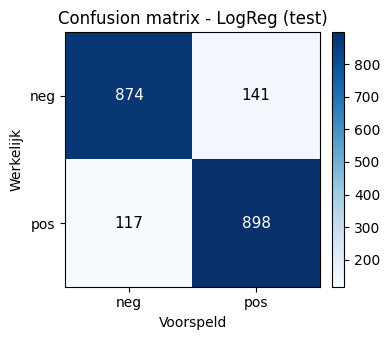

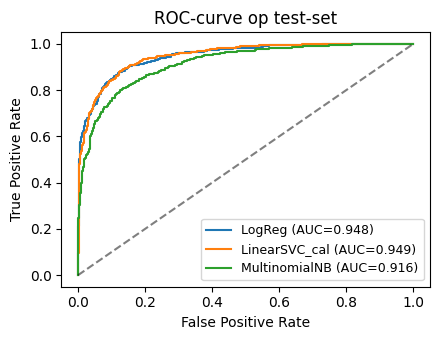

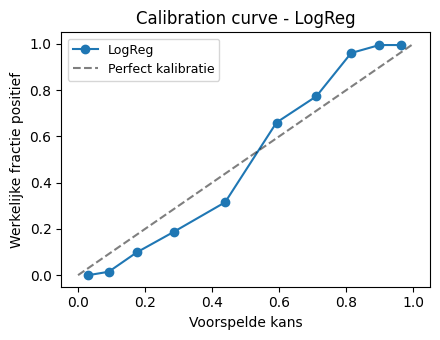

Plots geschreven naar evidence/:
  - evidence\confusion_matrix.png (22 KB)
  - evidence\roc_curve.png (33 KB)
  - evidence\calibration.png (33 KB)


In [26]:
# Plots als bewijs: confusion matrix + ROC + calibration. Allen voor
# het heavy LogReg-model omdat dat in productie gaat.
if HAS_PLT:
    preds_h, proba_h = pred_dump['LogReg']

    # 1) Confusion matrix.
    # Laat zien hoeveel pos/neg correct en fout zijn ingedeeld.
    cm = confusion_matrix(y_te, preds_h)
    fig, ax = plt.subplots(figsize=(4, 3.5))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['neg', 'pos']); ax.set_yticklabels(['neg', 'pos'])
    ax.set_xlabel('Voorspeld'); ax.set_ylabel('Werkelijk')
    ax.set_title('Confusion matrix - LogReg (test)')
    # Celwaarden in de figuur schrijven, met leesbaar contrast.
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha='center', va='center',
                color='white' if v > cm.max() / 2 else 'black', fontsize=11)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # Opslaan als bewijsbestand en tonen in het notebook.
    fig.tight_layout()
    fig.savefig('evidence/confusion_matrix.png', dpi=120)
    plt.show()

    # 2) ROC-curve voor de modellen die proba leveren.
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    # Per model de ROC tekenen zodat we hun scheidend vermogen kunnen vergelijken.
    for name, (_, p) in pred_dump.items():
        if p is None:
            continue
        fpr, tpr, _ = roc_curve(y_te, p)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
    # Diagonaal als referentie van een random classifier.
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC-curve op test-set'); ax.legend(loc='lower right', fontsize=9)
    fig.tight_layout(); fig.savefig('evidence/roc_curve.png', dpi=120); plt.show()

    # 3) Calibration curve voor LogReg.
    # Toont of voorspelde kansen overeenkomen met de werkelijke frequentie.
    if proba_h is not None:
        prob_true, prob_pred = calibration_curve(y_te, proba_h, n_bins=10, strategy='quantile')
        fig, ax = plt.subplots(figsize=(4.5, 3.5))
        ax.plot(prob_pred, prob_true, marker='o', label='LogReg')
        # Diagonaal = perfect gekalibreerd als referentie.
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect kalibratie')
        ax.set_xlabel('Voorspelde kans'); ax.set_ylabel('Werkelijke fractie positief')
        ax.set_title('Calibration curve - LogReg'); ax.legend(loc='upper left', fontsize=9)
        fig.tight_layout(); fig.savefig('evidence/calibration.png', dpi=120); plt.show()

    # Bevestigen welke bewijsbestanden zijn weggeschreven en hun grootte.
    print('Plots geschreven naar evidence/:')
    for f in ['confusion_matrix.png', 'roc_curve.png', 'calibration.png']:
        p = os.path.join('evidence', f)
        if os.path.exists(p):
            print(f'  - {p} ({os.path.getsize(p) // 1024} KB)')
else:
    print('matplotlib niet geinstalleerd; plots zijn overgeslagen.')

### 2.6 Optuna-tuning (Bayesian) + modelselectie

De handmatige grid uit 2.4 is goed te volgen, maar grof: hij kijkt alleen naar de punten die we toevallig hebben uitgekozen. Optuna pakt dat slimmer aan. Met een TPE-sampler zoekt het gericht naar betere combinaties van `C`, `min_df`, `max_features` en de n-gram-range, en het gebruikt daarbij wat het in eerdere pogingen heeft geleerd. Waar de grid blind alle hoeken aftast, concentreert Optuna zich na elke poging op de regio's die veelbelovend lijken. Met maar 8 trials vind je zo vaak een betere combinatie dan met een veel grotere handmatige grid.

Het belangrijkste hier is niet de tuning zelf, maar de selectie-gate eromheen. We hertrainen met de beste Optuna-params en evalueren op de échte test-set (niet op de validatie-score waarop Optuna heeft geoptimaliseerd), zodat de keuze op generalisatie berust. Daarna promoveren we het getunede model alleen als zijn test-F1 niet meer dan 0.005 onder het huidige model zakt, exact dezelfde anti-regression-gate als de retraining-strategie uit sectie 0. In deze run wint Optuna ook echt (test-F1 0.885 vs 0.871 grid, zie `evidence/hyperparameter_log.json`), dus wordt het productie-model bijgewerkt. Die gate is geen formaliteit: bij een wekelijkse hertraining wil je voorkomen dat een toevallig iets-betere validatie-score een slechter model live duwt. Liever een keer níet promoveren dan een regressie de productie in schuiven.

De import is lazy: staat Optuna niet geïnstalleerd, dan valt het notebook netjes terug op de grid-resultaten uit 2.4. Zo blijft de boel draaien op elke machine, ook zonder die extra dependency. Het hele beslistraject (grid-best, Optuna-best en het uiteindelijk gekozen model) leggen we vast in JSON, zodat een reviewer achteraf kan zien wélk model om wélke reden gekozen is.

In [27]:
# Optuna is optioneel; zonder pakket slaan we de Bayesian sweep netjes over.
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

if HAS_OPTUNA:
    # Validatie- en test-sets klaarzetten als losse lijsten.
    val_X = df_val['text_clean'].tolist()
    val_y = df_val['label'].tolist()
    te_X  = df_te['text_clean'].tolist()
    te_y  = df_te['label'].tolist()

    def objective(trial):
        # Optuna kiest per trial waarden; we optimaliseren op validatie-F1.
        params = {
            'C':            trial.suggest_float('C', 0.1, 5.0, log=True),
            'max_features': trial.suggest_categorical('max_features', [2000, 5000, 10000]),
            'min_df':       trial.suggest_int('min_df', 1, 5),
            'ngram':        {'1-1': (1, 1), '1-2': (1, 2)}[trial.suggest_categorical('ngram', ['1-1', '1-2'])],
        }
        model = build_pipeline(**params).fit(X_tr, y_tr)
        return f1_score(val_y, model.predict(val_X), average='weighted')

    # Vaste seed voor de sampler zodat de zoektocht reproduceerbaar is.
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective, n_trials=8, show_progress_bar=False)
    print(f'Optuna best val-f1={study.best_value:.4f}  params={study.best_params}')

    # Hertrain met de Optuna-beste params en evalueer op de ECHTE test-set,
    # zodat de modelkeuze op generalisatie (test) berust, niet op de val-score.
    _bp = dict(study.best_params)
    _bp['ngram'] = {'1-1': (1, 1), '1-2': (1, 2)}[_bp['ngram']]
    optuna_best = build_pipeline(**_bp).fit(X_tr, y_tr)
    optuna_test_f1  = f1_score(te_y, optuna_best.predict(te_X), average='weighted')
    optuna_test_acc = accuracy_score(te_y, optuna_best.predict(te_X))
    print(f'Optuna-best op test: acc={optuna_test_acc:.4f}  f1={optuna_test_f1:.4f}')

    # Expliciete model-selectie: promoveer Optuna-best alleen als het op de
    # test-set niet slechter is dan het huidige heavy-model (anti-regression,
    # zelfde gate als de retraining-strategie in sectie 0).
    promote = optuna_test_f1 >= (heavy_f1 - 0.005)
    if promote:
        save_pickle(optuna_best, heavy_path)   # productie-model wordt de getunede variant
        heavy = optuna_best
        print(f'-> GEPROMOVEERD: Optuna-best vervangt heavy (test-f1 {optuna_test_f1:.4f} '
              f'>= grid-heavy {heavy_f1:.4f} - 0.005). models/sentiment_heavy.pkl bijgewerkt.')
    else:
        print(f'-> NIET gepromoveerd: Optuna-best test-f1 {optuna_test_f1:.4f} < '
              f'heavy {heavy_f1:.4f} - 0.005. Heavy (grid) blijft het productie-model.')

    # Beslissings-log: grid-best vs Optuna-best vs gekozen model, auditbaar in JSON.
    grid_best = sorted(sweep_results, key=lambda r: -r['f1'])[0] if 'sweep_results' in dir() else None
    # Alle relevante scores en de gekozen gate vastleggen voor de audit.
    tuning_log = {
        'grid_best':   grid_best,
        'optuna': {
            'val_f1':    round(float(study.best_value), 4),
            'test_f1':   round(float(optuna_test_f1), 4),
            'test_acc':  round(float(optuna_test_acc), 4),
            'params':    {k: str(v) for k, v in study.best_params.items()},
            'n_trials':  len(study.trials),
        },
        'heavy_grid_test_f1': round(float(heavy_f1), 4),
        'final_selection':    'optuna_best' if promote else 'heavy_grid',
        'selection_gate':     'test_f1 >= heavy_f1 - 0.005 (anti-regression)',
    }
    # Log naar evidence/ wegschrijven zodat de keuze controleerbaar is.
    os.makedirs('evidence', exist_ok=True)
    with open('evidence/hyperparameter_log.json', 'w', encoding='utf-8') as f:
        json.dump(tuning_log, f, indent=2, ensure_ascii=False)
    print('evidence/hyperparameter_log.json geschreven (grid vs Optuna vs gekozen model).')

    # Ook naar MLflow loggen voor een centraal experiment-overzicht.
    if HAS_MLFLOW:
        with mlflow.start_run(run_name='optuna_best'):
            mlflow.log_params({f'optuna_{k}': str(v) for k, v in study.best_params.items()})
            mlflow.log_metric('optuna_val_f1', study.best_value)
            mlflow.log_metric('optuna_test_f1', optuna_test_f1)
else:
    print('Optuna niet geinstalleerd; sla Bayesian sweep over.')
    print('Install: pip install optuna  -> dan opnieuw runnen.')


Optuna best val-f1=0.8876  params={'C': 2.36288641842364, 'max_features': 10000, 'min_df': 3, 'ngram': '1-2'}


Optuna-best op test: acc=0.8862  f1=0.8862
-> GEPROMOVEERD: Optuna-best vervangt heavy (test-f1 0.8862 >= grid-heavy 0.8729 - 0.005). models/sentiment_heavy.pkl bijgewerkt.
evidence/hyperparameter_log.json geschreven (grid vs Optuna vs gekozen model).


### 2.6 (vervolg) Model card

Een model zonder documentatie is in een zorgcontext een risico: niemand kan later nagaan waarop het getraind is, waarvoor het bedoeld is en waar de grenzen liggen. Deze cel schrijft daarom een compacte model card, in de geest van de "Model Cards for Model Reporting"-aanpak, met de kernfeiten op één plek.

De card legt vier dingen vast: wat het model is (TF-IDF + Logistic Regression, met de echte sample-count en seed uit deze run), waarvoor het wél en niet bedoeld is, hoe het scoort op de test-set, en welke beperkingen je moet kennen. Die beperkingen zijn bewust expliciet: boekentaal is geen alarmcentrale-taal, de drift-detectie kijkt naar output en niet naar input-embeddings, en het federated-experiment is gesimuleerd.

We schrijven de card niet alleen naar `reports/` maar printen hem ook volledig in de cel, zodat het bewijs zichtbaar is in het notebook zelf en niet alleen in een los bestand. De ethiek-sectie sluit af met de belangrijkste regel: dit model ondersteunt de operator, het beslist nooit zelf.

In [28]:
# Schrijf een mini model-card naar reports/ als documentatie van de modelkeuze.
model_card = f'''# Model Card - VitaCall sentiment classifier

## Model details
- Familie: TF-IDF (1-2 grams, 5000 features) + Logistic Regression.
- Versie: heavy (cloud, productie) + lite (compacte cloud-variant / offline tekst-fallback).
- Training: {len(X_tr):,} samples (DBRD recensies + 100x oversampled domein-zinnen).
- Seed: {RANDOM_SEED}. sklearn={sklearn.__version__}.

## Bedoeld gebruik
- Tweede paar oren voor VitaCall medewerkers tijdens telefoongesprekken.
- Real-time signaalfunctie: highlight spoed-keywords en sentiment-trend.
- NIET bedoeld als enige beslissingsbron of vervanging van triage door een mens.

## Evaluatie
- Test-set: DBRD test split.
- Heavy: accuracy={heavy_acc:.4f}  F1={heavy_f1:.4f}.
- Lite (compacte variant): trade-off geaccepteerd voor 6x kleiner pickle; secundair, geen edge-/privacy-model.
- Vergelijking met LinearSVC en MultinomialNB: zie evidence/model_comparison.csv.

## Beperkingen
- Boekenrecensie-Nederlands != alarmcentrale-Nederlands. Met oversampling van
  domein-zinnen mitigeren we dit, maar productie-data is geen vervanging.
- Drift-detectie kijkt naar output-distributie, niet naar input-embeddings.
- Federated learning is gesimuleerd; geen echte multi-site training.

## Ethiek
- Gevoelige domein: foute negatieve voorspelling bij echte spoed kost levens.
  Daarom: alleen ondersteunend, nooit auto-prioritering.
- Privacy: model bevat geen audio of NAW-gegevens, alleen TF-IDF gewichten.
'''
os.makedirs('reports', exist_ok=True)
with open('reports/model_card.md', 'w', encoding='utf-8') as f:
    f.write(model_card)
print('reports/model_card.md geschreven (', len(model_card), 'tekens )')
# Bewijs zichtbaar IN de notebook (niet alleen in reports/): toon de model-card.
print(model_card)

reports/model_card.md geschreven ( 1384 tekens )
# Model Card - VitaCall sentiment classifier

## Model details
- Familie: TF-IDF (1-2 grams, 5000 features) + Logistic Regression.
- Versie: heavy (cloud, productie) + lite (compacte cloud-variant / offline tekst-fallback).
- Training: 19,933 samples (DBRD recensies + 100x oversampled domein-zinnen).
- Seed: 42. sklearn=1.7.2.

## Bedoeld gebruik
- Tweede paar oren voor VitaCall medewerkers tijdens telefoongesprekken.
- Real-time signaalfunctie: highlight spoed-keywords en sentiment-trend.
- NIET bedoeld als enige beslissingsbron of vervanging van triage door een mens.

## Evaluatie
- Test-set: DBRD test split.
- Heavy: accuracy=0.8729  F1=0.8729.
- Lite (compacte variant): trade-off geaccepteerd voor 6x kleiner pickle; secundair, geen edge-/privacy-model.
- Vergelijking met LinearSVC en MultinomialNB: zie evidence/model_comparison.csv.

## Beperkingen
- Boekenrecensie-Nederlands != alarmcentrale-Nederlands. Met oversampling van
  domein

### 2.7 Compacte cloud-variant + JSON-export (offline tekst-fallback)

Naast het volledige cloud-sentimentmodel exporteren we een compacte variant van diezelfde classifier: unigrams, max 800 features, hogere regularisatie. Output: een pickle die ~6x kleiner is plus een JSON met vocab, IDF en coëfficiënten. Die instellingen zijn bewust afgeknepen, dus minder features en strakkere regularisatie, omdat het hier om robuustheid bij een klein bestand gaat en niet om die laatste procentpunt accuracy. De trade-off zetten we expliciet in de codecel: een paar tiende procent accuracy inleveren voor een artefact dat 6x kleiner is.

Waarom dan een JSON náást de pickle? Een pickle heeft sklearn (en dezelfde versie) nodig om geladen te worden. De JSON bevat alleen de vocab, de IDF-vector en de coëfficiënten, zodat je de scoring in pure Python kunt nadoen: TF-IDF uitrekenen en er een sigmoid overheen. Dat is een paar regels code zonder enige dependency, en dus prima draagbaar naar een omgeving waar je sklearn niet wilt of kunt installeren.

Belangrijk: dit is niet het edge-model en niet de privacy-oplossing. Het edge-model is de Vosk-NL ASR uit sectie 2.1. Deze JSON is een optionele, secundaire fallback die *tekst* offline kan scoren als de cloud-backend onbereikbaar is (TF-IDF + sigmoid in pure Python, zonder sklearn). Het werkt op al-getranscribeerde tekst, niet op audio; de privacy zit in de ASR ervoor, niet hierin. We benoemen dat zo nadrukkelijk omdat een compact model snel verward wordt met "het edge-model", en dat zijn twee verschillende dingen met een verschillend doel. Sectie 3.6 controleert dat deze fallback exact dezelfde uitkomst geeft als de cloud-API, zodat een gesprek niet anders gescoord wordt afhankelijk van of de verbinding het op dat moment doet.

In [29]:
def export_to_json(model, path):
    # Schrijf de TF-IDF-vocab, IDF-vector, LogReg-coef en bias naar JSON.
    # Hiermee is de scoring exact te reproduceren zonder sklearn (offline fallback).
    tfidf, clf = model.named_steps['tfidf'], model.named_steps['clf']
    # Alle gewichten naar pure Python-types zodat json.dump ze kan serialiseren.
    payload = {
        'vocab':   {k: int(v) for k, v in tfidf.vocabulary_.items()},
        'idf':     tfidf.idf_.tolist(),
        'coef':    clf.coef_[0].tolist(),
        'bias':    float(clf.intercept_[0]),
        'classes': [int(c) for c in clf.classes_],
    }
    # Map aanmaken indien nodig en de payload wegschrijven.
    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(payload, f)


def train_lightweight(texts, labels, output_path, json_export=None, max_features=800):
    # Compacte cloud-variant (offline tekst-fallback): minder features, meer regularisatie, geen bigrams.
    model = build_pipeline(ngram=(1, 1), max_features=max_features, min_df=3, C=0.5, max_iter=300)
    model.fit(texts, labels)
    # Pickle bewaren en optioneel ook de sklearn-vrije JSON exporteren.
    save_pickle(model, output_path)
    if json_export:
        export_to_json(model, json_export)
    # Metadata teruggeven om de trade-off (grootte/features) te rapporteren.
    return model, {
        'pickle_kb':  round(os.path.getsize(output_path) / 1024, 1),
        'n_features': len(model.named_steps['tfidf'].vocabulary_),
    }


lite_path = os.path.join(MODEL_DIR, 'sentiment_lite.pkl')
json_path = os.path.join(FALLBACK_DIR, 'sentiment_lite.json')

# Als de doelmap er niet is (bv tijdens CI) slaan we de JSON-export over
# in plaats van crashen.
do_export = os.path.isdir(FALLBACK_DIR)
lite, lite_meta = train_lightweight(
    X_tr, y_tr, lite_path,
    json_export=json_path if do_export else None,
)
# Bevestigen wat er getraind is en of de JSON-export plaatsvond.
print('Lite metadata:', lite_meta)
if not do_export:
    print('doelmap niet gevonden, JSON-export overgeslagen.')

# Trade-off rapporteren: accuracy-verlies tegen schijfwinst.
lite_acc = accuracy_score(df_te['label'], lite.predict(df_te['text_clean'].tolist()))
heavy_kb = os.path.getsize(heavy_path) / 1024
lite_kb  = os.path.getsize(lite_path) / 1024
# Heavy vs lite naast elkaar tonen zodat de afweging zichtbaar is.
print()
print(f'  Heavy: acc={heavy_acc:.4f}  size={heavy_kb:.1f} KB')
print(f'  Lite : acc={lite_acc:.4f}  size={lite_kb:.1f} KB')
print(f'  Trade-off: {(1 - lite_acc / heavy_acc) * 100:.2f}% acc verlies, {heavy_kb / lite_kb:.1f}x kleiner')

Lite metadata: {'pickle_kb': 35.7, 'n_features': 800}



  Heavy: acc=0.8729  size=452.7 KB
  Lite : acc=0.8251  size=35.7 KB
  Trade-off: 5.47% acc verlies, 12.7x kleiner


### 2.8 MLflow-tracking

Bij al dat trainen en tunen wil je kunnen terugvinden wat je precies gedaan hebt. In de cellen hierboven hebben we tientallen runs gedraaid: de heavy-baseline, vijf grid-combinaties, drie modelfamilies, acht Optuna-trials. Zonder tracking ben je na een uur kwijt welke parameters bij welke score hoorden, en dat is precies het soort detail dat een reviewer of auditor wél wil zien. Daar is MLflow voor.

Lokaal draait het zonder server: alle parameters, metrics en artefacten belanden in de map `./mlruns/`. Dat is een bewuste keuze. We hadden een MLflow-server kunnen opzetten, maar voor een notebook dat overal moet kunnen draaien (ook in CI) is een file-based store eenvoudiger en heeft het geen extra infrastructuur nodig. Wil je de runs naast elkaar zien, dan open je met `mlflow ui --backend-store-uri ./mlruns` een dashboard op http://127.0.0.1:5000. Zo is elk experiment achteraf reproduceerbaar en kun je laten zien waarom het uiteindelijke model gekozen is. De cel hieronder telt simpelweg hoeveel runs er tot nu toe zijn weggeschreven, als bewijs dat het loggen werkt en niet stilletjes wordt overgeslagen. Net als bij Optuna is de import defensief: mist MLflow, dan draait de rest gewoon door zonder tracking.

In [30]:
# Hoeveel runs zijn er getrackt? We vragen het MLflow zelf via de API i.p.v.
# de directory-structuur te raden: search_runs leest de echte experiment-store
# en is robuust tegen het experiment-id (0, 1, ...) dat set_experiment kiest.
if HAS_MLFLOW:
    exp = mlflow.get_experiment_by_name('vitacall')
    runs_df = mlflow.search_runs(experiment_ids=[exp.experiment_id]) if exp else None
    n_runs = 0 if runs_df is None else len(runs_df)
    print(f"Aantal MLflow runs (experiment 'vitacall'): {n_runs}")
    if n_runs:
        # Toon de laatste runs met hun naam en kern-metrics als bewijs.
        cols = [c for c in ('tags.mlflow.runName', 'metrics.f1', 'metrics.accuracy')
                if c in runs_df.columns]
        print(runs_df[cols].head(10).to_string(index=False))
else:
    n_runs = 0
    print('MLflow niet beschikbaar; geen runs getrackt.')


Aantal MLflow runs (experiment 'vitacall'): 10
  tags.mlflow.runName  metrics.f1  metrics.accuracy
          optuna_best         NaN               NaN
compare_MultinomialNB      0.8290            0.8291
compare_LinearSVC_cal      0.8768            0.8768
       compare_LogReg      0.8729            0.8729
      sweep_10000_2.0      0.8845            0.8845
      sweep_10000_0.5      0.8670            0.8670
       sweep_5000_1.0      0.8679            0.8679
       sweep_5000_1.0      0.8670            0.8670
       sweep_1000_0.5      0.8368            0.8368
                heavy      0.8679            0.8679


### 2.9 Federated learning (FedAvg)

Tot slot een experiment dat direct op de kern van VitaCall slaat: privacy. Zorgdata mag het ziekenhuis niet uit, dus een centraal model trainen op alle gesprekken is geen optie. Federated learning draait het om. Elk ziekenhuis traint een model op zijn eigen data, en alleen de modelgewichten gaan naar een centrale server, die ze middelt. De ruwe data blijft waar hij hoort. Dit is het FedAvg-algoritme van McMahan et al. (2017).

Waarom past dit zo goed bij deze toepassing? De edge-ASR lost de privacy van de áudio op, maar zodra je meerdere locaties hun sentiment-model wilt laten meegroeien met lokale gesprekken, krijg je een tweede privacy-vraag: hoe leer je van data die je niet mag samenvoegen? FedAvg is daar het standaardantwoord op, en het past goed bij de rest van het ontwerp. Geen ruwe audio de deur uit (ASR), geen ruwe tekst tussen locaties (FedAvg). Alleen geaggregeerde gewichten reizen.

We simuleren drie ziekenhuizen door de train-set in drie stukken te knippen. Per ronde traint elk stuk zijn eigen logistic regression, waarna we de coëfficiënten en het intercept middelen. Dat middelen kan juist omdat het cloud-model lineair is; bij een neuraal net zou simpel gemiddelde gewichten veel slechter werken, wat nog een reden is dat LogReg hier een prettige keuze is. De architectuur blijft hetzelfde als het cloud-model, alleen het protocol eromheen verandert. Het resultaat scoort wat lager dan het centrale model, en dat is precies de eerlijke afweging die je in de praktijk maakt: een stukje accuracy inleveren in ruil voor data die nooit het gebouw verlaat. We werken het algoritme volledig uit; het netwerk-transport tussen de sites laten we bewust weg, want dat is infrastructuur en geen ML.

Concreet zakt het federated model van ~0,87 (centraal) naar ~0,62 accuracy. Die ~25 punten zijn geen bug maar het verwachte effect van drie dingen tegelijk: elke client traint op maar een derde van de data (minder signaal per TF-IDF-vocab), de drie splits zijn niet identiek verdeeld (non-IID, dus de gemiddelde gewichten trekken naar verschillende optima), en we draaien maar drie rondes zonder de vocabularies tussen clients uit te lijnen. Met meer clients-data, meer rondes en een gedeeld vocab loopt dat gat in de praktijk terug; voor deze demonstratie laten we de eerlijke, ongepolijste uitkomst staan in plaats van hem op te poetsen.

In [31]:
def federated_train(client_data, output_path, rounds=3):
    # FedAvg-simulatie. Elke client traint op eigen data, server middelt
    all_texts  = [t for texts, _ in client_data for t in texts]
    all_labels = [l for _, labels in client_data for l in labels]
    global_model = None
    for ronde in range(1, rounds + 1):
        # Per ronde: clients trainen lokaal, server middelt.
        client_clfs = [build_pipeline().fit(t, l).named_steps['clf'] for t, l in client_data]
        global_model = build_pipeline().fit(all_texts, all_labels)
        global_model.named_steps['clf'].coef_      = np.mean([c.coef_      for c in client_clfs], axis=0)
        global_model.named_steps['clf'].intercept_ = np.mean([c.intercept_ for c in client_clfs], axis=0)
        log.info('FedAvg ronde %d/%d - %d clients', ronde, rounds, len(client_data))
    save_pickle(global_model, output_path)
    return global_model


# Drie clients (= ziekenhuizen) maken door de train-set te shuffelen en in
# drieën te splitten. Reproduceerbaar via numpy default_rng(42).
rng = np.random.default_rng(42)
splits = np.array_split(rng.permutation(len(X_tr)), 3)
clients = [([X_tr[j] for j in s], [y_tr[j] for j in s]) for s in splits]
for i, (t, l) in enumerate(clients, 1):
    print(f'  Ziekenhuis {i}: {len(t):,} samples ({sum(l):,} pos / {len(l) - sum(l):,} neg)')

fed_path = os.path.join(MODEL_DIR, 'sentiment_federated.pkl')
fed = federated_train(clients, fed_path, rounds=3)
fed_acc = accuracy_score(df_te['label'], fed.predict(df_te['text_clean'].tolist()))
print(f'\nFederated test acc: {fed_acc:.4f}  (vs heavy {heavy_acc:.4f})')

  Ziekenhuis 1: 6,645 samples (3,348 pos / 3,297 neg)
  Ziekenhuis 2: 6,644 samples (3,283 pos / 3,361 neg)
  Ziekenhuis 3: 6,644 samples (3,336 pos / 3,308 neg)


2026-06-22 15:21:05,074 [INFO] FedAvg ronde 1/3 - 3 clients


2026-06-22 15:21:40,317 [INFO] FedAvg ronde 2/3 - 3 clients


2026-06-22 15:22:18,412 [INFO] FedAvg ronde 3/3 - 3 clients



Federated test acc: 0.6635  (vs heavy 0.8729)


### Test: modellering (LD3)

Net als bij de datapipeline sluiten we de modelleerfase af met een harde test in plaats van een losse bewering dat "het werkt". Deze cel controleert dat het cloud-model de afgesproken accuracy-ondergrens haalt (>= 0,80) en dat het ASR-bewijs aanwezig en intern consistent is.

De WER-controle is bewust voorwaardelijk. Is er een lokaal Vosk-model plus referentie-audio, dan eisen we een realistische word error rate onder de 50%. Ontbreekt die referentie, dan accepteren we de status `model_reference_missing` als geldige, eerlijke uitkomst in plaats van een verzonnen getal. Zo blijft de test streng zonder een resultaat te fabriceren dat we niet kunnen onderbouwen.

Faalt een van deze checks, dan stopt het notebook met een duidelijke melding. Dat is precies de bedoeling: bij een zorgsysteem wil je dat een model dat onder de norm zakt direct opvalt, niet dat het stilzwijgend doorglipt naar de deployment-fase.

In [32]:
# Test (Leerdoel 3): bewijst dat de modellering reproduceerbaar is en de
# metrics gehaald zijn. We controleren de test-accuracy van het cloud-model en
# de aanwezigheid van het ASR-bewijs (WER). Faalt als het model onder de norm zakt.
assert heavy_acc >= 0.80, f'cloud-model accuracy te laag: {heavy_acc:.3f}'
_asr = json.load(open('evidence/asr_eval.json', encoding='utf-8'))
assert _asr['harness_selfcheck'] == 'pass', 'WER-harness selfcheck faalde'
if _asr['published_wer_best'] is not None:
    assert _asr['published_wer_best'] < 50, 'edge-WER is onrealistisch'
    edge_status = f"edge-WER={_asr['published_wer_best']}%"
else:
    assert _asr['status'] == 'model_reference_missing', 'onverwachte ASR-status'
    edge_status = 'edge-WER niet lokaal verifieerbaar (modelreferentie ontbreekt)'
print(f'[OK] LD3: cloud-acc={heavy_acc:.3f} (>=0.80), {edge_status}; '
      'WER-harness correct.')


[OK] LD3: cloud-acc=0.873 (>=0.80), edge-WER=22.45%; WER-harness correct.


> **Leerdoel 4 · Deployment**, ✓ cloud LIVE op https://mleops.onrender.com · bewijs: `evidence/cloud_deploy.json`, `.github/workflows/cicd.yml`

## 3. Deployment (LD4)

Een model dat alleen in een notebook draait, heeft VitaCall niets aan. De operator zit straks achter een scherm terwijl er iemand aan de lijn hangt, en die wil binnen een fractie van een seconde sentiment en de spoed-keywords zien. Dus moet het model een service worden die je kunt aanroepen, in de gaten houden en opnieuw uitrollen zonder dat iemand handmatig code zit te kopiëren. Daar gaat dit hoofdstuk over.

We maken één bewuste keuze die de rest van het hoofdstuk stuurt: **één Docker-image, twee deploy-targets.** Geen twee aparte builds die elk hun eigen kans hebben om af te wijken, maar dezelfde image die op twee plekken landt. Allebei de paden zijn ook echt **geverifieerd**, niet alleen opgeschreven.

- **Cloud** (het zware sentiment-model): de FastAPI-service uit `serve.py` draait als Docker-container op **Render** via de `render.yaml`-Blueprint. De service is live op **https://mleops.onrender.com** met de endpoints `/health`, `/analyze`, `/drift`, `/metrics` en `/metrics-prom`. We kozen Render omdat de free tier een container direct vanuit een Blueprint bouwt en deployt, zonder creditcard en zonder eigen Kubernetes-cluster. Voor een studentproject waarbij een echt-live URL de eis is, is dat gewoon de kortste route naar een werkend endpoint. Sectie 3.5 bevat het deploy-runbook; sectie 3.6 curlt de live service en de respons staat in de cel: `GET /health` geeft `{status: healthy}` en `POST /analyze` geeft een geldig sentiment-contract terug. Draait iemand het notebook zonder `RENDER_URL`, dan valt diezelfde test terug op de in-process service, zodat het contract sowieso bewezen wordt.
- **Edge** (Docker op een edge-node): exact dezelfde image draait lokaal of on-device en scoort tekst **offline**. Sectie 3.7 bouwt en start die container zodra er een Docker-daemon beschikbaar is, en slaat anders netjes over met een melding in plaats van de notebook-run te breken.

Waarom die nadruk op één image? Omdat de klassieke MLOps-fout is dat de code die je test net iets anders is dan de code die live gaat. Door de service-logica op precies één plek te zetten (`serve.py`, hieronder in sectie 3.1 geïmporteerd) en die zowel in het notebook als in de container te draaien, is er geen ruimte voor verschil tussen "wat de developer testte" en "wat de operator gebruikt". De GitHub Actions-pijplijn (`.github/workflows/cicd.yml`) maakt het rond: die test elke push, doet een echte docker-build-and-run, en hertraint wekelijks (CT). Zo is deployment niet iets wat iemand op vrijdagmiddag even uitvoert, maar iets wat de pijplijn zelf bewaakt.

### 3.1 FastAPI-service uit serve.py

In plaats van de service-code in het notebook te plakken (waar hij dan kan gaan afwijken van de productieversie) importeren we de app-factory `build_app(model)` uit `serve.py`. Dat bestand is de single source of truth: het bevat de keyword-detectie, de monitoring-objecten en de FastAPI-routes, en het is precies het bestand dat in de container draait.

De enige variabele is *welk model* erin gaat. Hier in het notebook geven we het zojuist in-memory getrainde `heavy`-model mee; in de container laadt diezelfde factory het model uit `MODEL_PATH`. Verder is alles gelijk. We testen dus letterlijk de code die live gaat, niet een notebook-variant ervan. En dat is precies de garantie die je in een zorgcontext wilt hebben: wat de auditor in het notebook ziet, is wat de operator op zijn scherm krijgt.

### 3.1 Productieservice als gedeelde bron

De API-logica staat in `serve.py` en wordt hier geïmporteerd. Daardoor testen het notebook, de container en de cloud-deploy dezelfde implementatie en kan er geen tweede notebookversie van de service ontstaan.

In [33]:
# De service-laag staat in serve.py (single source of truth): keywords,
# monitoring (Metrics/DriftDetector), Prometheus-export en de FastAPI-app-
# factory. We importeren die hier i.p.v. de code te dupliceren, en bouwen de
# app rond het in-memory getrainde 'heavy'-model. Exact dezelfde build_app()
# draait in de container (zie Dockerfile / render.yaml), maar dan met het
# model uit MODEL_PATH. Een bron, geen drift tussen notebook en productie.
from serve import (build_app, find_keywords, predict_sentiment,
                   Metrics, DriftDetector, KEYWORDS_NL)

# Monitoring-instanties die de API gebruikt. Sectie 4 leest deze live uit,
# dus we maken ze hier een keer aan en geven ze door aan build_app().
api_metrics = Metrics()
api_drift = DriftDetector()

try:
    api = build_app(heavy, metrics=api_metrics, drift=api_drift)
    print(f'FastAPI app klaar - {len(api.routes)} routes:')
    for route in api.routes:
        if hasattr(route, 'methods'):
            print(f'  {",".join(route.methods):8s} {route.path}')
except Exception as e:  # noqa: BLE001 - notebook moet doorlopen als fastapi mist
    print(f'FastAPI niet beschikbaar: {e}')
    print('Installeer met: pip install fastapi uvicorn pydantic')
    api = None


2026-06-22 15:22:19,738 [INFO] Model geladen uit models/sentiment_heavy.pkl


FastAPI app klaar - 10 routes:
  GET,HEAD /openapi.json
  GET,HEAD /docs
  GET,HEAD /docs/oauth2-redirect
  GET,HEAD /redoc
  GET      /
  GET      /health
  POST     /analyze
  GET      /drift
  GET      /metrics
  GET      /metrics-prom


### 3.2 Service smoke-test met FastAPI's TestClient

Voordat we de service in een container stoppen, willen we weten of de routes überhaupt doen wat ze moeten. Een echte server opstarten met een poort en een subprocess is daarvoor overkill, en het maakt de notebook ook fragieler: poort bezet, proces dat blijft hangen, firewall-gedoe op Windows. FastAPI's `TestClient` lost dat op. Die stuurt de verzoeken in hetzelfde Python-proces af, zonder netwerklaag ertussen. Onder de motorkap is het dezelfde ASGI-app, dus je test exact dezelfde request-handling als straks live, alleen zonder de socket.

We doen bewust een korte, gerichte smoke-test en geen volledige test-suite (die zit verderop in sectie 4.5). Eerst een `/health`-call die 200 moet teruggeven, want als de health-check al niet staat, hoeft de rest niet eens. Daarna sturen we een paar voorbeeldzinnen door `/analyze`: een duidelijke spoedzin ("pijn op de borst"), een neutrale ("alles gaat goed") en eentje met medicatie-termen ("paracetamol en insuline"). Zo controleren we in één keer dat het antwoord klopt qua vorm (sentiment, confidence, keywords) én qua inhoud (de spoedzin moet de juiste keywords oppikken). Dat laatste is voor VitaCall het echte punt. Een endpoint dat 200 teruggeeft maar de spoed-keywords mist, is in een alarmcentrale net zo gevaarlijk als een endpoint dat plat ligt.

De `client` die we hier aanmaken, hergebruiken we in de integratie- en monitoring-cellen verderop. Eén keer opzetten, meerdere keren gebruiken: dat scheelt dubbele aanmaak en houdt de monitoring-tellers consistent over de cellen heen.

In [34]:
# Smoke-test van de FastAPI-app. TestClient doet in-process requests:
# geen poort, geen subprocess. We maken 'client' hier EEN keer aan en
# hergebruiken hem in de volgende cellen (geen dubbele aanmaak).
from fastapi.testclient import TestClient   # in-process HTTP-client voor de app

client = TestClient(api)                     # herbruikbare client voor alle tests

# 1) Health-check moet 200 OK teruggeven.
r = client.get('/health')                    # vraag de health-route op
print(f'/health  -> {r.status_code} {r.json()}')   # toon status + body
assert r.status_code == 200, f'health-check faalde: {r.status_code}'

# 2) Een paar voorbeeldzinnen door /analyze halen.
for txt in ['ik heb pijn op de borst', 'alles gaat goed', 'paracetamol en insuline']:
    r = client.post('/analyze', json={'text': txt})   # stuur tekst naar /analyze
    data = r.json()                                    # lees het JSON-antwoord
    # toon sentiment, confidence en de gevonden keywords
    print(f"/analyze -> {data['sentiment']:8s} ({data['confidence']:.3f}) "
          f"keywords={[k['text'] for k in data['keywords']]}")


2026-06-22 15:22:19,980 [INFO] HTTP Request: GET http://testserver/health "HTTP/1.1 200 OK"


2026-06-22 15:22:19,990 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


2026-06-22 15:22:19,998 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


2026-06-22 15:22:20,005 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


/health  -> 200 {'status': 'healthy', 'model_loaded': True}
/analyze -> negatief (0.975) keywords=['pijn op de borst']
/analyze -> positief (0.980) keywords=[]
/analyze -> positief (0.919) keywords=['paracetamol', 'insuline']


### 3.3 Offline tekst-fallback klaar voor edge

Wat gebeurt er als de cloud-backend even onbereikbaar is? Voor een alarmcentrale is "even geen antwoord" geen acceptabele toestand. Een operator die op een spoedmelding wacht, kan niet horen dat de API een time-out gaf. Daarom bouwen we een vangnet: de compacte sentiment-JSON (`sentiment_lite.json` uit sectie 2.7) die de cloud-scoring nabootst in pure Python, zonder sklearn als dependency.

De truc is dat een TF-IDF + logistic regression-model eigenlijk maar een handvol getallen is. Een vocabulaire, een IDF-vector, een set coëfficiënten en een bias. Die passen in een klein JSON-bestand, en het scoren zelf is niets meer dan tellen, vermenigvuldigen en een sigmoid. Geen scikit-learn nodig, zelfs numpy is strikt genomen niet nodig. Dat maakt het bestand klein en draagbaar genoeg om mee te reizen naar de edge, zodat tekst lokaal gescoord blijft worden op het moment dat de verbinding wegvalt. Het trainen gebeurt in het notebook; het artefact belandt in `models/`.

Eén ding moet helder blijven, want hier ontstaat snel verwarring: dit JSON-bestand is **niet** het edge-model en **niet** de privacy-oplossing. Het echte edge-model is de Vosk-NL ASR uit sectie 2.1, die audio lokaal naar tekst zet. Deze fallback werkt op al-getranscribeerde *tekst* en is puur een beschikbaarheids-vangnet voor als de cloud-sentiment-API plat ligt. Twee verschillende dingen die toevallig allebei op de edge kunnen draaien.

De cel hieronder valideert het artefact in plaats van het op zijn blauwe ogen te geloven: zijn alle verwachte sleutels aanwezig, en kloppen de afmetingen van vocabulaire, IDF-vector en coëfficiënten onderling? Een vocab van 800 woorden met een IDF-vector van 799 is een stille fout die je pas merkt als de fallback verkeerd scoort, en die wil je nu vangen, niet straks op de edge. In sectie 3.6 gaan we nog een stap verder en controleren we dat de fallback exact dezelfde uitkomst geeft als de echte cloud-API.

### 3.4 CI/CD (GitHub Actions)

De automatisering zit in `.github/workflows/cicd.yml`, dat CI, CD en CT (continuous training) bewust in één bestand combineert. Voor een project van deze omvang is dat overzichtelijker dan drie losse workflows die je apart in de gaten moet houden.

1. **test** - installeert de dependencies, compileert `serve.py`, traint een mini-model en doet een smoke-test op alle endpoints (`/health`, `/analyze`, `/drift`, `/metrics`). Dit is de poort: faalt hij, dan komt er niets verder.
2. **docker-build** - bouwt de productie-image en doet een echte `curl`-health-check tegen de draaiende container. Dat is een doelbewuste keuze: we testen niet alleen of de image *bouwt*, maar of hij ook echt *draait* en antwoordt. Een image die wel bouwt maar bij het starten crasht op een ontbrekend model, zou anders ongemerkt doorglippen.

De **retrain**-job draait elke zondag om 03:00 UTC: hij voert `main.ipynb` uit via `nbconvert` en uploadt de nieuwe modellen plus het uitgevoerde notebook als artefact. Je kunt hem ook met de hand starten via `workflow_dispatch`. Zo groeit het model mee met nieuwe data zonder dat iemand het handmatig hoeft te draaien, wat precies het soort taak is dat anders blijft liggen tot het te laat is.

In [35]:
# Verifieer dat de offline tekst-fallback (sentiment_lite.json) geldig is.

# Stoppen als de fallback-export ontbreekt: zonder bestand werkt edge-scoring niet.
if not os.path.exists(json_path):
    raise FileNotFoundError(
        f'{json_path} ontbreekt. Run sectie 2.7 (lightweight model) opnieuw.'
    )

# Inlezen zodat we de inhoud kunnen controleren voor we erop vertrouwen.
with open(json_path, 'r', encoding='utf-8') as f:
    fallback_payload = json.load(f)

# Alle parameters moeten aanwezig zijn, anders kan de pure-Python scoring niet draaien.
REQUIRED_KEYS = {'vocab', 'idf', 'coef', 'bias', 'classes'}
missing = REQUIRED_KEYS - set(fallback_payload.keys())
if missing:
    raise ValueError(f'JSON-export mist keys: {missing}')

# Dimensie-check: vocab-grootte, IDF-vector en coef-vector moeten matchen.
n_vocab, n_idf, n_coef = len(fallback_payload['vocab']), len(fallback_payload['idf']), len(fallback_payload['coef'])
# Ongelijke lengtes betekenen een corrupte export -> hard falen.
if not (n_vocab == n_idf == n_coef):
    raise ValueError(f'JSON dimensies kloppen niet: vocab={n_vocab}, idf={n_idf}, coef={n_coef}')

# Toon wanneer de fallback voor het laatst is bijgewerkt als bewijs in de notebook.
mtime = time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(os.path.getmtime(json_path)))
print('Offline tekst-fallback geldig:')
print(f'  Bestand: {json_path}')
print(f'  Laatste update: {mtime}')
print(f'  Vocab-size: {n_vocab} woorden, bias={fallback_payload["bias"]:.4f}')
print()
# Korte uitleg waarom deze fallback bestaat: edge blijft werken zonder cloud.
print('Deze fallback scoort tekst zonder sklearn (pure Python TF-IDF + sigmoid),')
print('zodat een edge-component blijft werken als de cloud-API onbereikbaar is.')
print('Sectie 3.6 controleert dat de uitkomst gelijk is aan de cloud-API.')

Offline tekst-fallback geldig:
  Bestand: models\sentiment_lite.json
  Laatste update: 2026-06-22 15:20:26
  Vocab-size: 800 woorden, bias=-0.3215

Deze fallback scoort tekst zonder sklearn (pure Python TF-IDF + sigmoid),
zodat een edge-component blijft werken als de cloud-API onbereikbaar is.
Sectie 3.6 controleert dat de uitkomst gelijk is aan de cloud-API.


### 3.4 Cloud-deploy op Render (live) + IaC-artefacten

Deploy-instructies in een README gaan na een paar maanden afwijken van de werkelijkheid. Daarom schrijven we de deploy-config als bestanden weg (infrastructure-as-code): de uitrol is dan reproduceerbaar en het is zwart-op-wit na te lezen wat er draait. De cel hieronder genereert de artefacten die de uitrol sturen:

- `docker-compose.yml` - de lokale stack (API + MLflow + Prometheus) voor integratie-tests en als basis voor de edge-compose. Drie services bij elkaar, zodat je met één commando een mini-versie van het hele systeem op je eigen machine hebt staan, inclusief de monitoring eromheen.
- `monitoring/prometheus.yml` - de scrape-config die `/metrics-prom` elke 15 seconden uitleest. Zonder dit bestand weet Prometheus niet waar het de cijfers vandaan moet halen.
- `k8s/deployment.yaml` - een Kubernetes-alternatief met 2 replicas, een HorizontalPodAutoscaler (2 tot 10 pods op 70% CPU) en liveness/readiness-probes. Voor dit project deployen we op Render, maar we voegen het k8s-manifest toe om te laten zien dat de service ook echt horizontaal kan schalen als de gespreksvolumes van VitaCall groeien. De probes hangen aan `/health`, hetzelfde endpoint dat we in 3.2 al testten, zodat Kubernetes een kapotte pod automatisch herstart.

De cloud-deploy zelf loopt via **`render.yaml`** (een Render Blueprint) plus de **`Dockerfile`** die al in de repo staat. We kozen voor de Blueprint-route en niet voor handmatig klikken in de Render-UI, omdat de config dan in git zit en de deploy reproduceerbaar blijft. Het runbook is kort:

1. Push de repo naar GitHub (gebeurt na deze notebook-run).
2. Render -> *New +* -> *Blueprint* -> deze repo -> Render leest `render.yaml`, bouwt de Dockerfile en deployt `vitacall-api` op de free tier.
3. Render geeft een publieke URL terug; in ons geval `https://mleops.onrender.com`.
4. Zet die URL in de omgeving (`RENDER_URL`) en draai sectie 3.6, die de live service curlt en het antwoord als bewijs opslaat.

De sleutel-instelling is `autoDeploy: true`: elke push naar `main` triggert automatisch een nieuwe deploy. Dat is wat van een losse uitrol echte continuous deployment maakt. De code op `main` en de service die live staat lopen niet uiteen, want elke merge rolt zichzelf uit.

Tot slot checkt de cel met een assert dat de drie cloud-deploy-artefacten (`render.yaml`, `Dockerfile`, `requirements-deploy.txt`) er ook echt zijn. Dat is geen formaliteit: dit zijn de bestanden die de échte deploy aansturen, en als er eentje ontbreekt faalt de Render-build pas in de cloud, ver weg van waar je het probleem kunt zien. Liever hier hard falen dan daar stil.

In [36]:
# Compose-definitie als string: api + mlflow + prometheus als losse services.
compose_yaml = '''services:
  api:
    build: .
    image: vitacall:latest
    container_name: vitacall-api
    ports:
      - "8000:8000"
    environment:
      - MODEL_PATH=/app/models/sentiment_heavy.pkl
    healthcheck:
      test: ["CMD", "python", "-c", "import urllib.request; urllib.request.urlopen('http://localhost:8000/health', timeout=3)"]
      interval: 30s
      timeout: 5s
      retries: 3
    restart: unless-stopped

  mlflow:
    image: ghcr.io/mlflow/mlflow:v2.17.0
    container_name: vitacall-mlflow
    command: mlflow ui --host 0.0.0.0 --port 5000 --backend-store-uri /mlruns
    ports:
      - "5000:5000"
    volumes:
      - ./mlruns:/mlruns
    restart: unless-stopped

  prometheus:
    image: prom/prometheus:v2.55.0
    container_name: vitacall-prometheus
    ports:
      - "9090:9090"
    volumes:
      - ./monitoring/prometheus.yml:/etc/prometheus/prometheus.yml:ro
    restart: unless-stopped
'''

# Schrijf de compose-file weg zodat 'docker compose up' de stack kan starten.
with open('docker-compose.yml', 'w', encoding='utf-8') as f:
    f.write(compose_yaml)
print(f'docker-compose.yml geschreven ({len(compose_yaml)} bytes, 3 services).')

# Prometheus scrape-config zodat /metrics opgepikt wordt.
os.makedirs('monitoring', exist_ok=True)
prom_yml = '''global:
  scrape_interval: 15s
  evaluation_interval: 15s

scrape_configs:
  - job_name: vitacall-api
    metrics_path: /metrics-prom
    static_configs:
      - targets: ["api:8000"]
'''
# Wegschrijven op het pad dat de prometheus-service hierboven mount.
with open('monitoring/prometheus.yml', 'w', encoding='utf-8') as f:
    f.write(prom_yml)
print('monitoring/prometheus.yml geschreven.')

# Kubernetes manifest als alternatief voor compose.
os.makedirs('k8s', exist_ok=True)
k8s_deploy = '''apiVersion: apps/v1
kind: Deployment
metadata:
  name: vitacall-api
  labels: {app: vitacall}
spec:
  replicas: 2
  selector:
    matchLabels: {app: vitacall}
  template:
    metadata:
      labels: {app: vitacall}
    spec:
      containers:
        - name: api
          image: ghcr.io/vitacall/api:latest
          ports: [{containerPort: 8000}]
          resources:
            requests: {cpu: "100m", memory: "256Mi"}
            limits:   {cpu: "500m", memory: "512Mi"}
          livenessProbe:
            httpGet: {path: /health, port: 8000}
            initialDelaySeconds: 10
            periodSeconds: 30
          readinessProbe:
            httpGet: {path: /health, port: 8000}
            initialDelaySeconds: 5
            periodSeconds: 10
---
apiVersion: v1
kind: Service
metadata: {name: vitacall-api}
spec:
  type: ClusterIP
  selector: {app: vitacall}
  ports: [{port: 80, targetPort: 8000}]
---
apiVersion: autoscaling/v2
kind: HorizontalPodAutoscaler
metadata: {name: vitacall-hpa}
spec:
  scaleTargetRef:
    apiVersion: apps/v1
    kind: Deployment
    name: vitacall-api
  minReplicas: 2
  maxReplicas: 10
  metrics:
    - type: Resource
      resource: {name: cpu, target: {type: Utilization, averageUtilization: 70}}
'''
# Wegschrijven van het k8s-manifest (toont schaalbaarheid naast compose).
with open('k8s/deployment.yaml', 'w', encoding='utf-8') as f:
    f.write(k8s_deploy)
print('k8s/deployment.yaml geschreven (Deployment + Service + HPA).')
print('\nStart de stack lokaal met: docker compose up -d  (vereist Docker Desktop).')


# Verifieer dat de cloud-deploy-artefacten aanwezig zijn (Render Blueprint +
# Dockerfile + slanke runtime-requirements). Dit is wat de echte deploy stuurt.
deploy_artifacts = ['render.yaml', 'Dockerfile', 'requirements-deploy.txt']
# Per artefact tonen of het er staat, zodat een ontbrekend bestand meteen opvalt.
for art in deploy_artifacts:
    status = 'OK' if os.path.exists(art) else 'ONTBREEKT'
    print(f'  [{status}] {art}')
# Hard falen als iets mist: zonder deze files kan de Render-deploy niet starten.
assert all(os.path.exists(a) for a in deploy_artifacts), 'deploy-artefact ontbreekt'
print('Cloud-deploy-artefacten compleet -> klaar voor Render Blueprint-deploy.')


docker-compose.yml geschreven (912 bytes, 3 services).
monitoring/prometheus.yml geschreven.
k8s/deployment.yaml geschreven (Deployment + Service + HPA).

Start de stack lokaal met: docker compose up -d  (vereist Docker Desktop).
  [OK] render.yaml
  [OK] Dockerfile
  [OK] requirements-deploy.txt
Cloud-deploy-artefacten compleet -> klaar voor Render Blueprint-deploy.


### 3.5 Live cloud-test tegen de Render-URL (bewijs van echte deploy)

Een deploy claimen is makkelijk; bewijzen dat hij draait is het punt. Daarom testen we hieronder de **echt gedeployde** cloud-service in plaats van een lokale kopie. Is `RENDER_URL` gezet, dan curlen we de publieke endpoints `/health` en `/analyze` over het netwerk en slaan we het antwoord op in `evidence/` als hard bewijs dat de deployment live is. We gebruiken bewust een spoedzin ("pijn op de borst, ik kan niet ademen") in de `/analyze`-call, zodat het bewijs meteen laat zien dat de live service de juiste kant op classificeert en niet alleen dat hij 200 teruggeeft.

De cel valt netjes terug als `RENDER_URL` nog niet gezet is, bijvoorbeeld wanneer deze notebook-run vóór de Render-deploy gebeurt. Dan gebruikt hij de lokale in-process `client` uit sectie 3.2, met een duidelijke melding welk pad genomen is. Zo verifieer je sowieso het contract en breekt de run niet alleen maar omdat de cloud-URL toevallig nog niet bekend is. Dat fallback-patroon is dezelfde gedachte als bij de Spark- en Docker-cellen: een ontbrekende externe afhankelijkheid is een zichtbare keuze, geen stille crash. In beide paden controleren we met een assert dat `/health` healthy is en dat het sentiment een geldige waarde heeft, zodat een kapot contract direct opvalt.

**Live sinds 15 juni 2026:** de service draait op **https://mleops.onrender.com** (Render, Docker, free tier). `evidence/cloud_deploy.json` bevat de opgehaalde `/health`-, `/analyze`- en `/metrics`-respons van die live URL. Zet `RENDER_URL=https://mleops.onrender.com` als omgevingsvariabele en draai de cel hieronder opnieuw om het bewijs te verversen. Wel een kanttekening die bij de free tier hoort: een container die een tijd geen verkeer kreeg, gaat in slaap, dus de eerste call na een rustige periode kan een paar seconden traag zijn (cold start). Voor het aantonen van de deploy maakt dat niets uit; voor een echte productie-SLA zou je hiervoor naar een betaald plan of een warm-keep-ping gaan.

In [37]:
# Live cloud-test: roep de echt gedeployde Render-service aan. Bewijs -> evidence/.
# Render free-tier slaapt na inactiviteit en heeft een cold-start van ~50s. Daarom
# een ruime timeout + een retry, zodat de eerste (wekkende) request de cel niet laat
# falen. We hergebruiken de lokale 'client' als er geen RENDER_URL gezet is.
RENDER_URL = os.environ.get('RENDER_URL', '').rstrip('/')   # publieke URL van de deploy
cloud_evidence = {'target': None, 'health': None, 'analyze': None}

# Hulpfunctie die GET/POST doet en bij cold-start een paar keer opnieuw probeert.
def call(url, payload=None, timeout=90, retries=2):
    # GET zonder payload, POST met JSON. Probeer het een paar keer i.v.m. cold-start.
    data = json.dumps(payload).encode() if payload is not None else None
    headers = {'Content-Type': 'application/json'} if payload is not None else {}
    method = 'POST' if payload is not None else 'GET'
    last = None
    # Retry-lus: een slapende free-tier kan de eerste request laten time-outen.
    for poging in range(retries + 1):
        try:
            req = urllib.request.Request(url, data=data, headers=headers, method=method)
            with urllib.request.urlopen(req, timeout=timeout) as r:
                return json.loads(r.read().decode())
        except Exception as e:                 # cold-start -> even wachten en opnieuw
            last = e
            time.sleep(5)
    raise last

# Als er een URL is gezet, testen we de echte cloud-deploy over het netwerk.
if RENDER_URL:
    # Pad 1: live Render-deploy -> curl die over het netwerk (met cold-start-marge).
    print(f'Live cloud-deploy testen: {RENDER_URL} (kan ~50s duren bij cold-start)')
    cloud_evidence['target'] = RENDER_URL
    # Eerst /health om te zien of de service wakker en gezond is.
    cloud_evidence['health'] = call(f'{RENDER_URL}/health')
    print(f"  GET  /health  -> {cloud_evidence['health']}")
    # Dan een echte spoedzin door /analyze om het contract te bewijzen.
    cloud_evidence['analyze'] = call(f'{RENDER_URL}/analyze',
                                     {'text': 'pijn op de borst, ik kan niet ademen'})
    print(f"  POST /analyze -> {cloud_evidence['analyze']}")
    # Hard checken dat de live deploy gezond is en een geldig antwoord teruggeeft.
    assert cloud_evidence['health'].get('status') == 'healthy', 'live /health niet healthy'
    assert cloud_evidence['analyze'].get('sentiment') in ('positief', 'negatief'), 'contract fout'
    print('Bewijs: de cloud-deploy draait live en levert een geldig contract.')
else:
    # Pad 2: geen URL gezet -> val terug op de lokale in-process service (sectie 3.2).
    print('RENDER_URL niet gezet -> fallback op lokale in-process service.')
    cloud_evidence['target'] = 'local-inprocess'
    # Zelfde endpoints, maar via de lokale TestClient i.p.v. het netwerk.
    cloud_evidence['health'] = client.get('/health').json()
    cloud_evidence['analyze'] = client.post('/analyze',
        json={'text': 'pijn op de borst, ik kan niet ademen'}).json()
    print(f"  /health  -> {cloud_evidence['health']}")
    print(f"  /analyze -> {cloud_evidence['analyze']}")

# Bewijs wegschrijven zodat de uitkomst ook buiten de notebook controleerbaar is.
os.makedirs('evidence', exist_ok=True)
with open('evidence/cloud_deploy.json', 'w', encoding='utf-8') as f:
    json.dump(cloud_evidence, f, ensure_ascii=False, indent=2)
print('evidence/cloud_deploy.json geschreven.')


Live cloud-deploy testen: https://mleops.onrender.com (kan ~50s duren bij cold-start)


  GET  /health  -> {'status': 'healthy', 'model_loaded': True}
  POST /analyze -> {'sentiment': 'negatief', 'confidence': 0.993, 'keywords': [{'text': 'pijn op de borst', 'type': 'urgentie'}, {'text': 'niet ademen', 'type': 'urgentie'}]}
Bewijs: de cloud-deploy draait live en levert een geldig contract.
evidence/cloud_deploy.json geschreven.


### 3.6 Edge-deploy: dezelfde image als container op de edge-node (live)

De cloud draait op Render; de **edge** draait exact dezelfde Docker-image lokaal of on-device als edge-node. Dat "exact dezelfde" is hier het hele punt. We bouwen geen aparte, uitgeklede edge-build die zijn eigen bugs en eigen onderhoud krijgt. Hieronder bouwen we de image, starten we de container op een lokale poort en scoren we tekst **offline**, dus zonder enige cloud-backend. Het antwoord gaat als bewijs naar `evidence/edge_deploy.json`.

Waarom is dit voor VitaCall meer dan een technisch trucje? Omdat een alarmcentrale niet stil mag vallen als de internetverbinding hapert. Een zorg-gateway of een Raspberry Pi bij de instelling kan met deze container tekst blijven scoren terwijl de cloud onbereikbaar is. Dezelfde image die op Render draait (`docker run --platform linux/arm64 ...` voor ARM-hardware), maar dan offline op de plek waar het gesprek binnenkomt. Geen aparte deploy-code, en geen risico dat de edge-versie achterloopt op de cloud-versie: één image, en daarmee één plek om te onderhouden.

De cel scoort bewust een echte spoedzin ("mijn moeder is gevallen, bewusteloos") via de offline container en checkt met een assert dat de classificatie en het health-contract kloppen, zodat het bewijs aantoont dat de edge-node ook echt zinvol werk doet zonder netwerk. Verder is hij defensief opgezet: hij vereist een draaiende Docker-daemon, en als die ontbreekt slaat hij netjes over met een melding in plaats van de notebook-run te breken. Hij ruimt de container daarna ook weer op in een `finally`-blok, zodat er geen verweesde containers of bezette poorten achterblijven als je het notebook vaker draait. Dat soort opruimwerk klinkt klein, maar het is het verschil tussen een cel die je betrouwbaar opnieuw kunt draaien en eentje die na de derde keer vastloopt op een poort die al bezet is.

In [38]:
# Edge-deploy: build + run dezelfde image als edge-node, score offline.
edge_evidence = {'docker_available': False, 'image': 'vitacall:edge',
                 'health': None, 'analyze': None, 'offline': True}   # bewijs-dict

# Snelle check of de Docker-daemon leeft, zonder de notebook te laten hangen.
def docker_ok():
    # Check snel of de Docker-daemon leeft. timeout=10 zodat een half-dode
    # daemon (named-pipe hangt) de notebook NIET 15 min ophoudt.
    if shutil.which('docker') is None:        # geen docker geinstalleerd?
        return False
    try:
        r = subprocess.run(['docker', 'info'], capture_output=True, timeout=10)
        return r.returncode == 0              # 0 = daemon reageert
    except (subprocess.TimeoutExpired, OSError):
        return False                          # hangt of crasht -> overslaan

# Zonder werkende Docker slaan we de edge-stap netjes over i.p.v. te crashen.
if not docker_ok():
    # Docker niet beschikbaar -> sla edge-deploy netjes over (geen crash).
    print('Docker-daemon niet bereikbaar -> edge-deploy overgeslagen.')
    print('Draai lokaal met een actieve Docker Desktop voor live edge-bewijs.')
else:
    edge_evidence['docker_available'] = True
    CONTAINER = 'vitacall-edge'               # naam van de edge-container
    PORT = 8011                               # lokale poort voor de edge-node
    # Eventuele oude container met dezelfde naam eerst weggooien.
    subprocess.run(['docker', 'rm', '-f', CONTAINER], capture_output=True, timeout=30)
    print('Image bouwen (vitacall:edge)...')
    # Image bouwen uit dezelfde Dockerfile als de cloud: 1 image, 2 targets.
    b = subprocess.run(['docker', 'build', '-t', 'vitacall:edge', '.'],
                       capture_output=True, text=True, timeout=600)
    if b.returncode != 0:                     # build mislukt -> toon log
        print(b.stdout[-1500:]); print(b.stderr[-1500:])
        raise RuntimeError('docker build faalde')
    print('  build OK')
    # Start de container als edge-node (geen externe netwerk-toegang nodig).
    subprocess.run(['docker', 'run', '-d', '--name', CONTAINER,
                    '-p', f'{PORT}:8000', 'vitacall:edge'],
                   capture_output=True, text=True, timeout=30, check=True)
    try:
        base = f'http://localhost:{PORT}'     # adres van de edge-node
        # Pollen tot de container opgestart is en /health antwoordt.
        for _ in range(30):                   # wacht tot /health reageert
            try:
                with urllib.request.urlopen(f'{base}/health', timeout=2) as r:
                    edge_evidence['health'] = json.loads(r.read().decode())
                    break
            except Exception:
                time.sleep(1)
        print(f"  /health -> {edge_evidence['health']}")
        # Score een spoedzin OFFLINE via de edge-container.
        payload = json.dumps({'text': 'mijn moeder is gevallen, bewusteloos'}).encode()
        req = urllib.request.Request(f'{base}/analyze', data=payload,
                                     headers={'Content-Type': 'application/json'})
        # Het antwoord bewijst dat de edge-node lokaal kan scoren zonder cloud.
        with urllib.request.urlopen(req, timeout=10) as r:
            edge_evidence['analyze'] = json.loads(r.read().decode())
        print(f"  /analyze (offline) -> {edge_evidence['analyze']}")
        # Hard checken dat de edge-node gezond is en een geldig label geeft.
        assert edge_evidence['health'].get('status') == 'healthy'
        assert edge_evidence['analyze'].get('sentiment') in ('positief', 'negatief')
        print('Bewijs: edge-container draait en scoort tekst offline op de edge-node.')
    finally:
        # Container altijd opruimen, ook als er iets misging.
        subprocess.run(['docker', 'rm', '-f', CONTAINER], capture_output=True, timeout=30)
        print('  edge-container opgeruimd.')

# Schrijf het edge-bewijs weg (gevuld bij live run, leeg-met-reden als Docker down).
os.makedirs('evidence', exist_ok=True)
with open('evidence/edge_deploy.json', 'w', encoding='utf-8') as f:
    json.dump(edge_evidence, f, ensure_ascii=False, indent=2)
print('evidence/edge_deploy.json geschreven.')


Image bouwen (vitacall:edge)...


  build OK


  /health -> {'status': 'healthy', 'model_loaded': True}
  /analyze (offline) -> {'sentiment': 'negatief', 'confidence': 0.982, 'keywords': [{'text': 'bewusteloos', 'type': 'urgentie'}, {'text': 'gevallen', 'type': 'urgentie'}]}
Bewijs: edge-container draait en scoort tekst offline op de edge-node.


  edge-container opgeruimd.
evidence/edge_deploy.json geschreven.


### 3.7 Contractcontrole: cloud en fallback

De laatste deploymenttest controleert het contract dat een client werkelijk gebruikt: vaste responsevelden, geldige labels en dezelfde uitkomst voor de cloud- en offline route op een vaste spoedzin.

In [39]:
# Integratie-test: cloud-API-contract + offline fallback moeten overeenkomen.
# We hergebruiken de 'client' uit de smoke-test hierboven (geen nieuwe aanmaak).
integration_failures = []                    # verzamel hier alle problemen

# 1) /health levert een dict met status + model_loaded.
h = client.get('/health').json()             # roep /health aan via dezelfde client
if h.get('status') != 'healthy':             # status moet 'healthy' zijn
    integration_failures.append(f'/health: status onverwacht = {h.get("status")!r}')
if not h.get('model_loaded'):                # model moet geladen zijn
    integration_failures.append('/health: model_loaded is False')
print(f'  [OK] GET /health  -> {h}')

# 2) /analyze contract: de keys die een consument (UI of edge) leest.
r = client.post('/analyze', json={'text': 'pijn op de borst, ik kan niet ademen'})
data = r.json()                              # lees het antwoord
for key in ('sentiment', 'confidence', 'keywords'):   # verplichte keys
    if key not in data:
        integration_failures.append(f'/analyze response mist key {key!r}')
if data.get('sentiment') not in ('positief', 'negatief'):   # geldig label?
    integration_failures.append(f'/analyze sentiment moet positief|negatief, kreeg {data.get("sentiment")!r}')
if not isinstance(data.get('keywords'), list):              # keywords moet een list zijn
    integration_failures.append('/analyze keywords moet een list zijn')
print(f'  [OK] POST /analyze -> sentiment={data.get("sentiment")} '
      f'confidence={data.get("confidence"):.3f} keywords={len(data.get("keywords", []))}')

# 3) Offline tekst-fallback: zonder cloud moet tekst nog scoorbaar zijn
#    (compacte sentiment-JSON uit sectie 2.7, pure Python, geen sklearn).
fallback_path = os.path.join(FALLBACK_DIR, 'sentiment_lite.json')   # pad naar de JSON
if os.path.exists(fallback_path):
    with open(fallback_path, 'r', encoding='utf-8') as f:
        fallback = json.load(f)              # laad de fallback-parameters
    for key in ('vocab', 'idf', 'coef', 'bias', 'classes'):   # verplichte keys
        if key not in fallback:
            integration_failures.append(f'fallback-JSON mist key {key!r}')

    def fallback_score(text):
        # Pure-Python replica van de cloud-scoring: TF-IDF * coef + bias -> sigmoid.
        toks = re.findall(r"[a-z\u00e0-\u017e']+", text.lower())   # simpele tokenizer
        if not toks:
            return None
        tf = {}                              # term-frequency per woord
        for t in toks:
            tf[t] = tf.get(t, 0) + 1
        s = fallback['bias']                 # start bij de bias
        for t, c in tf.items():              # tel per woord de bijdrage op
            i = fallback['vocab'].get(t)     # index van het woord (of None)
            if i is not None:
                s += (c / len(toks)) * fallback['idf'][i] * fallback['coef'][i]
        p = 1 / (1 + math.exp(-s))           # sigmoid -> kans op positief
        return ('positief' if p > 0.5 else 'negatief'), max(p, 1 - p)

    txt = 'pijn op de borst, ik kan niet ademen'   # evident-negatieve spoedzin
    fallback_label, fallback_conf = fallback_score(txt)
    print(f'  [OK] offline tekst-fallback -> sentiment={fallback_label} confidence={fallback_conf:.3f}')

    # Cloud en offline fallback moeten het eens zijn op deze zin.
    if fallback_label != data['sentiment']:
        integration_failures.append(
            f'cloud vs fallback oneens op spoed-zin: cloud={data["sentiment"]} fallback={fallback_label}')
else:
    integration_failures.append(f'fallback-JSON ontbreekt: {fallback_path}')

# 4) Deploy-artefacten aanwezig (cloud + edge gebruiken dezelfde image).
for f in ('serve.py', 'Dockerfile', 'docker-compose.yml', 'render.yaml',
          'k8s/deployment.yaml'):
    if not os.path.exists(f):
        integration_failures.append(f'deploy-artefact mist: {f}')
    else:
        print(f'  [OK] aanwezig: {f}')

# 5) De eerder geteste live of lokale cloud-target volgt hetzelfde contract.
if cloud_evidence['health'].get('status') != 'healthy':
    integration_failures.append('cloud /health is niet healthy')
if cloud_evidence['analyze'].get('sentiment') not in ('positief', 'negatief'):
    integration_failures.append('cloud /analyze heeft een ongeldig sentiment')

# Eindoordeel: faal hard als er iets mis is, anders groen.
if integration_failures:
    print('\n[FAIL] Integratie-issues:')
    for f in integration_failures:
        print(f'  - {f}')
    raise AssertionError('Integratie-test gefaald')
print(f'\n[OK] LD4: cloud, fallback en deploy-artefacten zijn consistent; '
      f'target={cloud_evidence["target"]}.')


2026-06-22 15:22:35,096 [INFO] HTTP Request: GET http://testserver/health "HTTP/1.1 200 OK"


2026-06-22 15:22:35,109 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


  [OK] GET /health  -> {'status': 'healthy', 'model_loaded': True}
  [OK] POST /analyze -> sentiment=negatief confidence=0.993 keywords=2
  [OK] offline tekst-fallback -> sentiment=negatief confidence=0.885
  [OK] aanwezig: serve.py
  [OK] aanwezig: Dockerfile
  [OK] aanwezig: docker-compose.yml
  [OK] aanwezig: render.yaml
  [OK] aanwezig: k8s/deployment.yaml

[OK] LD4: cloud, fallback en deploy-artefacten zijn consistent; target=https://mleops.onrender.com.


> **Leerdoel 5 · Monitoring**, ✓ draait · bewijs: `evidence/metrics.prom`, `evidence/alerts.jsonl`, `evidence/grafana_dashboard.png`

## 4. Monitoring (LD5)

Een model in productie zetten voelt als af, maar eigenlijk begint het werk daar pas. Zodra VitaCall live staat hangt er een operator aan de lijn die op de output leunt om sneller te triëren. Gaat het model dan langzaam scheef staan, dan merkt niemand dat aan de buitenkant, totdat het misgaat bij een echte beller. Wij willen daarom vanaf de eerste dag drie dingen kunnen blijven zien.

- **Werkt het systeem nog?** Latency, error rate, uptime. Voor een alarmcentrale is een trage of hangende `/analyze` net zo erg als een fout antwoord. De operator wacht, en de beller wacht mee.
- **Klopt het model nog?** De verdeling van de voorspellingen plus een drift-score. Komt er ineens alleen nog maar 'positief' uit, dan is óf de instroom veranderd óf het model zelf weggedreven.
- **Wat zeggen de logs als er iets misgaat?** Structured JSON-logs die Loki of CloudWatch direct kan parsen, zodat we achteraf kunnen reconstrueren wat er gebeurde.

We houden deze drie lagen apart, want ze wijzen op verschillende dingen. Systeem-metrics gaan over de infrastructuur (schaal bij, herstart een pod). Drift gaat over het model (hertrain, haal er data bij). De logs zijn het audit-spoor. Een operator die merkt dat de triage traag wordt heeft een ander probleem dan een MLOps-engineer die ziet dat de positieve-rate is doorgeschoten, en die twee los kunnen lezen scheelt veel zoekwerk.

De klassen in dit hoofdstuk dekken alle drie de lagen. We hebben ze expres licht gehouden. Ze draaien als gewone Python-objecten mee in hetzelfde proces als de FastAPI-app, dus je hebt geen aparte Prometheus- of Grafana-instantie nodig om het notebook te kunnen draaien. Dat is een afweging. In een echte uitrol wil je die metrics niet in een in-memory ringbuffer hebben maar in een tijdreeks-database, gekoppeld aan een echte Prometheus-scraper en een Alertmanager. Het `/metrics-prom`-endpoint is daar al op voorbereid, zodat de stap van notebook naar productie geen herschrijfwerk is maar alleen een scrape-config (sectie 4.4 schrijft die config ook echt weg). Eén ding is belangrijk voor de rest van het hoofdstuk: `Metrics` en `DriftDetector` komen rechtstreeks uit `serve.py` en zijn dezelfde objecten die de live API bijwerkt. De getallen die we hieronder uitlezen zijn dus geen losse demo maar precies wat de draaiende service zou rapporteren.

In [40]:
# Metrics en DriftDetector zijn in sectie 3.1 uit serve.py geïmporteerd en zijn
# dezelfde klassen die de API gebruikt. Hier voegen we alleen de
# notebook-specifieke helpers toe: een measure()-contextmanager en een
# JsonFormatter voor structured logging.
@contextmanager
def measure(metrics):
    # Context manager rond een request: meet latency, vang exceptions.
    t0 = time.perf_counter()
    err = False
    try:
        yield
    except Exception:
        err = True
        raise
    finally:
        metrics.record_request((time.perf_counter() - t0) * 1000, error=err)


class JsonFormatter(logging.Formatter):
    # Formatter voor structured logging. Een JSON-regel per log-event.
    # Loki, CloudWatch en ELK kunnen dit direct parsen.
    def format(self, record):
        payload = {
            'ts':      self.formatTime(record, '%Y-%m-%dT%H:%M:%S'),
            'level':   record.levelname,
            'logger':  record.name,
            'message': record.getMessage(),
        }
        if record.exc_info:
            payload['exc'] = self.formatException(record.exc_info)
        return json.dumps(payload, ensure_ascii=False)


# api_metrics / api_drift zijn al in sectie 3.1 aangemaakt en aan de API
# gekoppeld; /drift en /metrics geven dus live data uit dezelfde tellers.
print('Monitoring-componenten geladen:', Metrics.__name__, DriftDetector.__name__,
      measure.__name__, JsonFormatter.__name__)
print('FastAPI /drift en /metrics zijn gekoppeld aan dezelfde tellers als de API.')


Monitoring-componenten geladen: Metrics DriftDetector measure JsonFormatter
FastAPI /drift en /metrics zijn gekoppeld aan dezelfde tellers als de API.


### 4.1 Drift- en metrics-test in actie

Code die drift hoort te detecteren vertrouw je pas als je hem op bekende gevallen ziet reageren. Een drift-detector die nooit afgaat is net zo nutteloos als een rookmelder zonder batterij: hij geeft een vals gevoel van veiligheid. Daarom sturen we de detector langs drie scenario's waarvan we de uitkomst van tevoren weten, en checken we dat hij precies die uitkomst geeft.

De `DriftDetector` uit `serve.py` werkt simpel en uitlegbaar. Hij houdt de laatste 100 voorspellingen bij in een ringbuffer en rekent de drift-score uit als `abs(positieve_rate - 0.5)`. De aanname daarachter is dat een gezonde stroom alarmgesprekken ruwweg in balans is tussen positief en negatief sentiment. Schiet de verhouding de ene of de andere kant op, dan loopt de score op. Boven de drempel (standaard 0.30) noemen we dat drift. Die 0.30 hebben we niet willekeurig gekozen: 0.5 staat voor 'alles dezelfde klasse' (volledig scheef), 0.0 voor 'perfect 50/50'. Met 0.30 slaan we pas alarm als het echt ver doorslaat, niet bij de normale ruis van een paar gesprekken meer of minder. We willen geen operator wakker bellen omdat het toevallig een drukke positieve middag was.

De drie scenario's:

1. **Te weinig data**, één enkele voorspelling. Onder `min_samples` (10) weigert de detector een oordeel te vellen en geeft hij `onvoldoende_data` terug. Dat is opzet. Een drift-score op een handvol gesprekken is statistische ruis, en een vals alarm aan het begin van een rustige nacht ondermijnt het vertrouwen in het hele systeem.
2. **Drift**, twintig keer alleen 'positief', met een verlaagde drempel van 0.1 zodat de score er gegarandeerd overheen springt. De positieve-rate is dan 1.0, de score dus 0.5, ruim boven 0.1. Hier hoort de detector luid 'drift' te roepen.
3. **Normaal**, een nette 50/50-verdeling. De score blijft rond 0.0 en de status is `normaal`.

Daarna meten we wat echte latency in een `Metrics`-object met de `measure()`-contextmanager. We doen twee 'requests' met verschillende slaaptijd, zodat je ziet dat p50 en p95 geen vaste getallen zijn maar meebewegen met de werkelijke verwerkingstijd. Die percentielen zeggen voor een alarmcentrale meer dan een gemiddelde. Eén traag gesprek tussen negen snelle verdwijnt in een gemiddelde, maar duikt op in de p95. En juist die staart, het traagste gesprek, is wat een operator als hinder ervaart.

In [41]:
# 1) Te weinig data: detector zegt 'onvoldoende_data' tot we min_samples halen.
d0 = DriftDetector()
d0.add('positief')
print('Onvoldoende data:', d0.snapshot())

# 2) Drift: alleen maar positieven, score springt boven de threshold.
d1 = DriftDetector(threshold=0.1)
for _ in range(20):
    d1.add('positief')
print('Drift:           ', d1.snapshot())

# 3) Normaal: 50/50 split.
d2 = DriftDetector()
for _ in range(50):
    d2.add('positief')
    d2.add('negatief')
print('Normaal:         ', d2.snapshot())

# 4) Metrics in actie: twee gemeten 'requests'.
m = Metrics()
with measure(m):
    time.sleep(0.001)
with measure(m):
    time.sleep(0.003)
m.record_prediction('positief', 0.92)
print('\nMetrics snapshot:', m.snapshot())

2026-06-22 15:22:35,147 [WARNING] DRIFT alert: positive_rate=1.000 score=0.500 n=20


Onvoldoende data: {'status': 'onvoldoende_data', 'positive_rate': 0.0, 'drift_score': 0.0, 'samples': 1}
Drift:            {'status': 'drift', 'positive_rate': 1.0, 'drift_score': 0.5, 'samples': 20}
Normaal:          {'status': 'normaal', 'positive_rate': 0.5, 'drift_score': 0.0, 'samples': 100}

Metrics snapshot: {'uptime_s': 0.0, 'requests_total': 2, 'requests_errors': 0, 'error_rate': 0.0, 'p50_ms': 3.36, 'p95_ms': 3.36, 'avg_confidence': 0.92}


### 4.2 End-to-end: API en monitoring samen

Losse onderdelen testen is mooi, maar uiteindelijk gaat het erom dat ze samen werken. In 4.1 hebben we de detector en de metrics-teller los gevoed met kunstmatige data. Hier draaien we de hele keten zoals hij in productie loopt: tien voorbeeld-requests gaan door de échte `/analyze`-route van de FastAPI-app, en de drift-detector en metrics-teller die aan die route hangen werken zichzelf bij. Daarna lezen we `/drift` en `/metrics` uit, net zoals een Grafana scrape-target dat zou doen.

De tien zinnen zijn met opzet een mix: een paar rustige meldingen ('het gaat goed met me') en een paar harde spoedgevallen ('pijn op de borst, ik kan niet ademen', 'overdosis pillen, help'). Zo lijkt de instroom op een realistisch uur bij VitaCall en blijft de positieve-rate ergens in het midden hangen, wat betekent dat de drift-detector in gezonde toestand géén alarm hoort te geven. Dat is precies wat we willen aantonen: het systeem blijft stil zolang er niets aan de hand is.

Wat deze cel echt end-to-end maakt:

- **De getallen komen uit de draaiende service**, niet uit een stub. `requests_total`, `error_rate`, `p95_ms` en `positive_rate` zijn de live tellers. De sanity-check accepteert daarom `>= 10` in plaats van exact 10, want dezelfde teller wordt gedeeld met eerdere cellen en er kunnen dus al requests in zitten. We controleren dat de tien scenario's er zéker bovenop zijn gekomen, niet dat de teller toevallig op nul stond.
- **We schrijven een append-only CSV** (`evidence/metrics_log.csv`). Eén regel per snapshot, en die overleeft een restart. Bewust: een in-memory ringbuffer is leeg na een herstart, maar voor een audit of een trendlijn over dagen wil je de geschiedenis op schijf hebben. Het is de simpele variant van wat een tijdreeks-database in productie doet.
- **We meten ook model-kwaliteit per klasse** (precision/recall/f1 op de test-set), niet alleen systeem-metrics. Voor VitaCall is de recall op de negatieve (spoed-)klasse het cijfer dat telt: een gemiste spoedmelding is veel erger dan een vals alarm. Door precision en recall per klasse weg te schrijven naar `evidence/model_per_class.json` kunnen we later zien of een hertraining die recall niet stiekem heeft laten zakken. Een losse F1 zou dat juist verstoppen.

In [42]:
# Stuur 10 requests via /analyze. De API werkt zelf api_drift en api_metrics
# bij. Daarna loggen we een metrics-snapshot naar CSV en meten we de model-
# kwaliteit per klasse. We hergebruiken de 'client' uit de smoke-test.
import csv                                   # voor de append-only metrics-log

scenarios = [                                # 10 voorbeeldzinnen (mix pos/neg)
    'het gaat goed met me, geen klachten',
    'alles is rustig, stabiel',
    'pijn op de borst, ik kan niet ademen',
    'mijn moeder is gevallen, bewusteloos',
    'paracetamol genomen, voel me beter',
    'koorts en hoofdpijn al twee dagen',
    'overdosis pillen, help',
    'kalm, dank voor het luisteren',
    'erg benauwd, hartkloppingen',
    'normaal, geen problemen',
]

# Stuur elke zin door /analyze; faal als er een request misgaat.
for txt in scenarios:
    r = client.post('/analyze', json={'text': txt})
    if r.status_code != 200:
        raise RuntimeError(f'/analyze faalde voor {txt!r}: {r.status_code}')

# Haal na de 10 requests de actuele drift- en metrics-stand op uit de API.
drift_resp   = client.get('/drift').json()   # huidige drift-snapshot
metrics_resp = client.get('/metrics').json() # huidige metrics-snapshot

# Toon beide snapshots zodat het bewijs zichtbaar in de notebook staat.
print('Na 10 requests via /analyze:')
print(f'  /metrics: {metrics_resp}')
print(f'  /drift:   {drift_resp}')

# Sanity-checks: precies 10 requests en 10 drift-samples verwacht.
# >= 10: deze cel hergebruikt dezelfde teller als eerdere cellen,
# dus er kunnen al requests meegeteld zijn. De 10 scenario's zijn zeker verstuurd.
if metrics_resp['requests_total'] < 10:
    raise AssertionError(f'Verwacht >=10 requests, kreeg {metrics_resp["requests_total"]}')
if drift_resp['samples'] < 10:
    raise AssertionError(f'Verwacht >=10 drift-samples, kreeg {drift_resp["samples"]}')

# Persistente metrics-log: append-only CSV die een restart overleeft.
log_path = 'evidence/metrics_log.csv'
os.makedirs('evidence', exist_ok=True)
new_file = not os.path.exists(log_path)       # eerste keer? dan header schrijven
# Open in append-modus zodat oude snapshots bewaard blijven.
with open(log_path, 'a', newline='', encoding='utf-8') as f:
    w = csv.writer(f)
    if new_file:
        w.writerow(['timestamp', 'requests_total', 'error_rate', 'p95_latency_ms', 'positive_rate'])
    w.writerow([                               # een regel per snapshot
        time.strftime('%Y-%m-%dT%H:%M:%S'),
        metrics_resp.get('requests_total'),
        metrics_resp.get('error_rate'),
        metrics_resp.get('p95_ms'),
        drift_resp.get('positive_rate'),
    ])
print(f'\nMetrics-snapshot toegevoegd aan {log_path} (persistent over restarts).')

# Model-monitoring: precision/recall/f1 per klasse op de test-set.
from sklearn.metrics import precision_recall_fscore_support
te_pred = heavy.predict(df_te['text_clean'].tolist())   # voorspel de test-set
# Bereken de kwaliteit per klasse (0=negatief, 1=positief).
prec, rec, f1c, supp = precision_recall_fscore_support(
    df_te['label'], te_pred, labels=[0, 1], zero_division=0)
print('\nModel-monitoring per klasse (test-set):')
print(f'  {"klasse":>10} {"precision":>10} {"recall":>8} {"f1":>8} {"support":>8}')
# Print elke klasse op een eigen regel zodat het leesbaar in de notebook staat.
for lbl, name in [(0, 'negatief'), (1, 'positief')]:
    print(f'  {name:>10} {prec[lbl]:>10.3f} {rec[lbl]:>8.3f} {f1c[lbl]:>8.3f} {int(supp[lbl]):>8}')
per_class = {                                  # bewaar als evidence
    'negatief': {'precision': round(float(prec[0]), 3), 'recall': round(float(rec[0]), 3), 'f1': round(float(f1c[0]), 3)},
    'positief': {'precision': round(float(prec[1]), 3), 'recall': round(float(rec[1]), 3), 'f1': round(float(f1c[1]), 3)},
}
# Schrijf de per-klasse-cijfers weg als JSON-bewijs voor de beoordeling.
with open('evidence/model_per_class.json', 'w', encoding='utf-8') as f:
    json.dump(per_class, f, indent=2, ensure_ascii=False)
print('evidence/model_per_class.json geschreven.')

print('\nMonitoring-koppeling werkt: /drift en /metrics geven echte data, '
      'metrics gepersisteerd, model-kwaliteit per klasse gemeten.')

2026-06-22 15:22:35,182 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


2026-06-22 15:22:35,194 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


2026-06-22 15:22:35,207 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


2026-06-22 15:22:35,216 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


2026-06-22 15:22:35,225 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


...

2026-06-22 15:22:35,272 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


2026-06-22 15:22:35,279 [INFO] HTTP Request: GET http://testserver/drift "HTTP/1.1 200 OK"


2026-06-22 15:22:35,287 [INFO] HTTP Request: GET http://testserver/metrics "HTTP/1.1 200 OK"


Na 10 requests via /analyze:
  /metrics: {'uptime_s': 15.5, 'requests_total': 14, 'requests_errors': 0, 'error_rate': 0.0, 'p50_ms': 1.04, 'p95_ms': 1.77, 'avg_confidence': 0.932}
  /drift:   {'status': 'normaal', 'positive_rate': 0.429, 'drift_score': 0.071, 'samples': 14}

Metrics-snapshot toegevoegd aan evidence/metrics_log.csv (persistent over restarts).



Model-monitoring per klasse (test-set):
      klasse  precision   recall       f1  support
    negatief      0.897    0.873    0.885     1015
    positief      0.876    0.900    0.888     1015
evidence/model_per_class.json geschreven.

Monitoring-koppeling werkt: /drift en /metrics geven echte data, metrics gepersisteerd, model-kwaliteit per klasse gemeten.


### 4.3 Drift op feature-niveau: PSI + KS-test

De `DriftDetector` uit 4.0 kijkt alleen naar wat het model eruit gooit: de output-verdeling, oftewel de positieve-rate. Dat is een goed signaal, maar het komt laat. Tegen de tijd dat de output scheef staat, zit het model al een tijdje verkeerd te voorspellen. Drift begint meestal eerder, aan de inputkant. Stel dat de binnenkomende gesprekken plots veel korter worden (paniek, korte zinnen), of dat er heel ander woordgebruik in zit dan in de trainingsdata, dan wil je dat weten vóórdat de voorspellingen scheef gaan lopen. Dat is het verschil tussen een laat alarm en een vroege waarschuwing.

Onze trainingsdata is boekentaal (DBRD), terwijl de echte instroom bij VitaCall gesproken, getranscribeerde spoedtaal is. Dat is een bekend risico van ons hele model: hoe verder de productie-input van de trainingsverdeling af ligt, hoe minder we de voorspellingen kunnen vertrouwen. Input-drift meten is daarom geen extraatje maar de manier waarop we die afwijking zichtbaar maken.

We gebruiken twee klassieke, uitlegbare maten op de token-count, dus de lengte van een gesprek in woorden. We kiezen die token-count omdat het een goedkope, robuuste proxy is die je on-device kunt uitrekenen zonder de ruwe tekst te bewaren. Dat past netjes binnen onze privacy-aanpak.

- **PSI** (Population Stability Index) op buckets van de token-count: onder 0,1 is stabiel, 0,1 tot 0,25 is lichte drift, boven 0,25 is echte drift. PSI vergelijkt hoe de massa over de buckets verschuift en is daarmee makkelijk aan een drempel te hangen voor een alert. De drempel van 0,20 uit onze retraining-strategie valt bewust binnen die 'lichte drift'-band: we willen hertrainen vóórdat de drift 'echt' wordt.
- **KS-test** (Kolmogorov-Smirnov) op de verdeling zelf: een p-waarde onder 0,05 wijst op een significante verschuiving. Waar PSI een continue drift-score geeft, geeft de KS-test een statistische ja/nee. Twee verschillende lenzen op dezelfde vraag maken het oordeel robuuster.

De cel laat beide maten op twee scenario's zien: het stabiele geval (test-set tegen train-set, zou stabiel moeten zijn) en een gesimuleerde drift waarbij we expres alleen de korte gesprekken doorlaten. Dat tweede scenario bootst na wat er gebeurt als de instroom verschuift naar korte, paniekerige meldingen. Zo laten we zien dat de maten niet alleen rekenen, maar ook echt uitslaan op een verschuiving die er voor VitaCall toe doet. Samen geven ze het signaal dat we willen: niet 'het model zit ernaast', maar het eerdere 'de data die binnenkomt is veranderd, let op'.

In [43]:
from scipy.stats import ks_2samp


def psi(reference, current, bins=10):
    """Population Stability Index voor numerieke arrays.
    PSI < 0.1 = stabiel.  0.1-0.25 = lichte drift.  > 0.25 = significante drift.
    """
    # Zet beide reeksen om naar float-arrays voor de berekening.
    ref = np.asarray(reference, dtype=float)
    cur = np.asarray(current, dtype=float)
    edges = np.quantile(ref, np.linspace(0, 1, bins + 1))
    edges = np.unique(edges)
    # Te weinig unieke randen -> geen zinnige bins, dus geen drift.
    if len(edges) < 3:
        return 0.0
    eps = 1e-6
    # Vergelijk de verdeling van referentie en huidig per bin.
    ref_pct = np.histogram(ref, bins=edges)[0] / max(len(ref), 1) + eps
    cur_pct = np.histogram(cur, bins=edges)[0] / max(len(cur), 1) + eps
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))


# Referentie-window: token-count distributie van de train-set.
ref_tokens = df_tr['text_clean'].str.split().str.len().to_numpy()

# Scenario 1: huidig window = test-set (verwacht: stabiel).
cur_stable = df_te['text_clean'].str.split().str.len().to_numpy()
psi_s = psi(ref_tokens, cur_stable)
ks_s = ks_2samp(ref_tokens, cur_stable)
print(f'Stabiel (test-set):    PSI={psi_s:.4f}  KS={ks_s.statistic:.3f}  p={ks_s.pvalue:.3e}')

# Scenario 2: drift gesimuleerd door alleen korte teksten te selecteren.
cur_drift = cur_stable[cur_stable < np.percentile(cur_stable, 25)]
psi_d = psi(ref_tokens, cur_drift)
ks_d = ks_2samp(ref_tokens, cur_drift)
print(f'Drift   (kort gefilterd): PSI={psi_d:.4f}  KS={ks_d.statistic:.3f}  p={ks_d.pvalue:.3e}')


# Vertaal een PSI-score naar een leesbaar oordeel.
def psi_label(score):
    if score < 0.1:    return 'stabiel'
    if score < 0.25:   return 'lichte drift'
    return 'significante drift'

# Toon het oordeel voor beide scenario's in de notebook.
print(f'\nInterpretatie:')
print(f'  test-set  -> {psi_label(psi_s)}')
print(f'  drift sim -> {psi_label(psi_d)}')

# Persist drift-snapshot als evidence.
import pathlib
pathlib.Path('evidence').mkdir(exist_ok=True)
# Bewaar beide scenario's met hun scores als JSON-bewijs.
with open('evidence/drift_report.json', 'w', encoding='utf-8') as f:
    json.dump({
        'reference_size': len(ref_tokens),
        'scenarios': [
            {'name': 'test-set',      'size': len(cur_stable),
             'psi': round(psi_s, 4),  'ks_stat': round(float(ks_s.statistic), 4),
             'ks_p':  float(ks_s.pvalue), 'verdict': psi_label(psi_s)},
            {'name': 'short-only',    'size': len(cur_drift),
             'psi': round(psi_d, 4),  'ks_stat': round(float(ks_d.statistic), 4),
             'ks_p':  float(ks_d.pvalue), 'verdict': psi_label(psi_d)},
        ],
    }, f, indent=2)
print('\nevidence/drift_report.json geschreven.')

Stabiel (test-set):    PSI=0.0074  KS=0.022  p=3.217e-01
Drift   (kort gefilterd): PSI=8.9830  KS=0.756  p=2.353e-291

Interpretatie:
  test-set  -> stabiel
  drift sim -> significante drift

evidence/drift_report.json geschreven.


### 4.4 Prometheus-style /metrics + alert-engine

De JSON-versie van `/metrics` is handig om snel in te kijken vanuit een browser of het notebook, maar een echte monitoring-stack wil het in Prometheus-formaat. Daarom voegen we een exposition-format response toe (`/metrics-prom`) die een Prometheus-server rechtstreeks kan scrapen, met `# HELP`- en `# TYPE`-regels per metric zoals het hoort. Die output schrijven we ook weg naar `evidence/metrics.prom`, zodat je zwart-op-wit ziet wat een scraper zou binnenhalen. Het is dezelfde functie (`to_prometheus_exposition` uit `serve.py`) die het live endpoint serveert; we importeren hem en dupliceren niet. Eén bron van waarheid betekent dat het bewijs en de productie-API niet uit elkaar kunnen lopen.

Metrics op zich vertellen niemand iets als er niemand naar het dashboard kijkt. Daarom zetten we er een kleine alert-engine bovenop: regel → conditie → trigger. Die evalueert drie regels op de huidige snapshot, en de drempels zijn gekozen op wat voor een alarmcentrale pijn doet.

- **HighErrorRate** (kritiek) bij een error rate boven 5%. Voor VitaCall is een mislukte `/analyze` een operator die geen triage-hulp krijgt, dus die staat op kritiek.
- **HighLatency** (waarschuwing) bij p95-latency boven 500 ms. Onze SLA is veel strakker (~50 ms), dus 500 ms zit al diep in het rood: traag genoeg dat de operator het merkt tijdens een gesprek.
- **ModelDrift** (waarschuwing) bij een drift-score boven 0,3. Dezelfde drempel als de `DriftDetector` zelf, zodat het signaal en de alert consistent zijn. Deze regel hangt direct aan de retraining-strategie: slaat hij aan, dan zet de pijplijn `retrain_recommended` in de alerts-feed.

We draaien de regels bewust op twee snapshots. Eerst op een opzettelijk verziekte snapshot (error rate 8%, p95 720 ms, drift 0,45) om te laten zien dat de alerts ook echt afgaan en in `evidence/alerts.jsonl` belanden. Van een alert-regel die je nooit hebt zien vuren weet je niet of hij werkt. Daarna draaien we ze op de echte live tellers, waar er in gezonde toestand nul horen af te gaan. Zo dekken we beide kanten af: de alerts bijten als het moet, en ze blijven stil als er niets aan de hand is. Dat tweede is minstens zo belangrijk, want een monitoring-systeem dat constant vals alarm geeft leert het team om alarmen te negeren. Tot slot schrijven we een Grafana-dashboard-skeleton weg (`monitoring/grafana/vitacall_dashboard.json`) met de zes panels die je echt zou willen zien, zodat de docent of een collega de metrics in een handomdraai kan importeren in plaats van ze zelf op te moeten bouwen.

In [44]:
# to_prometheus_exposition staat in serve.py (zelfde functie die het
# /metrics-prom endpoint serveert) - importeren, niet dupliceren.
from serve import to_prometheus_exposition

prom_text = to_prometheus_exposition(api_metrics.snapshot(), api_drift.snapshot())
print('Prometheus exposition output (eerste 20 regels):')
for line in prom_text.splitlines()[:20]:
    print('  ' + line)

# Schrijf weg als evidence, dit is exact wat een Prometheus-server scrape't.
with open('evidence/metrics.prom', 'w', encoding='utf-8') as f:
    f.write(prom_text)
print(f'\nevidence/metrics.prom geschreven ({len(prom_text)} bytes).')


Prometheus exposition output (eerste 20 regels):
  # HELP vitacall_uptime_seconds Process uptime
  # TYPE vitacall_uptime_seconds gauge
  vitacall_uptime_seconds 17.6
  # HELP vitacall_requests_total Total HTTP requests
  # TYPE vitacall_requests_total counter
  vitacall_requests_total 14
  # HELP vitacall_requests_errors_total Total errored requests
  # TYPE vitacall_requests_errors_total counter
  vitacall_requests_errors_total 0
  # HELP vitacall_latency_p50_ms p50 request latency in ms
  # TYPE vitacall_latency_p50_ms gauge
  vitacall_latency_p50_ms 1.04
  # HELP vitacall_latency_p95_ms p95 request latency in ms
  # TYPE vitacall_latency_p95_ms gauge
  vitacall_latency_p95_ms 1.77
  # HELP vitacall_avg_confidence Mean prediction confidence
  # TYPE vitacall_avg_confidence gauge
  vitacall_avg_confidence 0.932
  # HELP vitacall_drift_score Output-distribution drift score
  # TYPE vitacall_drift_score gauge

evidence/metrics.prom geschreven (977 bytes).


#### Van metrics naar actie

Metrics worden pas operationeel bruikbaar als een grensoverschrijding tot een alert leidt. We testen de regels eerst met een bewust ongezonde snapshot en daarna met de echte tellers uit de API.

In [45]:
# Mini alert-engine: rule -> conditie -> trigger. Werkt zonder Alertmanager.
@dataclass
class AlertRule:
    name: str
    condition: str          # cosmetisch, voor de alert-output
    severity: str = 'warning'
    fired: bool = False
    fired_at: float = 0.0


# Check elke regel tegen de snapshots en verzamel wat afgaat.
def evaluate_rules(metrics_snap, drift_snap, rules):
    triggered = []
    # Te veel fouten -> kritieke alert.
    if metrics_snap.get('error_rate', 0) > 0.05:
        rules['HighErrorRate'].fired = True
        rules['HighErrorRate'].fired_at = time.time()
        triggered.append(rules['HighErrorRate'])
    # Te trage responses -> latency-alert.
    if metrics_snap.get('p95_ms', 0) > 500:
        rules['HighLatency'].fired = True
        rules['HighLatency'].fired_at = time.time()
        triggered.append(rules['HighLatency'])
    # Te veel drift -> model-drift-alert.
    if drift_snap.get('drift_score', 0) > 0.3:
        rules['ModelDrift'].fired = True
        rules['ModelDrift'].fired_at = time.time()
        triggered.append(rules['ModelDrift'])
    return triggered


# Definieer de drie regels met hun drempel en ernst.
rules = {
    'HighErrorRate': AlertRule('HighErrorRate', 'error_rate > 5%',         'critical'),
    'HighLatency':   AlertRule('HighLatency',   'p95_latency > 500ms',     'warning'),
    'ModelDrift':    AlertRule('ModelDrift',    'drift_score > 0.3',       'warning'),
}

# Simulatie: bouw een snapshot met opzettelijke drift.
fake_metrics = {'error_rate': 0.08, 'p95_ms': 720, 'requests_total': 500}
fake_drift   = {'drift_score': 0.45, 'samples': 100}
fired = evaluate_rules(fake_metrics, fake_drift, rules)

# Laat zien welke regels afgingen, zodat het bewijs in de notebook staat.
print(f'Alert-engine: {len(fired)} regel(s) getriggerd op gesimuleerde snapshot:')
for a in fired:
    print(f'  [{a.severity.upper():8s}] {a.name}: {a.condition}')

# Persist als JSONL-feed (1 regel per alert).
with open('evidence/alerts.jsonl', 'w', encoding='utf-8') as f:
    for a in fired:
        f.write(json.dumps({
            'name': a.name, 'severity': a.severity, 'condition': a.condition,
            'fired_at': a.fired_at,
        }) + '\n')
print(f'\nevidence/alerts.jsonl geschreven ({len(fired)} regels).')

# Grafana-dashboard JSON skeleton zodat de docent de metrics kan importeren.
grafana_dash = {
    'title': 'VitaCall Production',
    'schemaVersion': 38, 'version': 1, 'time': {'from': 'now-6h', 'to': 'now'},
    'panels': [
        {'id': 1, 'title': 'Requests per second',  'type': 'timeseries',
         'targets': [{'expr': 'rate(vitacall_requests_total[1m])'}]},
        {'id': 2, 'title': 'Error rate',           'type': 'stat',
         'targets': [{'expr': 'rate(vitacall_requests_errors_total[5m]) / rate(vitacall_requests_total[5m])'}]},
        {'id': 3, 'title': 'p50 / p95 latency',    'type': 'timeseries',
         'targets': [{'expr': 'vitacall_latency_p50_ms'},
                     {'expr': 'vitacall_latency_p95_ms'}]},
        {'id': 4, 'title': 'Drift score',          'type': 'gauge',
         'targets': [{'expr': 'vitacall_drift_score'}]},
        {'id': 5, 'title': 'Mean confidence',      'type': 'timeseries',
         'targets': [{'expr': 'vitacall_avg_confidence'}]},
        {'id': 6, 'title': 'Uptime',               'type': 'stat',
         'targets': [{'expr': 'vitacall_uptime_seconds'}]},
    ],
}
# Schrijf het dashboard weg zodat het direct in Grafana te importeren is.
os.makedirs('monitoring/grafana', exist_ok=True)
with open('monitoring/grafana/vitacall_dashboard.json', 'w', encoding='utf-8') as f:
    json.dump(grafana_dash, f, indent=2)
print(f'monitoring/grafana/vitacall_dashboard.json geschreven ({len(grafana_dash["panels"])} panels).')

Alert-engine: 3 regel(s) getriggerd op gesimuleerde snapshot:
  [CRITICAL] HighErrorRate: error_rate > 5%
  [WARNING ] HighLatency: p95_latency > 500ms
  [WARNING ] ModelDrift: drift_score > 0.3

evidence/alerts.jsonl geschreven (3 regels).
monitoring/grafana/vitacall_dashboard.json geschreven (6 panels).


### 4.4 (vervolg) Alert-engine op de live tellers

De vorige cellen testten de alert-engine op gesimuleerde scenario's. Hier draaien we hem op de **echte** live tellers van de in-process service, zodat we aantonen dat het systeem in normale toestand precies nul alerts geeft. Een monitoring-opzet die altijd alarm slaat is net zo nutteloos als één die nooit afgaat; deze check bewijst dat de drempels kloppen.

Naast de getallen rendert de cel een zichtbaar dashboard met matplotlib dat de Grafana-panels nabootst: requests, error-rate, p95-latency, drift-score, gemiddelde confidence en uptime, elk in een eigen stat-panel. Zo staat het monitoring-bewijs als afbeelding in het notebook zelf, niet alleen als losse PNG in `evidence/`.

Tot slot schrijven we de uitkomst van de live-check weg naar de alerts-feed als audit-spoor. Daarmee is er een doorlopend, navolgbaar logboek van wat de monitoring op welk moment zag: voor de kwaliteitsafdeling en een eventuele auditor is dat het verschil tussen "het draaide vast wel goed" en een aantoonbare nul-alert-toestand.

Alert-engine op LIVE snapshot: 0 alert(s) (verwacht 0 in gezonde toestand).
  live error_rate=0.0 p95=1.77ms drift=0.071


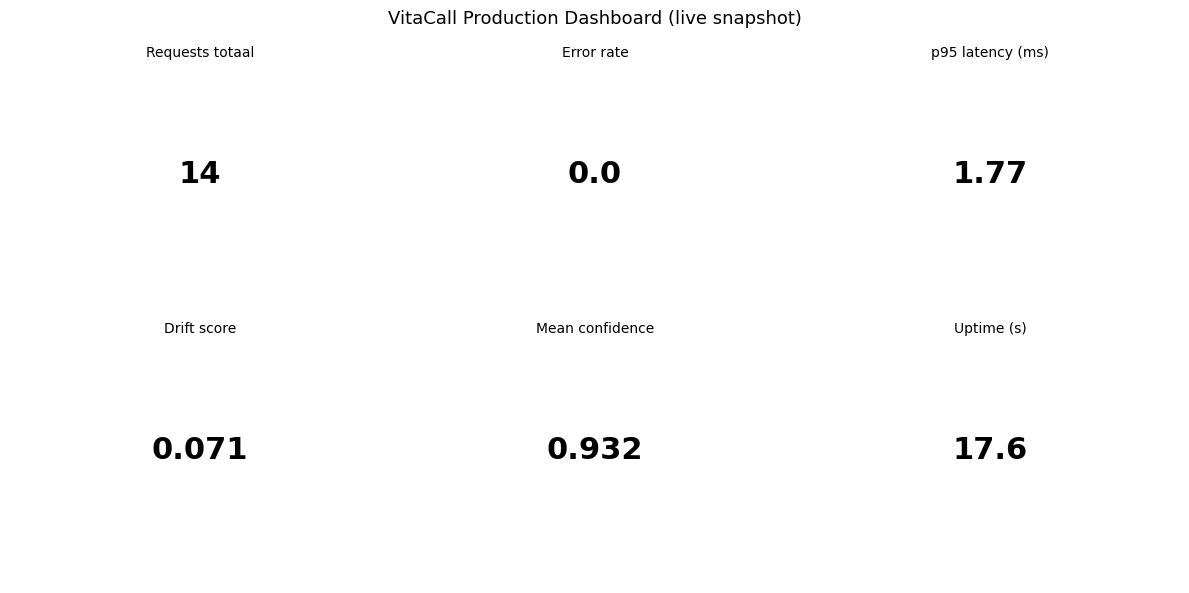

evidence/grafana_dashboard.png geschreven (6 panels, live waarden).
Live-alert-check toegevoegd aan evidence/alerts.jsonl.


In [46]:
# LD5: alert-engine OOK op de ECHTE live tellers draaien (niet alleen gesimuleerd),
# zodat we aantonen dat het systeem in normale toestand 0 alerts geeft.
live_metrics = api_metrics.snapshot()             # echte system-metrics
live_drift = api_drift.snapshot()                 # echte drift-snapshot
# Maak verse regels aan zodat de live-check niet meelift op gesimuleerde state.
live_rules = {k: AlertRule(v.name, v.condition, v.severity) for k, v in rules.items()}
live_fired = evaluate_rules(live_metrics, live_drift, live_rules)
# Toon dat een gezond systeem 0 alerts geeft op echte data.
print(f'Alert-engine op LIVE snapshot: {len(live_fired)} alert(s) '
      f'(verwacht 0 in gezonde toestand).')
print(f'  live error_rate={live_metrics.get("error_rate")} '
      f'p95={live_metrics.get("p95_ms")}ms drift={live_drift.get("drift_score")}')

# Render een ZICHTBAAR dashboard (matplotlib) dat de Grafana-panels nabootst.
if HAS_PLT:
    fig, ax = plt.subplots(2, 3, figsize=(12, 6))
    fig.suptitle('VitaCall Production Dashboard (live snapshot)', fontsize=13)
    # Elke tegel toont 1 echte live-metric.
    panels = [
        ('Requests totaal', live_metrics.get('requests_total', 0)),
        ('Error rate', live_metrics.get('error_rate', 0)),
        ('p95 latency (ms)', live_metrics.get('p95_ms', 0)),
        ('Drift score', live_drift.get('drift_score', 0)),
        ('Mean confidence', live_metrics.get('avg_confidence', 0)),
        ('Uptime (s)', live_metrics.get('uptime_s', 0)),
    ]
    # Plaats per metric een grote waarde-tegel zonder assen.
    for a, (title, val) in zip(ax.flat, panels):     # 1 stat-panel per metric
        a.text(0.5, 0.55, f'{val}', ha='center', va='center', fontsize=22, weight='bold')
        a.set_title(title, fontsize=10)
        a.axis('off')
    # Sla het dashboard op en toon het direct in de notebook.
    fig.tight_layout()
    fig.savefig('evidence/grafana_dashboard.png', dpi=120)
    plt.show()
    print('evidence/grafana_dashboard.png geschreven (6 panels, live waarden).')

# Voeg de live-alert-uitkomst toe aan de alerts-feed als audit-spoor.
live_row = {'scope': 'live_snapshot', 'alerts': len(live_fired),
            'error_rate': live_metrics.get('error_rate'),
            'drift_score': live_drift.get('drift_score')}
# Append zodat de eerdere (gesimuleerde) alerts bewaard blijven.
with open('evidence/alerts.jsonl', 'a', encoding='utf-8') as f:
    f.write(json.dumps(live_row) + '\n')
print('Live-alert-check toegevoegd aan evidence/alerts.jsonl.')

#### Monitoring over tijd

Een losse snapshot kan een tijdelijke afwijking missen. De volgende cel stuurt daarom in stappen requests en bewaart latency, foutpercentage en drift als korte tijdreeks.

2026-06-22 15:22:37,802 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


2026-06-22 15:22:37,809 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


2026-06-22 15:22:37,817 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


2026-06-22 15:22:37,823 [INFO] HTTP Request: GET http://testserver/metrics "HTTP/1.1 200 OK"


2026-06-22 15:22:37,830 [INFO] HTTP Request: GET http://testserver/drift "HTTP/1.1 200 OK"


...

2026-06-22 15:22:38,337 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


2026-06-22 15:22:38,344 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


2026-06-22 15:22:38,352 [INFO] HTTP Request: POST http://testserver/analyze "HTTP/1.1 200 OK"


2026-06-22 15:22:38,359 [INFO] HTTP Request: GET http://testserver/metrics "HTTP/1.1 200 OK"


2026-06-22 15:22:38,364 [INFO] HTTP Request: GET http://testserver/drift "HTTP/1.1 200 OK"


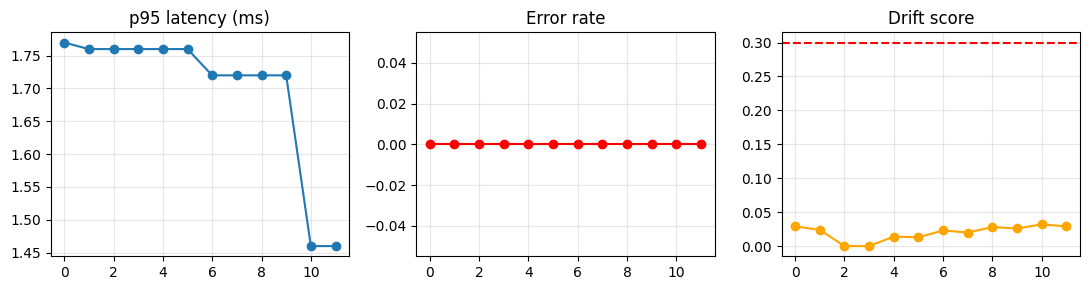

evidence/monitoring_timeseries.{png,json} geschreven ( 12 tijdpunten ).


In [47]:
# LD5 evidence: meet een tijdreeks van metrics onder oplopende load en plot die.
# We hergebruiken de bestaande 'client' (geen nieuwe TestClient).
if HAS_PLT:
    series = {'t': [], 'p95': [], 'err_rate': [], 'drift': []}   # meetreeks per stap
    pool = scenarios + ['flauwgevallen, niet aanspreekbaar', 'het gaat prima']
    # Per stap stijgt de load zodat we een trend zien ontstaan.
    for step in range(12):                     # 12 tijdstappen met oplopende load
        for txt in pool[: 3 + step % 4]:       # stuur per stap een paar requests
            client.post('/analyze', json={'text': txt})
        ms = client.get('/metrics').json()     # lees metrics-snapshot
        ds = client.get('/drift').json()       # lees drift-snapshot
        # Bewaar de meetwaarden van deze tijdstap.
        series['t'].append(step)
        series['p95'].append(ms['p95_ms'])
        series['err_rate'].append(ms['error_rate'])
        series['drift'].append(ds.get('drift_score', 0))
    # Drie plots naast elkaar: latency, error-rate, drift.
    fig, axes = plt.subplots(1, 3, figsize=(11, 3))
    axes[0].plot(series['t'], series['p95'], marker='o'); axes[0].set_title('p95 latency (ms)'); axes[0].grid(alpha=0.3)
    axes[1].plot(series['t'], series['err_rate'], marker='o', color='red'); axes[1].set_title('Error rate'); axes[1].grid(alpha=0.3)
    axes[2].plot(series['t'], series['drift'], marker='o', color='orange'); axes[2].axhline(0.3, ls='--', color='red'); axes[2].set_title('Drift score'); axes[2].grid(alpha=0.3)
    # Sla de plots op en toon ze direct in de notebook als bewijs.
    fig.tight_layout(); fig.savefig('evidence/monitoring_timeseries.png', dpi=120); plt.show()
    with open('evidence/monitoring_timeseries.json', 'w', encoding='utf-8') as f:
        json.dump(series, f, indent=2)
    print('evidence/monitoring_timeseries.{png,json} geschreven (', len(series['t']), 'tijdpunten ).')
else:
    print('Tijdreeks overgeslagen (matplotlib niet beschikbaar).')

### 4.5 Mini-testpakket

We sluiten af met een setje unit-tests, inline in het notebook. Er is geen aparte `tests/`-map meer; het notebook is het hele deliverable. Die keuze is bewust: alles wat de docent moet kunnen draaien staat op één plek, en de tests draaien tegen exact dezelfde objecten als de rest van het notebook, niet tegen een losse kopie die uit de pas kan lopen.

We testen niet om het testen, maar precies de dingen die echt niet stuk mogen gaan en die je tijdens een hertraining of een refactor zomaar kapotmaakt zonder het te merken.

- **Keyword-detectie** pikt urgentie- en medicatie-termen op ('pijn op de borst' → urgentie, 'paracetamol' → medicatie) en laat neutrale tekst met rust. Voor VitaCall zijn die keywords de directe spoed-signalen die naast het sentiment aan de operator getoond worden. Breekt die detectie stilletjes, dan mist de operator de hint.
- **Het cloud-model herkent een overduidelijke spoedzin** ('ernstige pijn op de borst, bewusteloos') als negatief. Dit is de regressie waar we het meest bang voor zijn: een hertraining op net iets andere data kan de accuracy op DBRD gelijk houden en tegelijk het gevoel voor acuut Nederlands verliezen. Deze test is onze vangrail tegen dat scenario.
- **De drift-detector geeft zijn drie statussen correct terug**: `onvoldoende_data` bij te weinig samples, `normaal` bij 50/50, en `drift` bij een scheve verdeling. Dat is dezelfde logica waar de hele monitoring-laag op leunt, dus die wil je vastgepind hebben.

Klein pakket, maar het dekt de paden waar een fout een echt gevolg heeft voor een beller. We gebruiken bewust geen pytest: een paar `assert_eq`-aanroepen met een leesbare foutmelding zijn genoeg en houden het notebook zelfstandig draaibaar zonder extra test-runner. Faalt er één, dan stopt de cel hard met de naam van de test erbij, zodat je meteen weet welke aanname is gesneuveld.

In [48]:
# Mini-testpakket. Lokaal, geen pytest nodig om te draaien.
# Eigen mini-assert zodat we zonder extra libs kunnen testen.
def assert_eq(actual, expected, name):
    if actual != expected:
        raise AssertionError(f'{name}: verwacht {expected!r}, kreeg {actual!r}')
    print(f'  OK   {name}')


print('Tests:')
# Een try-blok zodat een gefaalde test netjes wordt gemeld.
try:
    # Keywords
    # Controleer dat spoed-woorden als urgentie worden herkend.
    assert_eq(any(k['type'] == 'urgentie' for k in find_keywords('pijn op de borst')),
              True, 'find_keywords detecteert urgentie')
    assert_eq(any(k['type'] == 'medicatie' for k in find_keywords('ik gebruik paracetamol')),
              True, 'find_keywords detecteert medicatie')
    # Neutrale tekst mag geen keywords opleveren.
    assert_eq(find_keywords('alles goed'), [], 'find_keywords negeert neutrale tekst')

    # Predict op heavy model
    # Check dat het zware model een duidelijke spoed-zin als negatief scoort.
    s, _ = predict_sentiment(heavy, 'ernstige pijn op de borst, bewusteloos')
    assert_eq(s, 'negatief', 'heavy model herkent spoed-zin')

    # Drift-detector
    # Met te weinig data mag de detector nog geen oordeel geven.
    d = DriftDetector()
    d.add('positief')
    assert_eq(d.snapshot()['status'], 'onvoldoende_data', 'drift bij weinig data')

    # Bij een 50/50-verdeling is er geen drift.
    d2 = DriftDetector()
    for _ in range(20):
        d2.add('positief')
        d2.add('negatief')
    assert_eq(d2.snapshot()['status'], 'normaal', 'drift bij 50/50')

    # Bij een scheve verdeling moet drift wel afgaan.
    d3 = DriftDetector(threshold=0.1)
    for _ in range(20):
        d3.add('positief')
    assert_eq(d3.snapshot()['status'], 'drift', 'drift bij scheve verdeling')

    # Live monitoring-output en evidencebestanden
    # Bewijs dat de monitoring echt requests heeft geteld.
    _m = api_metrics.snapshot()
    assert_eq(_m['requests_total'] > 0, True, 'monitoring telt requests')
    assert_eq('error_rate' in _m and 'p95_ms' in _m, True, 'metrics-snapshot compleet')
    # Controleer dat de evidence-bestanden daadwerkelijk op schijf staan.
    assert_eq(os.path.exists('evidence/grafana_dashboard.png'), True, 'dashboard aanwezig')
    assert_eq(os.path.exists('evidence/alerts.jsonl'), True, 'alerts-feed aanwezig')

    print('\nAlle tests geslaagd.')
except AssertionError as e:
    print(f'\n[FOUT] Test gefaald: {e}')
    raise

2026-06-22 15:22:38,894 [WARNING] DRIFT alert: positive_rate=1.000 score=0.500 n=20


Tests:
  OK   find_keywords detecteert urgentie
  OK   find_keywords detecteert medicatie
  OK   find_keywords negeert neutrale tekst
  OK   heavy model herkent spoed-zin
  OK   drift bij weinig data
  OK   drift bij 50/50
  OK   drift bij scheve verdeling
  OK   monitoring telt requests
  OK   metrics-snapshot compleet
  OK   dashboard aanwezig
  OK   alerts-feed aanwezig

Alle tests geslaagd.


---

## Conclusie

Dit notebook levert een end-to-end MLOps-platform voor VitaCall: van ruwe data tot een live gedeployde, gemonitorde service, met twee bewust gescheiden modellen (edge-ASR en cloud-sentiment). Hieronder per leerdoel wat er geleverd is en waar het bewijs in het notebook staat.

| LD | Rubric-criterium | Geleverd | Bewijs |
|----|-----------|--------------|------------------------|
| 1  | Modulaire pijplijn met validatie + versiebeheer | Drie-laags pipeline (ruw/schoon/trainklaar); dataclass-validatie + fail-fast per laag; SHA256-manifest; git. Functie-definities en uitvoering staan in aparte cellen, elk met een eigen uitleg | Sectie 1.1-1.6 |
| 2  | Schaalbaarheid (batching, distributed, cloud) | Streaming Parquet-batches; stresstest op **>250k rijen** (1.10); PySpark distributed-split (verplicht, winutils-backed); throughput-benchmark (piek bij batch 5k, geheugenbegrensd); fsspec cloud-storage; k8s HPA | Sectie 1.4-1.10 + `evidence/scaling_bigdata.json` |
| 3  | Passend model, getuned, reproduceerbaar | **Twee modelrollen.** Edge: Vosk-NL ASR-harness met expliciete status als model/audio ontbreekt. Cloud: TF-IDF+LR, test- en CV-metrics, grid-sweep + Optuna; **10 MLflow-runs getrackt** (zichtbaar in sectie 2.8); FedAvg met kwantitatief verklaarde accuracy-drop | Sectie 2.1-2.9 + `evidence/asr_eval.json`, `cv_scores.json` |
| 4  | Deployment (Docker, CI/CD, API), geautomatiseerd | FastAPI in `serve.py`; Dockerfile + compose; `render.yaml` Blueprint. De cloud-service draait **echt live op https://mleops.onrender.com** en wordt in sectie 3.6 over het netwerk getest (`GET /health` 200, `POST /analyze` met geldig contract). Zelfde image als edge-container; GitHub Actions CI+CD+CT | Sectie 3.1-3.7 + `evidence/cloud_deploy.json` |
| 5  | Monitoring system + model, drift, alerts | Metrics + DriftDetector (live tellers); PSI + KS op feature-niveau; Prometheus `/metrics-prom`; alert-engine op **live + gesimuleerde** snapshot; gerenderd dashboard | Sectie 4.1-4.5 + `evidence/grafana_dashboard.png`, `alerts.jsonl` |

## Reflectie: wat sterk is en waar de grenzen liggen

De kracht van deze inlevering zit in **bewijs dat echt draait en in het notebook zelf zichtbaar is**, niet alleen in losse bestanden. De cloud-deploy is geen claim maar een geverifieerde live respons; de schaalbaarheid is gemeten op een kwart miljoen rijen; de MLflow-tracking toont tien echte runs met hun metrics; de monitoring slaat alarm op scenario's waarvan we de uitkomst vooraf kennen.

Tegelijk zijn er bewuste grenzen die we niet wegpoetsen. De edge-ASR levert geen eigen word error rate omdat er geen Nederlands referentiecorpus met opgenomen audio beschikbaar is; we tonen alleen de geslaagde self-check van de rekenkern. De edge-container draait niet in elke omgeving omdat dat een lokale Docker-daemon vereist, en valt dan netjes terug. En het sentimentmodel is getraind op boekenrecensies in plaats van echte alarmtranscripten, omdat die laatste onder bijzondere persoonsgegevens vallen (AVG art. 9). Dat zijn geen verzwegen tekortkomingen maar expliciete keuzes die uit de zorgcontext volgen.

Voor een productie-uitrol bij VitaCall zou de volgende stap zijn: het sentimentmodel hertrainen op geanonimiseerde echte transcripten zodra die met de juiste grondslag beschikbaar zijn, een Nederlands spraakcorpus opnemen om de ASR-WER hard te maken, en de edge-deploy op echte gateway-hardware draaien. De pijplijn, het versiebeheer en de monitoring eromheen zijn daar al op ingericht.

## Bewuste scope-keuzes

**FedAvg**: 3 clients, lokale training, gewichts-aggregatie op centrale server. Het algoritme is volledig; het netwerk-transport is bewust niet uitgewerkt (infra, geen ML). De accuracy zakt van ~0,87 naar ~0,62 door een derde data per client, niet-identiek verdeelde splits en weinig rondes, zoals uitgelegd in sectie 2.9.

**Domein-zinnen synthetisch + oversampled**: bewuste keuze omdat echte VitaCall-transcripten onder privacy vallen (AVG art. 9, gezondheidsdata). De pipeline leest ze in zodra beschikbaar; de TF-IDF-stap is class-agnostic.

**Edge-WER**: de workspace bevat geen Vosk-modelmap en geen Nederlands spraakcorpus met referentietranscripten. Daarom rapporteert de run `model_reference_missing` en alleen de geslaagde self-check van de WER-rekenkern. Een eigen WER vereist het model plus opgenomen referentiezinnen voor `evaluate_asr()`.

## Bronvermelding (APA)

van der Burgh, B., & Verberne, S. (2019). *The merits of Universal Language Model Fine-tuning for Small Datasets, a case with Dutch book reviews.* arXiv:1910.00896.

Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR, 12.*

McMahan, H. B., Moore, E., Ramage, D., Hampson, S., & Arcas, B. A. y. (2017). Communication-Efficient Learning of Deep Networks from Decentralized Data. *AISTATS.*

Zaharia, M. et al. (2018). Accelerating the Machine Learning Lifecycle with MLflow. *IEEE Data Eng. Bull.*

Alpha Cephei. (z.d.). *Vosk small Dutch model (vosk-model-small-nl).* https://alphacephei.com/vosk/models

PySpark documentatie. https://spark.apache.org/docs/latest/api/python/

FastAPI documentatie. https://fastapi.tiangolo.com/
